# Chapter 2 — Reactor Design

Detailed design model for the R-601 methanol synthesis reactor and associated synthesis-loop equipment. The chapter establishes the kinetic, transport, hydraulic, recycle and heat-removal model used as the technical basis for Chapter 3.

## 2.1 Imports, species and stoichiometry

Loads the numerical libraries and defines the seven-component system, molecular weights and independent reaction stoichiometry.

In [58]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import brentq
from scipy.interpolate import PchipInterpolator
from dataclasses import dataclass

R = 8.314462618  # J/mol/K

SPECIES = ("H2", "CO", "CO2", "H2O", "MeOH", "CH4", "N2")
IDX = {s: i for i, s in enumerate(SPECIES)}

MW_KG_MOL = np.array([ 0.00201588, 0.0280101, 0.0440095, 0.01801528, 0.03204186, 0.01604246, 0.0280134 ])
MW_G_MOL = 1000.0 * MW_KG_MOL

# Reaction 1: CO2 + 3H2 <-> MeOH + H2O
NU_MEOH = np.array([-3.0, 0.0, -1.0, +1.0, +1.0, 0.0, 0.0])

# Reaction 2: CO2 + H2 <-> CO + H2O  (positive = RWGS)
NU_RWGS = np.array([-1.0, +1.0, -1.0, +1.0, 0.0, 0.0, 0.0])

print("Species:", SPECIES)
print("Two independent reactions drive all seven component balances.")

Species: ('H2', 'CO', 'CO2', 'H2O', 'MeOH', 'CH4', 'N2')
Two independent reactions drive all seven component balances.


## 2.2 Reactor design basis

Defines the reference feed, operating conditions and reactor/cooling basis used for the detailed R-601 design.

In [59]:
FEED_KMOL_H = {
    "H2": 2018.19643795731,
    "CO": 804.480345592503,
    "CO2": 61.0099058743523,
    "H2O": 1.61344304486572,
    "MeOH": 10.7984451635575,
    "CH4": 177.506657421455,
    "N2": 30.7984710167818,
}

CATALYST_TEMPERATURE_LIMIT_C = 280.0

DESIGN = {
    "T_in_C": 225.0,
    "P_in_bar": 70.0,
    "n_tubes": 1620,
    "tube_id_m": 0.040,
    "bed_length_m": 7.0,
    "steam_drum_pressure_bar_abs": 29.0,
    "industrial_reference_U_W_m2K": 118.44,
}

SOLVER = {
    "method": "BDF",
    "rtol": 3.0e-6,
    "atol": 1.0e-8,
    "max_step_m": 0.18,
    "profile_points": 101,
}

F0_MOL_S = np.array([FEED_KMOL_H[s] for s in SPECIES], dtype=float) / 3.6

basis_table = pd.DataFrame({
    "Parameter": [
        "R-601 inlet temperature", "R-601 inlet pressure",
        "Tube number", "Tube ID", "Catalyst-bed length",
        "S-604 steam-drum pressure", "Maximum catalyst temperature", "Industrial Lurgi U benchmark"
    ],
    "Value": [
        DESIGN["T_in_C"], DESIGN["P_in_bar"], DESIGN["n_tubes"],
        DESIGN["tube_id_m"], DESIGN["bed_length_m"],
        DESIGN["steam_drum_pressure_bar_abs"],
        CATALYST_TEMPERATURE_LIMIT_C,
        DESIGN["industrial_reference_U_W_m2K"]
    ],
    "Unit": ["°C", "bar(a)", "-", "m", "m", "bar(a)", "°C", "W/m²/K"]
})
display(basis_table)


# Preserve Task-1 mixed-feed basis.
BASE_TASK1_COMBINED_FEED_MOL_S = F0_MOL_S.copy()


,Parameter,Value,Unit
0,R-601 inlet temperature,225.00,°C
1,R-601 inlet pressure,70.00,bar(a)
2,Tube number,1620.00,-
3,Tube ID,0.04,m
4,Catalyst-bed length,7.00,m
5,S-604 steam-drum pressure,29.00,bar(a)
6,Maximum catalyst temperature,280.00,°C
7,Industrial Lurgi U benchmark,118.44,W/m²/K


## 2.3 Catalyst and reactor geometry

Defines the MegaMax 800 catalyst basis and calculates tube geometry, packed-bed volume, voidage and catalyst inventory.

In [60]:
CATALYST = {
    "name": "Clariant MegaMax 800",
    "pellet_diameter_m": 0.006,
    "pellet_height_m": 0.004,
    "bed_loading_density_kg_m3": 1200.0,
    "pellet_apparent_density_kg_m3": 1950.0,
    "epsilon_over_tau": 0.123,
    "pore_radius_m": 1.0e-8,
}

def pellet_volume_m3():
    return (math.pi * CATALYST["pellet_diameter_m"]**2 * CATALYST["pellet_height_m"] / 4.0)

def pellet_external_area_m2():
    d = CATALYST["pellet_diameter_m"]
    h = CATALYST["pellet_height_m"]
    return math.pi*d*h + math.pi*d**2/2.0

def particle_diameter_sv_m():
    return 6.0 * pellet_volume_m3() / pellet_external_area_m2()

def equivalent_sphere_radius_m():
    return 3.0 * pellet_volume_m3() / pellet_external_area_m2()

def particle_diameter_v_m():
    # Volume-equivalent sphere diameter for radial heat transfer.
    return (6.0 * pellet_volume_m3() / math.pi)**(1.0/3.0)

BED_VOIDAGE = (1.0 - CATALYST["bed_loading_density_kg_m3"] / CATALYST["pellet_apparent_density_kg_m3"])

def reactor_geometry():
    A_one = math.pi * DESIGN["tube_id_m"]**2 / 4.0
    A_flow = DESIGN["n_tubes"] * A_one
    rho_bulk = CATALYST["bed_loading_density_kg_m3"]
    dW_dz = A_flow * rho_bulk
    wall_perimeter = (DESIGN["n_tubes"] * math.pi * DESIGN["tube_id_m"])
    catalyst_mass = dW_dz * DESIGN["bed_length_m"]
    return {
        "A_flow_m2": A_flow,
        "rho_bulk_kg_m3": rho_bulk,
        "dW_dz_kg_m": dW_dz,
        "wall_perimeter_m": wall_perimeter,
        "catalyst_mass_kg": catalyst_mass,
    }

GEOM = reactor_geometry()

geometry_table = pd.DataFrame({
    "Parameter": [
        "Bed voidage", "Surface/volume particle diameter",
        "Equivalent-sphere radius", "Total gas-flow area",
        "Catalyst inventory"
    ],
    "Value": [
        BED_VOIDAGE, 1000*particle_diameter_sv_m(),
        1000*equivalent_sphere_radius_m(), GEOM["A_flow_m2"],
        GEOM["catalyst_mass_kg"]/1000
    ],
    "Unit": ["-", "mm", "mm", "m²", "t"]
})
display(geometry_table)

,Parameter,Value,Unit
0,Bed voidage,0.384615,-
1,Surface/volume particle diameter,5.142857,mm
2,Equivalent-sphere radius,2.571429,mm
3,Total gas-flow area,2.035752,m²
4,Catalyst inventory,17.100317,t


## 2.4 Seven-component reaction model

Implements the Vanden Bussche–Froment kinetic model for methanol synthesis and the associated RWGS/WGS reaction.

In [61]:
def vbf_parameters(T_K):
    ka = 0.499 * np.exp(17197.0 / (R*T_K))
    kb = 6.62e-11 * np.exp(124119.0 / (R*T_K))
    kc = 3453.38
    kd = 1.07 * np.exp(36696.0 / (R*T_K))
    ke = 1.22e10 * np.exp(-94765.0 / (R*T_K))
    K1 = 10.0**(3066.0/T_K - 10.592)
    K3 = 10.0**(2073.0/T_K - 2.029)
    return ka, kb, kc, kd, ke, K1, K3

def vbf_rates_from_partial_pressures(p_bar, T_K):
    p = np.maximum(np.asarray(p_bar, dtype=float), 1.0e-14)

    H2   = p[IDX["H2"]]
    CO   = p[IDX["CO"]]
    CO2  = p[IDX["CO2"]]
    H2O  = p[IDX["H2O"]]
    MeOH = p[IDX["MeOH"]]

    ka, kb, kc, kd, ke, K1, K3 = vbf_parameters(T_K)

    denominator = (1.0 + kc*H2O/H2 + ka*np.sqrt(H2) + kb*H2O)

    drive_M = 1.0 - H2O*MeOH/(K1*H2**3*CO2)
    drive_R = 1.0 - K3*H2O*CO/(CO2*H2)

    rM = kd*CO2*H2*drive_M / denominator**3
    rR = ke*CO2*drive_R / denominator

    return rM, rR

def reaction_heat_release_J_mol(T_K):
    # Positive values mean heat release.
    qM = 35.895*T_K + 40047.0
    qR = 9.177*T_K - 44325.0
    return qM, qR

## 2.5 Physical-property model

Calculates heat capacity, real-gas density, viscosity and thermal conductivity for the reactor calculations.

In [62]:
COMP = {
    "H2":   {"Tc":33.145,   "Pc_bar":12.964, "Vc_cm3_mol":64.2,  "Zc":0.303, "omega":-0.219,  "dipole_D":0.0,   "Q":0.76},
    "CO":   {"Tc":132.86,   "Pc_bar":34.94,  "Vc_cm3_mol":93.1,  "Zc":0.295, "omega":0.049,   "dipole_D":0.112, "Q":0.0},
    "CO2":  {"Tc":304.1282, "Pc_bar":73.773, "Vc_cm3_mol":94.07, "Zc":0.274, "omega":0.22394, "dipole_D":0.0,   "Q":0.0},
    "H2O":  {"Tc":647.096,  "Pc_bar":220.64, "Vc_cm3_mol":55.95, "Zc":0.229, "omega":0.3443,  "dipole_D":1.85,  "Q":0.0},
    "MeOH": {"Tc":512.6,    "Pc_bar":80.96,  "Vc_cm3_mol":118.0, "Zc":0.224, "omega":0.565,   "dipole_D":1.7,   "Q":0.0},
    "CH4":  {"Tc":190.564,  "Pc_bar":45.992, "Vc_cm3_mol":98.6,  "Zc":0.286, "omega":0.01142, "dipole_D":0.0,   "Q":0.0},
    "N2":   {"Tc":126.192,  "Pc_bar":33.958, "Vc_cm3_mol":89.4,  "Zc":0.289, "omega":0.0372,  "dipole_D":0.0,   "Q":0.0},
}

SHOMATE = {
    "H2":  (33.066178,-11.363417, 11.432816,-2.772874,-0.158558),
    "CO":  (25.56759,  6.09613,   4.054656,-2.671301, 0.131021),
    "CO2": (24.99735, 55.18696, -33.69137, 7.948387,-0.136638),
    "H2O": (30.092,    6.832514,  6.793435,-2.53448,  0.082139),
    "CH4": (-0.703029,108.4773, -42.52157, 5.862788, 0.678565),
}
N2_SHOMATE_LOW  = (28.98641,1.853978,-9.647459,16.63537,0.000117)
N2_SHOMATE_HIGH = (19.50583,19.88705,-8.598535,1.369784,0.527601)

MEOH_T_K = np.array([300,400,500,600,700,800,900,1000], dtype=float)
MEOH_CP_J_MOLK = np.array([44.17,51.63,59.70,67.19,73.86,79.76,84.95,89.54])

def shomate_cp_J_molK(T_K, coeffs):
    t = T_K/1000.0
    A,B,C,D,E = coeffs
    return A + B*t + C*t**2 + D*t**3 + E/t**2

def cp_species_J_molK(T_K):
    values = []
    for s in SPECIES:
        if s == "MeOH":
            value = np.interp(np.clip(T_K, MEOH_T_K[0], MEOH_T_K[-1]), MEOH_T_K, MEOH_CP_J_MOLK)
        elif s == "N2":
            coeffs = N2_SHOMATE_LOW if T_K <= 500.0 else N2_SHOMATE_HIGH
            value = shomate_cp_J_molK(T_K, coeffs)
        elif s == "H2O":
            value = shomate_cp_J_molK(max(T_K,500.0), SHOMATE["H2O"])
        else:
            value = shomate_cp_J_molK(T_K, SHOMATE[s])
        values.append(value)
    return np.array(values, dtype=float)

TC = np.array([COMP[s]["Tc"] for s in SPECIES])
PC_PA = np.array([COMP[s]["Pc_bar"]*1.0e5 for s in SPECIES])
OMEGA = np.array([COMP[s]["omega"] for s in SPECIES])

def peng_robinson_Z(T_K, P_Pa, y):
    y = np.asarray(y, dtype=float)
    y = y/y.sum()

    kappa = 0.37464 + 1.54226*OMEGA - 0.26992*OMEGA**2
    alpha = (1.0 + kappa*(1.0 - np.sqrt(T_K/TC)))**2

    ai = 0.45724*R**2*TC**2*alpha/PC_PA
    bi = 0.07780*R*TC/PC_PA

    aij = np.sqrt(ai[:,None]*ai[None,:])
    a_mix = float(y @ aij @ y)
    b_mix = float(y @ bi)

    A = a_mix*P_Pa/(R**2*T_K**2)
    B = b_mix*P_Pa/(R*T_K)

    roots = np.roots([ 1.0, -(1.0-B), A - 3.0*B**2 - 2.0*B, -(A*B - B**2 - B**3) ])
    real_roots = [r.real for r in roots if abs(r.imag) < 1.0e-9]
    if not real_roots:
        raise RuntimeError("Peng-Robinson returned no real gas root.")
    return float(max(real_roots))

def lucas_polarity_factor(T_K, species):
    d = COMP[species]
    Tr = T_K/d["Tc"]
    mu_r = 52.46*d["dipole_D"]**2*d["Pc_bar"]/d["Tc"]**2
    base = max(0.0, 0.292-d["Zc"])
    if mu_r < 0.022:
        return 1.0
    if mu_r < 0.075:
        return 1.0 + 30.55*base**1.72
    return 1.0 + 30.55*base**1.72*abs(0.96 + 0.1*(Tr-0.7))

def lucas_quantum_factor(T_K, species):
    d = COMP[species]
    if d["Q"] <= 0.0:
        return 1.0
    Tr = T_K/d["Tc"]
    MW = MW_G_MOL[IDX[species]]
    return (1.22*d["Q"]**0.15 * (1.0 + 0.00385*((Tr-12.0)**2)**(1.0/MW)*np.sign(Tr-12.0)))

def lucas_mixture_viscosity_Pa_s(T_K, P_Pa, y):
    y = np.asarray(y, dtype=float)
    y = y/y.sum()

    Tc_mix = sum(y[i]*COMP[s]["Tc"] for i,s in enumerate(SPECIES))
    Vc_mix = sum(y[i]*COMP[s]["Vc_cm3_mol"] for i,s in enumerate(SPECIES))
    Zc_mix = sum(y[i]*COMP[s]["Zc"] for i,s in enumerate(SPECIES))
    Pc_mix_bar = 83.144626*Tc_mix*Zc_mix/Vc_mix
    MW_mix = float(y @ MW_G_MOL)

    FP0 = sum(y[i]*lucas_polarity_factor(T_K,s) for i,s in enumerate(SPECIES))
    FQ0 = sum(y[i]*lucas_quantum_factor(T_K,s) for i,s in enumerate(SPECIES))

    Tr = T_K/Tc_mix
    Pr = P_Pa/1.0e5/Pc_mix_bar
    xi = 0.176*(Tc_mix/(MW_mix**3*Pc_mix_bar**4))**(1.0/6.0)

    Z1 = (0.807*Tr**0.618 - 0.357*np.exp(-0.449*Tr) + 0.34*np.exp(-4.058*Tr) + 0.018)*FP0*FQ0

    a = 0.001245*np.exp(5.1726*Tr**(-0.3286))/Tr
    b = a*(1.6553*Tr - 1.2723)
    c = 0.4489*np.exp(3.0578*Tr**(-37.7332))/Tr
    d = 1.7368*np.exp(2.231*Tr**(-7.6351))/Tr
    e = 1.3088
    f = 0.9425*np.exp(-0.1853*Tr**0.4489)

    Z2 = Z1*(1.0 + a*Pr**e/(b*Pr**f + (1.0+c*Pr**d)**(-1)))
    Y = Z2/Z1

    FP = (1.0 + (FP0-1.0)*Y**(-3.0))/FP0
    FQ = (1.0 + (FQ0-1.0)*(1.0/Y - 0.007*np.log(Y)**4))/FQ0

    return float(Z2*FP*FQ/xi*1.0e-7)

def gas_properties(T_K, P_Pa, F_mol_s):
    F = np.maximum(np.asarray(F_mol_s, dtype=float), 1.0e-30)
    y = F/F.sum()

    Z = peng_robinson_Z(T_K, P_Pa, y)
    MW_mix = float(y @ MW_KG_MOL)
    rho = P_Pa*MW_mix/(Z*R*T_K)
    cp_i = cp_species_J_molK(T_K)
    cp_molar = float(y @ cp_i)
    cp_mass = cp_molar/MW_mix
    mu = lucas_mixture_viscosity_Pa_s(T_K, P_Pa, y)

    # Modified-Eucken mixture thermal conductivity.
    # Used only for the packed-bed U calculation.
    k = mu*(cp_mass + 1.25*R/MW_mix)
    Pr = mu*cp_mass/k

    Vdot = F.sum()*Z*R*T_K/P_Pa

    return {
        "y": y, "Z": Z, "MW_mix_kg_mol": MW_mix,
        "rho_kg_m3": rho,
        "cp_species_J_molK": cp_i,
        "cp_molar_J_molK": cp_molar,
        "cp_mass_J_kgK": cp_mass,
        "mu_Pa_s": mu,
        "k_W_mK": k,
        "Pr": Pr,
        "Vdot_m3_s": Vdot,
    }


## 2.6 Boiling-water coolant temperature

Calculates the S-604 saturation temperature from the selected steam-drum pressure.

In [63]:
def water_saturation_temperature_C(P_bar_abs):
    # IAPWS-IF97 Region 4 saturation equation.
    p_MPa = float(P_bar_abs)*0.1

    n1 = 1167.0521452767
    n2 = -724213.16703206
    n3 = -17.073846940092
    n4 = 12020.82470247
    n5 = -3232555.0322333
    n6 = 14.91510861353
    n7 = -4823.2657361591
    n8 = 405113.40542057
    n9 = -0.23855557567849
    n10 = 650.17534844798

    beta = p_MPa**0.25
    E = beta**2 + n3*beta + n6
    F = n1*beta**2 + n4*beta + n7
    G = n2*beta**2 + n5*beta + n8

    D = 2.0*G/(-F - np.sqrt(F**2 - 4.0*E*G))
    T_K = (n10 + D - np.sqrt((n10+D)**2 - 4.0*(n9+n10*D)))/2.0
    return float(T_K - 273.15)

T_COOL_C = water_saturation_temperature_C(DESIGN["steam_drum_pressure_bar_abs"])
T_COOL_K = T_COOL_C + 273.15

print(f"S-604 pressure        = {DESIGN['steam_drum_pressure_bar_abs']:.2f} bar(a)")
print(f"Boiling-water T_sat   = {T_COOL_C:.2f} °C")

S-604 pressure        = 29.00 bar(a)
Boiling-water T_sat   = 231.99 °C


## 2.7 Reactor overall heat-transfer coefficient

Calculates the representative reactor overall heat-transfer coefficient from packed-bed, tube-wall, boiling-side and residual thermal resistances.

In [64]:
# Calibrated reactor heat-transfer model.
HEAT_TRANSFER = {
    "tube_wall_thickness_m": 0.00198,
    "tube_wall_conductivity_W_mK": 19.0,
    "water_critical_pressure_kPa": 22064.0,
    "nonboiling_shell_h_W_m2K": 2500.0,
    "cylinder_shape_factor": 2.5,
    "solid_conductivity_factor": 1.0,
}

INDUSTRIAL_REFERENCE = {
    "U_W_m2K": DESIGN["industrial_reference_U_W_m2K"],
    "T_C": 225.0,
    "P_bar": 69.7,
    "n_tubes": 1620,
    "tube_id_m": 0.040,
    "bed_voidage": 0.285,
    "particle_diameter_v_m": 0.0054,
    "steam_drum_pressure_bar_abs": 29.0,
    "mass_kg_h": {
        "H2": 9586.5,
        "CO": 10727.9,
        "CO2": 23684.2,
        "H2O": 108.8,
        "MeOH": 756.7,
        "CH4": 4333.1,
        "N2": 8072.0,
    },
    # Aspen reference calibration duty.
    "calibration_duty_cal_s": -1597165.13,
}

def mostinski_boiling_h_W_m2K(heat_flux_W_m2, pressure_bar_abs):
    Pc_kPa = HEAT_TRANSFER["water_critical_pressure_kPa"]
    P_kPa = pressure_bar_abs*100.0
    Pr_red = P_kPa/Pc_kPa
    Fp = 1.8*Pr_red**0.17 + 4.0*Pr_red**1.2 + 10.0*Pr_red**10
    q = max(abs(float(heat_flux_W_m2)),100.0)
    return float(0.00417*Pc_kPa**0.69*q**0.7*Fp)

def tube_wall_resistance_inside_basis(Di_m):
    t = HEAT_TRANSFER["tube_wall_thickness_m"]
    kw = HEAT_TRANSFER["tube_wall_conductivity_W_mK"]
    Do_m = Di_m + 2.0*t
    R_wall = Di_m/(2.0*kw)*np.log(Do_m/Di_m)
    return float(R_wall), float(Do_m)

def packed_bed_effective_U_W_m2K(T_K, P_Pa, F_mol_s, bed_voidage, particle_diameter_v_m, tube_id_m, n_tubes):
    props = gas_properties(T_K,P_Pa,F_mol_s)
    eps = float(bed_voidage)
    dpv = float(particle_diameter_v_m)
    Dt = float(tube_id_m)
    N = Dt/dpv
    kf = props["k_W_mK"]

    # Literature-based catalyst thermal conductivity estimate.
    kp = HEAT_TRANSFER["solid_conductivity_factor"]*(0.21+0.00015*T_K)
    kappa = kp/kf
    B = HEAT_TRANSFER["cylinder_shape_factor"]*((1.0-eps)/eps)**1.11
    denominator = 1.0-B/kappa

    k0_ratio = (1.0-np.sqrt(1.0-eps) + 2.0*np.sqrt(1.0-eps)/denominator * (B*(1.0-1.0/kappa)/denominator**2*np.log(kappa/B) - (B-1.0)/denominator - (B+1.0)/2.0))
    k0 = k0_ratio*kf

    A_flow = n_tubes*np.pi*Dt**2/4.0
    u_s = props["Vdot_m3_s"]/A_flow

    Pe_h_0 = (u_s*props["rho_kg_m3"]*props["cp_mass_J_kgK"]*dpv/kf)
    Pe_h_r_inf = 8.0*(2.0-(1.0-2.0/N)**2)
    k_e_r = k0 + kf*Pe_h_0/Pe_h_r_inf

    Re_p = props["rho_kg_m3"]*u_s*dpv/props["mu_Pa_s"]
    Pr = props["Pr"]
    Nu_w_0 = (1.3+5.0/N)*k0_ratio
    Nu_w_star = 0.3*Pr**(1.0/3.0)*Re_p**0.75
    Nu_m = 0.054*Pr*Re_p
    Nu_w = Nu_w_0 + 1.0/(1.0/Nu_w_star + 1.0/Nu_m)
    h_w = Nu_w*kf/dpv

    R_t = Dt/2.0
    Bi = h_w*R_t/k_e_r
    U_bed = 1.0/(1.0/h_w + R_t/(3.0*k_e_r)*((Bi+3.0)/(Bi+4.0)))

    return {
        "U_bed_W_m2K":float(U_bed),
        "k_e_r_W_mK":float(k_e_r),
        "h_w_W_m2K":float(h_w),
        "Bi":float(Bi),
        "Re_p":float(Re_p),
        "Pr":float(Pr),
        "k_gas_W_mK":float(kf),
    }

def industrial_reference_flow_mol_s():
    return np.array([ INDUSTRIAL_REFERENCE["mass_kg_h"][s] /(MW_KG_MOL[IDX[s]]*1000.0) for s in SPECIES ])/3.6

def calibrate_U_residual_resistance():
    ref = INDUSTRIAL_REFERENCE
    F_ref = industrial_reference_flow_mol_s()
    packed = packed_bed_effective_U_W_m2K(ref["T_C"]+273.15, ref["P_bar"]*1.0e5, F_ref, ref["bed_voidage"], ref["particle_diameter_v_m"], ref["tube_id_m"], ref["n_tubes"])
    R_bed = 1.0/packed["U_bed_W_m2K"]
    R_wall,Do = tube_wall_resistance_inside_basis(ref["tube_id_m"])

    area = ref["n_tubes"]*np.pi*ref["tube_id_m"]*DESIGN["bed_length_m"]
    Q_ref_W = abs(ref["calibration_duty_cal_s"])*4.184
    q_ref = Q_ref_W/area
    h_boil = mostinski_boiling_h_W_m2K(q_ref, ref["steam_drum_pressure_bar_abs"])
    R_boil = ref["tube_id_m"]/(Do*h_boil)

    R_required = 1.0/ref["U_W_m2K"]
    R_residual = R_required-R_bed-R_wall-R_boil
    if R_residual <= 0.0:
        raise RuntimeError("U calibration produced non-positive residual resistance.")

    return {
        "R_residual_m2K_W":float(R_residual),
        "U_bed_ref_W_m2K":packed["U_bed_W_m2K"],
        "R_bed_ref_m2K_W":float(R_bed),
        "R_wall_ref_m2K_W":float(R_wall),
        "R_boil_ref_m2K_W":float(R_boil),
        "h_boil_ref_W_m2K":float(h_boil),
        "q_ref_W_m2":float(q_ref),
    }

U_CALIBRATION = calibrate_U_residual_resistance()

def calculate_local_reactor_U(T_K,P_Pa,F_mol_s):
    packed = packed_bed_effective_U_W_m2K(T_K, P_Pa, F_mol_s, BED_VOIDAGE, particle_diameter_v_m(), DESIGN["tube_id_m"], DESIGN["n_tubes"])
    R_bed = 1.0/packed["U_bed_W_m2K"]
    R_wall,Do = tube_wall_resistance_inside_basis(DESIGN["tube_id_m"])
    R_residual = U_CALIBRATION["R_residual_m2K_W"]
    delta_T = T_K-T_COOL_K

    h_shell = HEAT_TRANSFER["nonboiling_shell_h_W_m2K"]
    R_boil = DESIGN["tube_id_m"]/(Do*h_shell)
    U = 1.0/(R_bed+R_wall+R_boil+R_residual)

    for _ in range(12):
        q_flux = U*abs(delta_T)
        if delta_T > 1.0:
            h_new = mostinski_boiling_h_W_m2K(q_flux, DESIGN["steam_drum_pressure_bar_abs"])
        else:
            h_new = HEAT_TRANSFER["nonboiling_shell_h_W_m2K"]
        R_boil_new = DESIGN["tube_id_m"]/(Do*h_new)
        U_new = 1.0/(R_bed+R_wall+R_boil_new+R_residual)
        U = 0.5*U+0.5*U_new
        h_shell = h_new
        R_boil = R_boil_new

    return {
        "U_W_m2K":float(U),
        "U_bed_W_m2K":packed["U_bed_W_m2K"],
        "h_wall_bed_W_m2K":packed["h_w_W_m2K"],
        "k_e_r_W_mK":packed["k_e_r_W_mK"],
        "Re_p":packed["Re_p"],
        "Pr":packed["Pr"],
        "h_shell_W_m2K":float(h_shell),
        "R_bed_m2K_W":float(R_bed),
        "R_wall_m2K_W":float(R_wall),
        "R_boil_m2K_W":float(R_boil),
        "R_residual_m2K_W":float(R_residual),
    }

# Initial U starts axial iteration.
U_INLET_INITIAL = calculate_local_reactor_U(DESIGN["T_in_C"]+273.15, DESIGN["P_in_bar"]*1.0e5, F0_MOL_S)
DESIGN["U_W_m2K"] = U_INLET_INITIAL["U_W_m2K"]

display(pd.DataFrame({
    "Quantity":[
        "Industrial reference U",
        "Initial calculated plant U",
        "Reference packed-bed coefficient",
        "Calibrated residual resistance",
        "Plant inlet particle Reynolds number",
    ],
    "Value":[
        DESIGN["industrial_reference_U_W_m2K"],
        DESIGN["U_W_m2K"],
        U_CALIBRATION["U_bed_ref_W_m2K"],
        U_CALIBRATION["R_residual_m2K_W"],
        U_INLET_INITIAL["Re_p"],
    ],
    "Unit":["W/m²/K","W/m²/K","W/m²/K","m² K/W","-"]
}))

,Quantity,Value,Unit
0,Industrial reference U,118.440000,W/m²/K
1,Initial calculated plant U,101.491067,W/m²/K
2,Reference packed-bed coefficient,603.501335,W/m²/K
3,Calibrated residual resistance,0.006323,m² K/W
4,Plant inlet particle Reynolds number,1199.355726,-


## 2.8 Molecular diffusion

Calculates Fuller binary diffusivities and mixture diffusivities for the reacting gas.

In [65]:
FULLER_VOLUME = {
    "H2":6.12, "CO":18.0, "CO2":26.9, "H2O":13.1,
    "MeOH":31.25, "CH4":25.15, "N2":18.5
}

def fuller_binary_diffusivity_m2_s(T_K, P_Pa, species_i, species_j):
    i = IDX[species_i]
    j = IDX[species_j]

    Mi = MW_KG_MOL[i]
    Mj = MW_KG_MOL[j]
    Vi = FULLER_VOLUME[species_i]
    Vj = FULLER_VOLUME[species_j]

    return (0.01013*T_K**1.75*np.sqrt(1.0/Mi + 1.0/Mj) / (P_Pa * (Vi**(1/3) + Vj**(1/3))**2))

def mixture_diffusivities_m2_s(T_K, P_Pa, y):
    y = np.asarray(y, dtype=float)
    y = y/y.sum()
    n = len(SPECIES)

    Dij = np.full((n,n), np.nan)

    for i,si in enumerate(SPECIES):
        for j in range(i+1,n):
            value = fuller_binary_diffusivity_m2_s(T_K, P_Pa, si, SPECIES[j])
            Dij[i,j] = value
            Dij[j,i] = value

    Dmix = np.zeros(n)

    for i in range(n):
        denominator = sum(y[j]/Dij[i, j] for j in range(n) if j != i)
        Dmix[i] = (1.0-y[i])/denominator

    return Dmix

## 2.9 Internal pellet diffusion

Solves the nonlinear catalyst-pellet boundary-value problem at representative axial states and returns effective reaction-rate corrections.

In [66]:
def knudsen_diffusivities_m2_s(T_K):
    return ((2.0/3.0) * CATALYST["pore_radius_m"] * np.sqrt(8.0*R*T_K/(np.pi*MW_KG_MOL)))

def effective_pellet_diffusivities(T_K, P_Pa, y):
    Dm = mixture_diffusivities_m2_s(T_K, P_Pa, y)
    Dk = knudsen_diffusivities_m2_s(T_K)

    De = CATALYST["epsilon_over_tau"] / (1.0/Dm + 1.0/Dk)
    return Dm, Dk, De

def vbf_rates_from_concentrations(C_mol_m3, T_K, P_bar):
    C = np.maximum(np.asarray(C_mol_m3, dtype=float), 1.0e-20)
    if C.ndim == 1:
        C = C[:,None]

    y = C/C.sum(axis=0)
    p_bar = y*P_bar

    H2   = p_bar[IDX["H2"]]
    CO   = p_bar[IDX["CO"]]
    CO2  = p_bar[IDX["CO2"]]
    H2O  = p_bar[IDX["H2O"]]
    MeOH = p_bar[IDX["MeOH"]]

    ka,kb,kc,kd,ke,K1,K3 = vbf_parameters(T_K)

    denominator = (1.0 + kc*H2O/H2 + ka*np.sqrt(H2) + kb*H2O)

    rM = (kd*CO2*H2 * (1.0 - H2O*MeOH/(K1*H2**3*CO2)) / denominator**3)

    rR = (ke*CO2 * (1.0 - K3*H2O*CO/(CO2*H2)) / denominator)

    return rM, rR

def solve_pellet_diffusion_at_state(T_K, P_bar, F_mol_s):
    F = np.maximum(np.asarray(F_mol_s, dtype=float), 1.0e-30)
    y = F/F.sum()
    P_Pa = P_bar*1.0e5

    C_bulk = y*P_Pa/(R*T_K)

    Dm, Dk, De = effective_pellet_diffusivities(T_K, P_Pa, y)

    Rp = equivalent_sphere_radius_m()
    rho_p = CATALYST["pellet_apparent_density_kg_m3"]

    xi = np.linspace(1.0e-5, 1.0, 31)
    n = len(SPECIES)

    Y0 = np.vstack([ np.tile(C_bulk[:, None], (1, xi.size)), np.zeros((n, xi.size)) ])

    def pellet_ode(x, Y):
        C = Y[:n]
        dC_dxi = Y[n:]

        rM, rR = vbf_rates_from_concentrations(C, T_K, P_bar)

        source = rho_p*(NU_MEOH[:, None]*rM[None, :] + NU_RWGS[:, None]*rR[None, :])

        d2C_dxi2 = (-2.0*dC_dxi/x[None, :] - Rp**2*source/De[:, None])

        return np.vstack([dC_dxi, d2C_dxi2])

    def boundary_conditions(Ya, Yb):
        centre_symmetry = Ya[n:]
        fixed_surface = Yb[:n] - C_bulk
        return np.concatenate([centre_symmetry, fixed_surface])

    sol = solve_bvp(pellet_ode, boundary_conditions, xi, Y0, tol=5.0e-4, max_nodes=400)

    if not sol.success:
        raise RuntimeError("Pellet BVP failed: " + sol.message)

    xi_fine = np.linspace(1.0e-5,1.0,151)
    C_profile = sol.sol(xi_fine)[:n]

    rM_profile, rR_profile = vbf_rates_from_concentrations(C_profile, T_K, P_bar)

    rM_surface, rR_surface = vbf_rates_from_partial_pressures(y*P_bar, T_K)

    rM_average = float(3.0*np.trapezoid(rM_profile*xi_fine**2, xi_fine))
    rR_average = float(3.0*np.trapezoid(rR_profile*xi_fine**2, xi_fine))

    eta_M = (rM_average/rM_surface if abs(rM_surface) > 1.0e-12 else 1.0)

    # Stable through RWGS/WGS direction changes.
    delta_rR = rR_average - rR_surface

    return {
        "eta_MeOH": float(eta_M),
        "delta_rR_mol_kg_s": float(delta_rR),
        "rM_surface_mol_kg_s": float(rM_surface),
        "rM_average_mol_kg_s": float(rM_average),
        "rR_surface_mol_kg_s": float(rR_surface),
        "rR_average_mol_kg_s": float(rR_average),
        "D_effective_m2_s": De,
        "solver_nodes": int(sol.x.size),
    }

## 2.10 Packed-bed pressure drop

Calculates the R-601 pressure profile using the standard Ergun equation.

In [67]:
def ergun_pressure_gradient_Pa_m(T_K, P_Pa, F_mol_s):
    props = gas_properties(T_K, P_Pa, F_mol_s)

    u_s = props["Vdot_m3_s"]/GEOM["A_flow_m2"]
    rho = props["rho_kg_m3"]
    mu = props["mu_Pa_s"]
    eps = BED_VOIDAGE
    dp = particle_diameter_sv_m()

    viscous = (150.0*(1.0-eps)**2/eps**3 * mu*u_s/dp**2)

    inertial = (1.75*(1.0-eps)/eps**3 * rho*u_s**2/dp)

    return viscous + inertial

## 2.11 Effective reaction-rate profile

Interpolates the pellet effectiveness and RWGS/WGS corrections along the reactor bed.

In [68]:
def make_rate_correction(z_nodes=None, eta_nodes=None, delta_rR_nodes=None):
    if z_nodes is None:
        # Used for the initial axial profile.
        return lambda z: (0.56, 0.0)

    z_nodes = np.asarray(z_nodes, dtype=float)
    eta_nodes = np.asarray(eta_nodes, dtype=float)
    delta_rR_nodes = np.asarray(delta_rR_nodes, dtype=float)

    def correction(z):
        eta = float(np.interp(z, z_nodes, eta_nodes))
        delta = float(np.interp(z, z_nodes, delta_rR_nodes))
        return eta, delta

    return correction

## 2.12 Reactor material and energy balances

Defines the axial component, temperature, pressure and cumulative heat-duty balances for R-601.

In [69]:
def reactor_rhs(z, state, rate_correction, U_W_m2K):
    F = np.maximum(state[:len(SPECIES)], 1.0e-20)
    # Numerical lower guard in kelvin; unrelated to the catalyst-temperature limit.
    T_K = max(float(state[len(SPECIES)]), 300.0)
    P_Pa = max(float(state[len(SPECIES)+1]), 1.0e5)

    props = gas_properties(T_K, P_Pa, F)
    p_bar = props["y"]*(P_Pa/1.0e5)

    rM_intrinsic, rR_intrinsic = vbf_rates_from_partial_pressures(p_bar, T_K)
    eta_M, delta_rR = rate_correction(z)

    rM = eta_M*rM_intrinsic
    rR = rR_intrinsic + delta_rR

    dF_dz = GEOM["dW_dz_kg_m"]*(NU_MEOH*rM + NU_RWGS*rR)

    qM, qR = reaction_heat_release_J_mol(T_K)
    q_reaction_W_m = GEOM["dW_dz_kg_m"]*(rM*qM + rR*qR)

    q_removed_W_m = (U_W_m2K * GEOM["wall_perimeter_m"] * (T_K - T_COOL_K))

    cp_flow_W_K = float(F @ props["cp_species_J_molK"])
    dT_dz = (q_reaction_W_m - q_removed_W_m)/cp_flow_W_K
    dP_dz = -ergun_pressure_gradient_Pa_m(T_K, P_Pa, F)

    return np.concatenate([ dF_dz, [dT_dz, dP_dz, q_removed_W_m, q_reaction_W_m] ])


def run_reactor(rate_correction, F_in_mol_s=None, U_W_m2K=None):
    """Integrate R-601 for one specified inlet stream."""
    if F_in_mol_s is None:
        F_in_mol_s = F0_MOL_S
    if U_W_m2K is None:
        U_W_m2K = DESIGN["U_W_m2K"]

    F_in_mol_s = np.asarray(F_in_mol_s, dtype=float)

    y0 = np.concatenate([ F_in_mol_s, [ DESIGN["T_in_C"] + 273.15, DESIGN["P_in_bar"]*1.0e5, 0.0, 0.0 ] ])

    z_eval = np.linspace(0.0, DESIGN["bed_length_m"], SOLVER["profile_points"])

    sol = solve_ivp(lambda z, y: reactor_rhs(z, y, rate_correction, U_W_m2K), (0.0, DESIGN["bed_length_m"]), y0, method=SOLVER["method"], t_eval=z_eval, rtol=SOLVER["rtol"], atol=SOLVER["atol"], max_step=SOLVER["max_step_m"])

    if not sol.success:
        raise RuntimeError(sol.message)

    rows = []
    for k,z in enumerate(sol.t):
        F = np.maximum(sol.y[:len(SPECIES),k], 1.0e-20)
        T_K = sol.y[len(SPECIES),k]
        P_Pa = sol.y[len(SPECIES)+1,k]
        eta_M, delta_rR = rate_correction(z)
        props = gas_properties(T_K,P_Pa,F)
        p_bar = props["y"]*(P_Pa/1.0e5)
        rM0,rR0 = vbf_rates_from_partial_pressures(p_bar,T_K)

        row = {
            "z_m": z,
            "T_C": T_K-273.15,
            "P_bar": P_Pa/1.0e5,
            "eta_MeOH": eta_M,
            "delta_rR_mol_kg_s": delta_rR,
            "rM_intrinsic_mol_kg_s": rM0,
            "rR_intrinsic_mol_kg_s": rR0,
            "Q_removed_MW": sol.y[len(SPECIES)+2,k]/1.0e6,
            "Q_generated_MW": sol.y[len(SPECIES)+3,k]/1.0e6,
        }
        for i,s in enumerate(SPECIES):
            row[f"F_{s}_kmol_h"] = F[i]*3.6
        rows.append(row)

    return sol, pd.DataFrame(rows)

## 2.13 Reusable reactor calculation

Assembles the heat-transfer, pellet-diffusion and axial reactor calculations into the reusable R-601 model.

In [70]:
def _profile_state_at_z(profile, z):
    F = np.array([ np.interp(z, profile["z_m"], profile[f"F_{s}_kmol_h"])/3.6 for s in SPECIES ])
    T_K = np.interp(z,profile["z_m"],profile["T_C"]) + 273.15
    P_bar = np.interp(z,profile["z_m"],profile["P_bar"])
    return F, T_K, P_bar


def build_reactor_physics(F_in_mol_s, U_guess=None, correction_guess=None):
    """Calculate representative U, pellet correction and final profile."""
    F_in_mol_s = np.asarray(F_in_mol_s,dtype=float)

    if correction_guess is None:
        correction_guess = make_rate_correction()
    if U_guess is None:
        U_guess = calculate_local_reactor_U(DESIGN["T_in_C"]+273.15, DESIGN["P_in_bar"]*1.0e5, F_in_mol_s)["U_W_m2K"]

    U_current = float(U_guess)
    u_history = []

    # Few passes suffice for U convergence.
    for iteration in range(1,4):
        _, prelim = run_reactor(correction_guess,F_in_mol_s,U_current)
        z_nodes_u = np.linspace(0.0,DESIGN["bed_length_m"],11)
        rows = []
        for z in z_nodes_u:
            F,T_K,P_bar = _profile_state_at_z(prelim,z)
            calc = calculate_local_reactor_U(T_K,P_bar*1.0e5,F)
            rows.append({"z_m":z,**calc})
        u_prof = pd.DataFrame(rows)
        U_new = float(np.trapezoid(u_prof["U_W_m2K"],u_prof["z_m"])/DESIGN["bed_length_m"])
        u_history.append({ "iteration":iteration, "U_old_W_m2K":U_current, "U_new_W_m2K":U_new, "relative_change_percent":100.0*abs(U_new-U_current)/max(abs(U_current), 1e-12), })
        if abs(U_new-U_current)/max(abs(U_current),1e-12) < 0.001:
            U_current = U_new
            break
        U_current = U_new

    # Re-run with converged U.
    _, prelim = run_reactor(correction_guess,F_in_mol_s,U_current)

    pellet_z = np.linspace(0.0,DESIGN["bed_length_m"],5)
    pellet_rows = []
    for z in pellet_z:
        F,T_K,P_bar = _profile_state_at_z(prelim,z)
        result = solve_pellet_diffusion_at_state(T_K,P_bar,F)
        pellet_rows.append({ "z_m":z, "T_C":T_K-273.15, "P_bar":P_bar, "eta_MeOH":result["eta_MeOH"], "delta_rR_mol_kg_s":result["delta_rR_mol_kg_s"], "pellet_solver_nodes":result["solver_nodes"], })
    pellet_table = pd.DataFrame(pellet_rows)
    correction = make_rate_correction(pellet_table["z_m"], pellet_table["eta_MeOH"], pellet_table["delta_rR_mol_kg_s"])

    solution, final_profile = run_reactor(correction,F_in_mol_s,U_current)

    local_u_rows = []
    for _,row in final_profile.iterrows():
        F = np.array([row[f"F_{s}_kmol_h"]/3.6 for s in SPECIES])
        calc = calculate_local_reactor_U(row["T_C"]+273.15,row["P_bar"]*1.0e5,F)
        local_u_rows.append({"z_m":row["z_m"],**calc})
    local_u_profile = pd.DataFrame(local_u_rows)
    local_u_mean = float(np.trapezoid(local_u_profile["U_W_m2K"], local_u_profile["z_m"])/DESIGN["bed_length_m"])

    return {
        "solution":solution,
        "profile":final_profile,
        "correction":correction,
        "pellet_table":pellet_table,
        "U_W_m2K":U_current,
        "U_history":pd.DataFrame(u_history),
        "local_U_profile":local_u_profile,
        "local_U_mean_W_m2K":local_u_mean,
    }


# Initial mixed-feed reactor model.
# Standalone result before recycle convergence.
initial_reactor_model = build_reactor_physics(F0_MOL_S)
profile = initial_reactor_model["profile"]
final_solution = initial_reactor_model["solution"]
final_correction = initial_reactor_model["correction"]
pellet_node_table = initial_reactor_model["pellet_table"]
U_iteration_table = initial_reactor_model["U_history"]
final_U_profile = initial_reactor_model["local_U_profile"]
FINAL_LOCAL_U_MEAN = initial_reactor_model["local_U_mean_W_m2K"]
DESIGN["U_W_m2K"] = initial_reactor_model["U_W_m2K"]

display(U_iteration_table)
display(pellet_node_table)
print(f"Initial calculated fixed U = {DESIGN['U_W_m2K']:.3f} W/m²/K")

,iteration,U_old_W_m2K,U_new_W_m2K,relative_change_percent
0,1,101.491067,100.718561,0.761157
1,2,100.718561,100.735718,0.017035


,z_m,T_C,P_bar,eta_MeOH,delta_rR_mol_kg_s,pellet_solver_nodes
0,0.00,225.000000,70.000000,0.593064,-0.012395,87
1,1.75,305.671783,69.915779,0.494687,0.000830,83
2,3.50,291.461808,69.837285,0.534104,0.000404,84
3,5.25,281.212344,69.764454,0.553857,0.000222,85
4,7.00,273.125817,69.696172,0.564289,0.000138,83


Initial calculated fixed U = 100.736 W/m²/K


## 2.14 Synthesis-loop recycle convergence

Converges the separator, purge and recycle loop and refreshes the reactor physics using the converged mixed feed.

In [71]:
# Task-1 fresh synthesis gas before recycle mixing.
FRESH_FEED_KMOL_H = {
    "H2": 948.1965745852666,
    "CO": 441.9586368706472,
    "CO2": 13.7851438451969,
    "H2O": 1.5905516699134792,
    "MeOH": 0.0,
    "CH4": 27.702345237070105,
    "N2": 4.699924079136866,
}

# Task 1 recycle initializes fixed-point convergence.
RECYCLE_INITIAL_KMOL_H = {
    "H2": 1069.9998633720493,
    "CO": 362.5217087218595,
    "CO2": 47.22476202915559,
    "H2O": 0.022891374952249365,
    "MeOH": 10.79844516355756,
    "CH4": 149.80431218438494,
    "N2": 26.09854693764495,
}

# S-605 vapour recovery at reference state.
S605_VAPOR_RECOVERY = np.array([
    0.9992822620373838,  # H2
    0.9985554845031390,  # CO
    0.9296151954136214,  # CO2
    0.009422207228711703,# H2O
    0.03262380744602746, # MeOH
    0.9928662385732321,  # CH4
    0.9969382197930320,  # N2
])

PURGE_FRACTION = 0.15
RECYCLE_FRACTION = 1.0-PURGE_FRACTION
RECYCLE_RELAXATION = 0.50
RECYCLE_TOL = 1.0e-5
RECYCLE_MAX_ITER = 40
PHYSICS_REFRESH_MAX = 3

S605_REFERENCE_T_C = 38.0
S605_REFERENCE_P_BAR = 66.35
PURIFICATION_MEOH_RECOVERY = 11999.28125800765/12070.487285987088
SALEABLE_TARGET_T_H = 95000.0/8000.0

fresh_F = np.array([FRESH_FEED_KMOL_H[s] for s in SPECIES])/3.6
recycle_F = np.array([RECYCLE_INITIAL_KMOL_H[s] for s in SPECIES])/3.6


def outlet_vector(profile):
    last = profile.iloc[-1]
    return np.array([last[f"F_{s}_kmol_h"] for s in SPECIES])/3.6


def separator_boundary(F_reactor_out_mol_s):
    F_out = np.asarray(F_reactor_out_mol_s,dtype=float)
    vapor = S605_VAPOR_RECOVERY*F_out
    liquid = F_out-vapor
    purge = PURGE_FRACTION*vapor
    recycle = RECYCLE_FRACTION*vapor
    closure = np.max(np.abs(F_out-(liquid+purge+recycle))/np.maximum(np.abs(F_out),1e-12))
    return {"vapor":vapor,"liquid":liquid,"purge":purge,"recycle":recycle,"closure":closure}


# Aspen S-605 reference outlet used only to verify the fixed separator boundary model.
ASPEN_S605_REFERENCE_OUTLET_KMOL_H = {
    "H2": 1259.72752293876,
    "CO": 427.113099399064,
    "CO2": 59.7650983308124,
    "H2O": 2.85825058841014,
    "MeOH": 389.410498900676,
    "CH4": 177.506657421455,
    "N2": 30.7984710167816,
}

# Verify the Aspen-derived S-605 fixed-state boundary model.
ASPEN_S605_REFERENCE_OUTLET = np.array([ ASPEN_S605_REFERENCE_OUTLET_KMOL_H[s] for s in SPECIES ])/3.6
ASPEN_S605_REFERENCE_RECYCLE = np.array([ RECYCLE_INITIAL_KMOL_H[s] for s in SPECIES ])/3.6
ASPEN_S605_BOUNDARY_CHECK = separator_boundary(ASPEN_S605_REFERENCE_OUTLET)
S605_BOUNDARY_CHECK_RECYCLE_ERROR_PERCENT = (100.0 * abs(ASPEN_S605_BOUNDARY_CHECK["recycle"].sum() - ASPEN_S605_REFERENCE_RECYCLE.sum()) / ASPEN_S605_REFERENCE_RECYCLE.sum())

print("S-605 fixed-state boundary model recycle-flow error = " f"{S605_BOUNDARY_CHECK_RECYCLE_ERROR_PERCENT:.5f}%")

def recycle_error(calculated,guess):
    scale = np.maximum(np.maximum(np.abs(calculated),np.abs(guess)),1e-8)
    component = np.max(np.abs(calculated-guess)/scale)
    total = abs(calculated.sum()-guess.sum())/max(abs(calculated.sum()),1e-8)
    return float(component),float(total)


# Start from the already calculated Task-1 mixed-feed physics.
physics = initial_reactor_model
recycle_history = []

for refresh in range(1,PHYSICS_REFRESH_MAX+1):
    # Recycle loop with fixed physics.
    for iteration in range(1,RECYCLE_MAX_ITER+1):
        mixed_F = fresh_F + recycle_F
        _, trial_profile = run_reactor(physics["correction"], mixed_F, physics["U_W_m2K"])
        boundary = separator_boundary(outlet_vector(trial_profile))
        recycle_calc = boundary["recycle"]
        comp_err,total_err = recycle_error(recycle_calc,recycle_F)

        recycle_history.append({
            "physics_refresh":refresh,
            "iteration":iteration,
            "max_component_relative_error":comp_err,
            "total_flow_relative_error":total_err,
            "mixed_feed_kmol_h":mixed_F.sum()*3.6,
            "MeOH_out_kmol_h":trial_profile.iloc[-1]["F_MeOH_kmol_h"],
            "U_W_m2K":physics["U_W_m2K"],
        })

        if comp_err < RECYCLE_TOL and total_err < RECYCLE_TOL:
            recycle_F = recycle_calc.copy()
            break

        recycle_F = ((1.0-RECYCLE_RELAXATION)*recycle_F + RECYCLE_RELAXATION*recycle_calc)

    # Refresh transport after recycle convergence.
    mixed_F = fresh_F + recycle_F
    physics_new = build_reactor_physics(mixed_F, U_guess=physics["U_W_m2K"], correction_guess=physics["correction"], )
    boundary_new = separator_boundary(outlet_vector(physics_new["profile"]))
    comp_err,total_err = recycle_error(boundary_new["recycle"],recycle_F)

    recycle_history.append({
        "physics_refresh":refresh,
        "iteration":0,
        "max_component_relative_error":comp_err,
        "total_flow_relative_error":total_err,
        "mixed_feed_kmol_h":mixed_F.sum()*3.6,
        "MeOH_out_kmol_h":physics_new["profile"].iloc[-1]["F_MeOH_kmol_h"],
        "U_W_m2K":physics_new["U_W_m2K"],
    })

    physics = physics_new
    if comp_err < 5.0e-4 and total_err < 5.0e-4:
        recycle_F = boundary_new["recycle"].copy()
        break

    recycle_F = ((1.0-RECYCLE_RELAXATION)*recycle_F + RECYCLE_RELAXATION*boundary_new["recycle"])

# One final material closure using the refreshed physics.
for iteration in range(1,RECYCLE_MAX_ITER+1):
    mixed_F = fresh_F + recycle_F
    _, trial_profile = run_reactor(physics["correction"],mixed_F,physics["U_W_m2K"])
    boundary = separator_boundary(outlet_vector(trial_profile))
    recycle_calc = boundary["recycle"]
    comp_err,total_err = recycle_error(recycle_calc,recycle_F)
    if comp_err < RECYCLE_TOL and total_err < RECYCLE_TOL:
        recycle_F = recycle_calc.copy()
        break
    recycle_F = (1.0-RECYCLE_RELAXATION)*recycle_F + RECYCLE_RELAXATION*recycle_calc

FINAL_FEED_MOL_S = fresh_F + recycle_F

# Final physics on converged feed.
final_integrated_model = build_reactor_physics(FINAL_FEED_MOL_S, U_guess=physics["U_W_m2K"], correction_guess=physics["correction"], )

# Canonical variables used by all following cells.
profile = final_integrated_model["profile"]
final_solution = final_integrated_model["solution"]
final_correction = final_integrated_model["correction"]
pellet_node_table = final_integrated_model["pellet_table"]
U_iteration_table = final_integrated_model["U_history"]
final_U_profile = final_integrated_model["local_U_profile"]
FINAL_LOCAL_U_MEAN = final_integrated_model["local_U_mean_W_m2K"]
DESIGN["U_W_m2K"] = final_integrated_model["U_W_m2K"]

FINAL_SEPARATOR = separator_boundary(outlet_vector(profile))
FINAL_RECYCLE_COMPONENT_ERROR,FINAL_RECYCLE_TOTAL_ERROR = recycle_error(FINAL_SEPARATOR["recycle"], recycle_F)
RECYCLE_CONVERGED = bool(FINAL_RECYCLE_COMPONENT_ERROR < 1.0e-3 and FINAL_RECYCLE_TOTAL_ERROR < 1.0e-3)

# Update final feed dictionaries.
F0_MOL_S = FINAL_FEED_MOL_S.copy()
FEED_KMOL_H = {s:float(F0_MOL_S[IDX[s]]*3.6) for s in SPECIES}

# Product boundary: S-605 liquid methanol -> PFD-701 purification recovery.
S605_LIQUID_MEOH_KMOL_H = FINAL_SEPARATOR["liquid"][IDX["MeOH"]]*3.6
S605_LIQUID_MEOH_T_H = S605_LIQUID_MEOH_KMOL_H*MW_G_MOL[IDX["MeOH"]]/1000.0
SALEABLE_MEOH_T_H = S605_LIQUID_MEOH_T_H*PURIFICATION_MEOH_RECOVERY
SALEABLE_MEOH_T_Y = SALEABLE_MEOH_T_H*8000.0
PRODUCTION_MARGIN_T_H = SALEABLE_MEOH_T_H-SALEABLE_TARGET_T_H
PRODUCTION_REQUIREMENT_MET = bool(SALEABLE_MEOH_T_H >= SALEABLE_TARGET_T_H)

recycle_history = pd.DataFrame(recycle_history)
recycle_stream_table = pd.DataFrame({
    "Species":SPECIES,
    "Fresh feed (kmol/h)":[fresh_F[i]*3.6 for i in range(len(SPECIES))],
    "Final recycle (kmol/h)":[recycle_F[i]*3.6 for i in range(len(SPECIES))],
    "Final R-601 inlet (kmol/h)":[FINAL_FEED_MOL_S[i]*3.6 for i in range(len(SPECIES))],
})

product_table = pd.DataFrame({
    "Quantity":[
        "Fixed purge fraction","Recycle converged","Final recycle component error",
        "S-605 liquid methanol","Purification methanol recovery","Saleable methanol",
        "Saleable methanol target","Annual saleable methanol","Production requirement met"
    ],
    "Value":[
        PURGE_FRACTION,RECYCLE_CONVERGED,FINAL_RECYCLE_COMPONENT_ERROR,
        S605_LIQUID_MEOH_T_H,PURIFICATION_MEOH_RECOVERY,SALEABLE_MEOH_T_H,
        SALEABLE_TARGET_T_H,SALEABLE_MEOH_T_Y,PRODUCTION_REQUIREMENT_MET
    ],
    "Unit":["-","bool","-","t/h","-","t/h","t/h","t/y","bool"]
})

print("Final converged R-601 inlet")
display(recycle_stream_table)
print("Recycle / product boundary")
display(product_table)
print(f"Final calculated fixed U = {DESIGN['U_W_m2K']:.3f} W/m²/K")

S-605 fixed-state boundary model recycle-flow error = 0.00000%
Final converged R-601 inlet


,Species,Fresh feed (kmol/h),Final recycle (kmol/h),Final R-601 inlet (kmol/h)
0,H2,948.196575,1197.962705,2146.159280
1,CO,441.958637,427.375687,869.334324
2,CO2,13.785144,46.695881,60.481025
3,H2O,1.590552,0.024027,1.614579
4,MeOH,0.000000,10.473001,10.473001
5,CH4,27.702345,149.804312,177.506657
6,N2,4.699924,26.098547,30.798471


Recycle / product boundary


,Quantity,Value,Unit
0,Fixed purge fraction,0.15,-
1,Recycle converged,True,bool
2,Final recycle component error,0.000716,-
3,S-605 liquid methanol,11.706294,t/h
4,Purification methanol recovery,0.994101,-
5,Saleable methanol,11.637237,t/h
6,Saleable methanol target,11.875,t/h
7,Annual saleable methanol,93097.89396,t/y
8,Production requirement met,False,bool


Final calculated fixed U = 102.338 W/m²/K


## 2.15 K-602 recycle compression

K-602 is the synthesis-loop recycle compressor. Gas recovered from S-605 is purged and recycled; the recycle fraction is compressed from the S-605 pressure back to the pressure required upstream of H-603 so that it can rejoin the fresh synthesis gas. The compressor does not change the recycle composition, so it is evaluated after the material recycle has converged and before the recycle is mixed with the fresh feed for the next pass.

A single-stage polytropic compression calculation is used because the recycle pressure ratio is small. The discharge temperature follows the standard polytropic compressor relation, and shaft power is obtained from the recycle molar flow and enthalpy rise. The base efficiency of 0.78 is consistent with the compressor efficiency basis used for the synthesis-gas compressors. The model is checked against the Task 1 Aspen K-602 result of 96 kW at 66.35 to 70.45 bar(a).

Research basis: Greeff et al. (2002), *Applied Thermal Engineering*, 22, 1549–1558, DOI: 10.1016/S1359-4311(02)00088-1, describes the high-pressure methanol synthesis loop with unconverted gas recycle and associated compression work. The polytropic temperature-pressure relation follows standard compressor thermodynamics as reported by NASA (Wilson relation: $T_2/T_1=(P_2/P_1)^{R/(C_p\eta_p)}$).


In [72]:
# K-602 recycle-compressor model
K602 = {
    "T_suction_C": S605_REFERENCE_T_C,
    "P_suction_bar": S605_REFERENCE_P_BAR,
    "P_discharge_bar": 70.45,
    "polytropic_efficiency": 0.78,
    "Aspen_reference_power_kW": 96.0,
}


def recycle_compressor_performance(F_recycle_mol_s, P1_bar, P2_bar,
                                   T1_C=38.0, eta_p=0.78):
    """Single-stage polytropic K-602 compression calculation."""
    F = np.asarray(F_recycle_mol_s, dtype=float)
    F_total = float(F.sum())
    if F_total <= 0.0:
        return {
            "flow_kmol_h": 0.0, "pressure_ratio": 1.0,
            "T_in_C": float(T1_C), "T_out_C": float(T1_C),
            "Cp_J_molK": np.nan, "gamma": np.nan,
            "power_MW": 0.0,
        }

    P1 = float(P1_bar)
    P2 = float(P2_bar)
    if P2 <= P1:
        return {
            "flow_kmol_h": F_total*3.6, "pressure_ratio": P2/P1,
            "T_in_C": float(T1_C), "T_out_C": float(T1_C),
            "Cp_J_molK": np.nan, "gamma": np.nan,
            "power_MW": 0.0,
        }

    T1_K = float(T1_C) + 273.15
    props = gas_properties(T1_K, P1*1.0e5, F)
    Cp = float(props["cp_molar_J_molK"])
    gamma = Cp/max(Cp-R, 1.0e-12)
    eta = float(eta_p)

    exponent = (gamma-1.0)/(gamma*eta)
    pressure_ratio = P2/P1
    T2_K = T1_K*pressure_ratio**exponent
    power_MW = F_total*Cp*(T2_K-T1_K)/1.0e6

    return {
        "flow_kmol_h": F_total*3.6,
        "pressure_ratio": pressure_ratio,
        "T_in_C": T1_C,
        "T_out_C": T2_K-273.15,
        "Cp_J_molK": Cp,
        "gamma": gamma,
        "power_MW": power_MW,
    }


# Converged Chapter 2 recycle stream.
K602_BASE = recycle_compressor_performance(
    FINAL_SEPARATOR["recycle"],
    P1_bar=K602["P_suction_bar"],
    P2_bar=K602["P_discharge_bar"],
    T1_C=K602["T_suction_C"],
    eta_p=K602["polytropic_efficiency"],
)

# Independent check against the Task 1 Aspen K-602 reference state.
K602_REFERENCE_RECYCLE = np.array([
    RECYCLE_INITIAL_KMOL_H[s] for s in SPECIES
], dtype=float)/3.6
K602_REFERENCE_MODEL = recycle_compressor_performance(
    K602_REFERENCE_RECYCLE,
    P1_bar=66.35,
    P2_bar=70.45,
    T1_C=38.0,
    eta_p=K602["polytropic_efficiency"],
)
K602_REFERENCE_ERROR_PERCENT = (
    100.0*abs(K602_REFERENCE_MODEL["power_MW"]*1000.0 - K602["Aspen_reference_power_kW"])
    /K602["Aspen_reference_power_kW"]
)

k602_summary = pd.DataFrame({
    "Quantity": [
        "Recycle flow", "Suction pressure", "Discharge pressure",
        "Pressure ratio", "Suction temperature", "Discharge temperature",
        "Polytropic efficiency", "K-602 shaft power",
        "Task 1 Aspen power-check error"
    ],
    "Value": [
        K602_BASE["flow_kmol_h"], K602["P_suction_bar"], K602["P_discharge_bar"],
        K602_BASE["pressure_ratio"], K602_BASE["T_in_C"], K602_BASE["T_out_C"],
        K602["polytropic_efficiency"], K602_BASE["power_MW"]*1000.0,
        K602_REFERENCE_ERROR_PERCENT
    ],
    "Unit": [
        "kmol/h", "bar(a)", "bar(a)", "-", "°C", "°C", "-", "kW", "%"
    ]
})

display(k602_summary)


,Quantity,Value,Unit
0,Recycle flow,1858.445837,kmol/h
1,Suction pressure,66.350000,bar(a)
2,Discharge pressure,70.450000,bar(a)
3,Pressure ratio,1.061794,-
4,Suction temperature,38.000000,°C
5,Discharge temperature,44.731588,°C
6,Polytropic efficiency,0.780000,-
7,K-602 shaft power,103.769735,kW
8,Task 1 Aspen power-check error,3.076156,%


## 2.16 External mass-transfer check

Evaluates external film mass transfer and confirms that gas-to-pellet concentration drops remain acceptable.


In [73]:
def external_mass_transfer_check_at_state(z_m, profile, rate_correction):
    F = np.array([ np.interp(z_m, profile["z_m"], profile[f"F_{s}_kmol_h"])/3.6 for s in SPECIES ])

    T_K = (np.interp(z_m, profile["z_m"], profile["T_C"]) + 273.15)
    P_bar = np.interp(z_m, profile["z_m"], profile["P_bar"])
    P_Pa = P_bar*1.0e5

    props = gas_properties(T_K,P_Pa,F)
    Dmix = mixture_diffusivities_m2_s(T_K, P_Pa, props["y"])

    u_s = props["Vdot_m3_s"]/GEOM["A_flow_m2"]
    dp = particle_diameter_sv_m()

    Re_p = (props["rho_kg_m3"]*u_s*dp / props["mu_Pa_s"])

    Sc = (props["mu_Pa_s"] / (props["rho_kg_m3"]*Dmix))

    Sh = 2.0 + 1.1*Re_p**0.6*Sc**(1.0/3.0)
    kg = Sh*Dmix/dp

    p_bar_vector = props["y"]*P_bar
    rM0,rR0 = vbf_rates_from_partial_pressures(p_bar_vector, T_K)

    eta_M,delta_rR = rate_correction(z_m)

    rM = eta_M*rM0
    rR = rR0 + delta_rR

    # Net species source inside pellet [mol/m3-pellet/s].
    source = (CATALYST["pellet_apparent_density_kg_m3"] * (NU_MEOH*rM + NU_RWGS*rR))

    # Equivalent sphere has V/A = Rp/3.
    required_flux = (np.abs(source) * equivalent_sphere_radius_m()/3.0)

    C_bulk = props["y"]*P_Pa/(R*T_K)

    fractional_drop = (required_flux / (kg*np.maximum(C_bulk, 1.0e-30)))

    rows = []
    for i,s in enumerate(SPECIES):
        if source[i] < 0.0:  # only net-consumed species
            rows.append({ "z_m": z_m, "Species": s, "fractional_bulk_to_surface_drop": fractional_drop[i], "percent_drop": 100.0*fractional_drop[i], "kg_m_s": kg[i], })

    return rows

film_rows = []

for z in pellet_node_table["z_m"].to_numpy():
    film_rows.extend(external_mass_transfer_check_at_state(z, profile, final_correction))

external_film_check = pd.DataFrame(film_rows)

MAX_FILM_DROP = (external_film_check["fractional_bulk_to_surface_drop"].max())

FILM_TRANSFER_ACCEPTABLE = bool(MAX_FILM_DROP < 0.05)

display(external_film_check)

print(f"Maximum calculated reactant film drop = " f"{100*MAX_FILM_DROP:.3f}%")
print("External film-transfer criterion satisfied:", FILM_TRANSFER_ACCEPTABLE)

,z_m,Species,fractional_bulk_to_surface_drop,percent_drop,kg_m_s
0,0.00,H2,0.000189,0.018936,0.333761
1,0.00,CO,0.000210,0.020979,0.277777
2,0.00,CO2,0.001018,0.101847,0.185720
3,1.75,H2,0.000050,0.004995,0.387905
4,1.75,CO,0.000088,0.008801,0.285438
5,1.75,H2O,0.000076,0.007568,0.272256
6,3.50,H2,0.000047,0.004665,0.366303
7,3.50,CO,0.000089,0.008909,0.256386
8,3.50,H2O,0.000108,0.010750,0.253099
9,5.25,H2,0.000042,0.004228,0.349919


Maximum calculated reactant film drop = 0.102%
External film-transfer criterion satisfied: True


## 2.17 Internal-diffusion uncertainty check

Quantifies the sensitivity of the hotspot pellet effectiveness factor to the retained porous-transport assumptions.


In [74]:
BASE_EPS_OVER_TAU = CATALYST["epsilon_over_tau"]

# Evaluate uncertainty at the hotspot.
# pellet-diffusion assumption without rerunning the whole recycle loop.
z_hot = float(profile.loc[profile["T_C"].idxmax(),"z_m"])
F_hot,T_hot_K,P_hot_bar = _profile_state_at_z(profile,z_hot)

diffusion_sensitivity_rows = []
for factor in [0.75,1.00,1.25]:
    CATALYST["epsilon_over_tau"] = BASE_EPS_OVER_TAU*factor
    result = solve_pellet_diffusion_at_state(T_hot_K,P_hot_bar,F_hot)
    diffusion_sensitivity_rows.append({ "eps_over_tau_factor":factor, "eps_over_tau":CATALYST["epsilon_over_tau"], "hotspot_z_m":z_hot, "hotspot_T_C":T_hot_K-273.15, "eta_MeOH_at_hotspot":result["eta_MeOH"], })

CATALYST["epsilon_over_tau"] = BASE_EPS_OVER_TAU
DIFFUSION_SENSITIVITY = pd.DataFrame(diffusion_sensitivity_rows)
display(DIFFUSION_SENSITIVITY)

,eps_over_tau_factor,eps_over_tau,hotspot_z_m,hotspot_T_C,eta_MeOH_at_hotspot
0,0.75,0.09225,0.7,317.976601,0.397635
1,1.00,0.12300,0.7,317.976601,0.444388
2,1.25,0.15375,0.7,317.976601,0.482375


## 2.18 Trace-component treatment

Accounts for trace hydrocarbons and contaminants within the established model boundary without introducing unsupported side-reaction kinetics.


In [75]:
TRACE_INLET_KMOL_H = {
    "C2H4": 0.222202784348843,
    "C2H6": 0.00433348591204083,
    "C2H2": 0.0185532469084973,
    "NH3": 5.06243284426731e-10,
    "H2S": 9.28155101764006e-09,
    "MDEA": 0.00103644212729485,
}

ASPEN_R601_INLET_TOTAL_KMOL_H = 3104.64983203991

trace_total = sum(TRACE_INLET_KMOL_H.values())
trace_fraction_pct = (100.0*trace_total/(FINAL_FEED_MOL_S.sum()*3.6 + trace_total))

# Conservative complete hydrogenation:
# C2H4 + H2 -> C2H6
# C2H2 + 2H2 -> C2H6
h2_demand_kmol_h = (TRACE_INLET_KMOL_H["C2H4"] + 2.0*TRACE_INLET_KMOL_H["C2H2"])

h2_demand_pct = (100.0*h2_demand_kmol_h/FEED_KMOL_H["H2"])

heat_upper_MW = -(TRACE_INLET_KMOL_H["C2H4"]*(-136.47) + TRACE_INLET_KMOL_H["C2H2"]*(-310.73))/3600.0

trace_summary = pd.DataFrame({ "Check": [ "Explicit trace fraction of R-601 inlet", "Maximum H2 demand / H2 feed", "Maximum additional hydrogenation heat" ], "Value": [ trace_fraction_pct, h2_demand_pct, heat_upper_MW ], "Unit": ["mol %", "%", "MW"] })

display(trace_summary)

,Check,Value,Unit
0,Explicit trace fraction of R-601 inlet,0.007466,mol %
1,Maximum H2 demand / H2 feed,0.012082,%
2,Maximum additional hydrogenation heat,0.010025,MW


## 2.19 Associated equipment: H-603, H-604 and S-604

Rerates the feed/effluent exchanger and trim heater and calculates S-604 steam generation, natural circulation and drum sizing.


In [76]:
# Steam properties used by H-604 and S-604
SATURATED_STEAM_TABLE = pd.DataFrame({
    "P_bar_abs": [16.0,18.0,20.0,25.0,26.0,27.0,28.0,29.0,30.0,35.0],
    "hf_kJ_kg": [858.5,884.5,908.5,961.93,971.69,981.19,990.46,999.5,1008.33,1049.7],
    "hfg_kJ_kg": [1934.3,1911.4,1889.79,1838.98,1829.66,1820.5,1811.5,1802.65,1793.94,1753.0],
    "hg_kJ_kg": [2792.8,2795.9,2798.29,2800.91,2801.35,2801.69,2801.96,2802.15,2802.27,2802.7],
    "vf_m3_kg": [0.001159,0.001168,0.001177,0.0011973,0.0012012,0.0012049,0.0012088,0.0012125,0.0012164,0.0012346],
    "vg_m3_kg": [0.1237,0.1104,0.099585,0.079949,0.07687,0.07403,0.07147,0.06893,0.066664,0.05706],
})


def saturated_steam_properties(P_bar_abs):
    P = float(P_bar_abs)
    table = SATURATED_STEAM_TABLE
    if not table["P_bar_abs"].min() <= P <= table["P_bar_abs"].max():
        raise ValueError("Steam property table is limited to 16-35 bar(a).")
    result = {
        "P_bar_abs": P,
        "Tsat_C": water_saturation_temperature_C(P),
    }
    for col in ["hf_kJ_kg","hfg_kJ_kg","hg_kJ_kg","vf_m3_kg","vg_m3_kg"]:
        result[col] = float(np.interp(P,table["P_bar_abs"],table[col]))
    result["rho_f_kg_m3"] = 1.0/result["vf_m3_kg"]
    result["rho_g_kg_m3"] = 1.0/result["vg_m3_kg"]
    return result


steam = saturated_steam_properties(DESIGN["steam_drum_pressure_bar_abs"])


# Retain validated H-603 selected design.

# Rerate using converged thermal load.
# H-603 geometry is not rebuilt.
CP_REFERENCE_T_K = 450.0
cp_ref = cp_species_J_molK(CP_REFERENCE_T_K)
THERMAL_LOAD_RATIO = float((FINAL_FEED_MOL_S @ cp_ref) / (BASE_TASK1_COMBINED_FEED_MOL_S @ cp_ref))
H603_DETAILED_DESIGN = {
    "base_duty_MW": 4.416,
    "base_required_UA_kW_K": 93.33,
    "overall_U_W_m2K": 419.0,
    "installed_area_m2": 269.3,
    "installed_UA_kW_K": 112.88,
    "thermal_margin_fraction": 0.209,
    "cold_deltaP_bar": 0.260,
    "hot_deltaP_bar": 0.213,
    "cold_deltaP_allowance_bar": 0.30,
    "hot_deltaP_allowance_bar": 0.30,
    "hot_out_mass_liquid_fraction": 0.1156,

}

H603_DETAILED_DESIGN["duty_MW"] = H603_DETAILED_DESIGN["base_duty_MW"]*THERMAL_LOAD_RATIO
H603_DETAILED_DESIGN["required_UA_kW_K"] = H603_DETAILED_DESIGN["base_required_UA_kW_K"]*THERMAL_LOAD_RATIO

# Recalculate selected-design checks.
H603_DETAILED_DESIGN["UA_from_UA_kW_K"] = (H603_DETAILED_DESIGN["overall_U_W_m2K"] * H603_DETAILED_DESIGN["installed_area_m2"] / 1000.0)
H603_DETAILED_DESIGN["thermal_margin_recalculated"] = (H603_DETAILED_DESIGN["installed_UA_kW_K"] / H603_DETAILED_DESIGN["required_UA_kW_K"] - 1.0)
H603_DETAILED_DESIGN["cold_dp_pass"] = (H603_DETAILED_DESIGN["cold_deltaP_bar"] <= H603_DETAILED_DESIGN["cold_deltaP_allowance_bar"])
H603_DETAILED_DESIGN["hot_dp_pass"] = (H603_DETAILED_DESIGN["hot_deltaP_bar"] <= H603_DETAILED_DESIGN["hot_deltaP_allowance_bar"])

h603_verification = pd.DataFrame({
    "Quantity": [
        "Duty", "Required UA", "Overall U", "Installed area", "Installed UA",
        "Thermal margin", "Cold-side pressure drop", "Hot-side pressure drop",
        "Aspen hot-outlet liquid mass fraction"
    ],
    "Value": [
        H603_DETAILED_DESIGN["duty_MW"],
        H603_DETAILED_DESIGN["required_UA_kW_K"],
        H603_DETAILED_DESIGN["overall_U_W_m2K"],
        H603_DETAILED_DESIGN["installed_area_m2"],
        H603_DETAILED_DESIGN["installed_UA_kW_K"],
        H603_DETAILED_DESIGN["thermal_margin_recalculated"],
        H603_DETAILED_DESIGN["cold_deltaP_bar"],
        H603_DETAILED_DESIGN["hot_deltaP_bar"],
        H603_DETAILED_DESIGN["hot_out_mass_liquid_fraction"],
    ],
    "Unit": ["MW","kW/K","W/m²/K","m²","kW/K","-","bar","bar","-"]
})

print("H-603 detailed selected-design verification")
display(h603_verification)
print("H-603 cold-side ΔP pass:", H603_DETAILED_DESIGN["cold_dp_pass"])
print("H-603 hot-side ΔP pass :", H603_DETAILED_DESIGN["hot_dp_pass"])


# H-604 thermal design verification
H604_IN_C = 210.0
H604_OUT_C = DESIGN["T_in_C"]
H604_DUTY_MW = 0.426*THERMAL_LOAD_RATIO
H604_MIN_APPROACH_C = 5.0
H604_SELECTED_U_W_M2K = 956.0
H604_BASE_AREA_M2 = 38.30
H604_SELECTED_DP_BAR = 0.160


def lmtd(deltaT1, deltaT2):
    if deltaT1 <= 0.0 or deltaT2 <= 0.0:
        return np.nan
    if abs(deltaT1-deltaT2) < 1.0e-12:
        return float(deltaT1)
    return float((deltaT1-deltaT2)/np.log(deltaT1/deltaT2))


dT_hot_end = steam["Tsat_C"] - H604_OUT_C
dT_cold_end = steam["Tsat_C"] - H604_IN_C
H604_LMTD_C = lmtd(dT_cold_end,dT_hot_end)
H604_UA_REQUIRED_KW_K = H604_DUTY_MW*1000.0/H604_LMTD_C
# Maintain ten-percent UA margin.
H604_MIN_AREA_M2 = 1.10*H604_UA_REQUIRED_KW_K*1000.0/H604_SELECTED_U_W_M2K
H604_SELECTED_AREA_M2 = max(H604_BASE_AREA_M2, math.ceil(2.0*H604_MIN_AREA_M2)/2.0)
H604_UA_INSTALLED_KW_K = H604_SELECTED_U_W_M2K*H604_SELECTED_AREA_M2/1000.0
H604_MARGIN = H604_UA_INSTALLED_KW_K/H604_UA_REQUIRED_KW_K - 1.0
H604_STEAM_T_H = H604_DUTY_MW*1000.0/steam["hfg_kJ_kg"]*3.6
H604_THERMALLY_FEASIBLE = bool(dT_hot_end >= H604_MIN_APPROACH_C and H604_MARGIN >= 0.10)

h604_verification = pd.DataFrame({
    "Quantity": [
        "Duty", "Saturated steam temperature", "Hot-end approach", "Required UA",
        "Installed UA", "Installed area", "Thermal margin", "Steam consumption",
        "Process-side pressure drop"
    ],
    "Value": [
        H604_DUTY_MW, steam["Tsat_C"], dT_hot_end, H604_UA_REQUIRED_KW_K,
        H604_UA_INSTALLED_KW_K, H604_SELECTED_AREA_M2, H604_MARGIN,
        H604_STEAM_T_H, H604_SELECTED_DP_BAR
    ],
    "Unit": ["MW","°C","°C","kW/K","kW/K","m²","-","t/h","bar"]
})

print("H-604 selected-design verification")
display(h604_verification)
print("H-604 thermal design pass:", H604_THERMALLY_FEASIBLE)


# S-604 energy balance
Q_R_MW = float(profile["Q_removed_MW"].iloc[-1])
gross_evap_t_h = Q_R_MW*1000.0/steam["hfg_kJ_kg"]*3.6

BFW_T_C = 105.0
BFW_CP_KJ_KG_K = 4.19
BFW_V_M3_KG = 0.00105
DEAERATOR_P_BAR = 1.20
BLOWDOWN_TO_STEAM = 0.02

h_bfw = (BFW_CP_KJ_KG_K*BFW_T_C + BFW_V_M3_KG*(DESIGN["steam_drum_pressure_bar_abs"]-DEAERATOR_P_BAR)*100.0)
denominator = (steam["hg_kJ_kg"] + BLOWDOWN_TO_STEAM*steam["hf_kJ_kg"] - (1.0+BLOWDOWN_TO_STEAM)*h_bfw)
net_generated_kg_s = Q_R_MW*1000.0/denominator
net_generated_t_h = 3.6*net_generated_kg_s
blowdown_t_h = BLOWDOWN_TO_STEAM*net_generated_t_h
bfw_makeup_t_h = net_generated_t_h + blowdown_t_h
external_steam_t_h = net_generated_t_h - H604_STEAM_T_H


# S-604 detailed natural-circulation verification using selected geometry
SATURATED_WATER_TRANSPORT = pd.DataFrame({ "T_C": [220.0, 230.0, 240.0], "mu_liquid_Pa_s": [121.5e-6, 116.0e-6, 110.9e-6], "mu_vapor_Pa_s": [16.41e-6, 16.76e-6, 17.12e-6], })


def saturated_water_transport(T_C):
    table = SATURATED_WATER_TRANSPORT
    return {
        "mu_liquid_Pa_s": float(np.interp(T_C,table["T_C"],table["mu_liquid_Pa_s"])),
        "mu_vapor_Pa_s": float(np.interp(T_C,table["T_C"],table["mu_vapor_Pa_s"])),
    }


def surface_tension_water_N_m(T_C):
    T_K = float(T_C)+273.15
    tau = max(1.0-T_K/647.096,0.0)
    return float(0.2358*tau**1.256*(1.0-0.625*tau))


def darcy_friction_factor_pipe(Re,roughness_m,diameter_m):
    Re = np.maximum(np.asarray(Re,dtype=float),1.0e-12)
    laminar = 64.0/Re
    turbulent = (-1.8*np.log10((roughness_m/(3.7*diameter_m))**1.11+6.9/Re))**-2
    return np.where(Re<2300.0,laminar,turbulent)


def friedel_gradient_Pa_m(G,D,x,rho_l,rho_v,mu_l,mu_v,sigma,roughness):
    G = max(float(G),1.0e-12)
    D = max(float(D),1.0e-12)
    x = np.clip(np.asarray(x,dtype=float),0.0,0.999999)
    Re_lo = G*D/max(mu_l,1.0e-12)
    Re_vo = G*D/max(mu_v,1.0e-12)
    f_lo = float(darcy_friction_factor_pipe(Re_lo,roughness,D))
    f_vo = float(darcy_friction_factor_pipe(Re_vo,roughness,D))
    dpdz_lo = f_lo*G**2/(2.0*rho_l*D)
    rho_h = 1.0/(x/rho_v+(1.0-x)/rho_l)
    E = (1.0-x)**2 + x**2*(f_vo/max(f_lo,1.0e-30))*(rho_l/rho_v)
    F = x**0.78*(1.0-x)**0.224
    visc_ratio = mu_v/mu_l
    H = (rho_l/rho_v)**0.91*visc_ratio**0.19*max(1.0-visc_ratio,1.0e-12)**0.70
    Fr = G**2/(9.80665*D*rho_h**2)
    We = G**2*D/(rho_h*max(sigma,1.0e-12))
    phi_lo_sq = E + 3.24*F*H/(np.maximum(Fr,1.0e-20)**0.045*np.maximum(We,1.0e-20)**0.035)
    return dpdz_lo*phi_lo_sq


@dataclass
class NaturalCirculationVerificationSettings:
    elevation_m: float = 8.0
    heated_height_m: float = 7.0
    tube_pitch_ratio: float = 1.25
    tube_wall_thickness_m: float = 0.00198
    n_return_risers: int = 4
    return_riser_id_m: float = 0.175
    n_downcomers: int = 2
    downcomer_id_m: float = 0.175
    pipe_roughness_m: float = 4.5e-5
    return_riser_local_K: float = 2.0
    downcomer_local_K: float = 2.0
    n_segments: int = 80
    solver_maximum_quality: float = 0.20
    minimum_design_circulation_ratio: float = 10.0
    maximum_design_circulation_ratio: float = 40.0
    maximum_design_quality: float = 0.10
    maximum_return_riser_velocity_m_s: float = 6.0
    maximum_downcomer_velocity_m_s: float = 4.5


NC = NaturalCirculationVerificationSettings()


def heated_shell_geometry(settings=NC):
    Do = DESIGN["tube_id_m"] + 2.0*settings.tube_wall_thickness_m
    pitch = settings.tube_pitch_ratio*Do
    cell_area = np.sqrt(3.0)*pitch**2/2.0
    gross_area = DESIGN["n_tubes"]*cell_area
    blockage = DESIGN["n_tubes"]*np.pi*Do**2/4.0
    free_area = gross_area-blockage
    wetted_perimeter = DESIGN["n_tubes"]*np.pi*Do
    Dh = 4.0*free_area/wetted_perimeter
    return {"tube_od_m":Do,"free_flow_area_m2":free_area,"hydraulic_diameter_m":Dh}


def normalized_heat_fraction(z_m):
    z = profile["z_m"].to_numpy(dtype=float)
    q = profile["Q_removed_MW"].to_numpy(dtype=float)
    q = np.maximum.accumulate(q-q[0])
    frac = q/q[-1]
    zfrac = (z-z[0])/(z[-1]-z[0])
    interp = PchipInterpolator(zfrac,frac,extrapolate=True)
    return np.clip(interp(np.asarray(z_m,dtype=float)/DESIGN["bed_length_m"]),0.0,1.0)


def natural_circulation_residual(m_circ_kg_s,settings=NC):
    st = saturated_steam_properties(DESIGN["steam_drum_pressure_bar_abs"])
    tr = saturated_water_transport(st["Tsat_C"])
    sigma = surface_tension_water_N_m(st["Tsat_C"])
    shell = heated_shell_geometry(settings)

    m_evap = Q_R_MW*1.0e6/(st["hfg_kJ_kg"]*1000.0)
    m_circ = float(m_circ_kg_s)
    x_out = m_evap/m_circ
    if not 0.0 < x_out < settings.solver_maximum_quality:
        return np.nan,None

    rho_l,rho_v = st["rho_f_kg_m3"],st["rho_g_kg_m3"]
    mu_l,mu_v = tr["mu_liquid_Pa_s"],tr["mu_vapor_Pa_s"]
    v_l,v_v = st["vf_m3_kg"],st["vg_m3_kg"]

    heated_height = min(settings.heated_height_m,settings.elevation_m)
    z_shell = np.linspace(0.0,heated_height,settings.n_segments+1)
    heat_fraction = normalized_heat_fraction(z_shell)
    x_shell = x_out*heat_fraction
    rho_shell = 1.0/((1.0-x_shell)*v_l+x_shell*v_v)
    G_shell = m_circ/shell["free_flow_area_m2"]

    x_mid = 0.5*(x_shell[:-1]+x_shell[1:])
    dz = heated_height/settings.n_segments
    dp_shell = float(np.sum(friedel_gradient_Pa_m(G_shell, shell["hydraulic_diameter_m"], x_mid, rho_l, rho_v, mu_l, mu_v, sigma, settings.pipe_roughness_m))*dz)

    v_out = (1.0-x_out)*v_l+x_out*v_v
    rho_out = 1.0/v_out
    dp_acc = float(G_shell**2*(v_out-v_l))

    return_height = max(settings.elevation_m-heated_height,0.0)
    A_return = settings.n_return_risers*np.pi*settings.return_riser_id_m**2/4.0
    G_return = m_circ/A_return
    dp_return = float(friedel_gradient_Pa_m(G_return, settings.return_riser_id_m, x_out, rho_l, rho_v, mu_l, mu_v, sigma, settings.pipe_roughness_m))*return_height
    return_velocity = float(G_return/rho_out)
    dp_return_local = settings.return_riser_local_K*0.5*rho_out*return_velocity**2

    A_down = settings.n_downcomers*np.pi*settings.downcomer_id_m**2/4.0
    down_velocity = float(m_circ/(rho_l*A_down))
    Re_down = rho_l*down_velocity*settings.downcomer_id_m/mu_l
    f_down = float(darcy_friction_factor_pipe(Re_down,settings.pipe_roughness_m,settings.downcomer_id_m))
    dp_down = (f_down*settings.elevation_m/settings.downcomer_id_m + settings.downcomer_local_K)*0.5*rho_l*down_velocity**2

    density_integral_shell = float(np.trapezoid(rho_shell,z_shell))
    density_integral_return = float(rho_out*return_height)
    dp_drive = 9.80665*(rho_l*settings.elevation_m-density_integral_shell-density_integral_return)
    dp_loss = dp_shell+dp_acc+dp_return+dp_return_local+dp_down

    result = {
        "evaporation_kg_s":m_evap,
        "circulation_kg_s":m_circ,
        "circulation_ratio":m_circ/m_evap,
        "riser_outlet_quality":x_out,
        "return_riser_velocity_m_s":return_velocity,
        "downcomer_velocity_m_s":down_velocity,
        "driving_head_kPa":dp_drive/1000.0,
        "total_loss_kPa":dp_loss/1000.0,
        "heated_shell_friction_kPa":dp_shell/1000.0,
        "return_riser_friction_kPa":dp_return/1000.0,
        "downcomer_loss_kPa":dp_down/1000.0,
        "return_riser_mass_flux_kg_m2s":G_return,
        "shell_mass_flux_kg_m2s":G_shell,
    }
    return float(dp_drive-dp_loss),result


def solve_natural_circulation(settings=NC):
    m_evap = Q_R_MW*1.0e6/(steam["hfg_kJ_kg"]*1000.0)
    lower_CR = max(1.0/settings.solver_maximum_quality*1.001,1.01)
    trial_m = m_evap*np.geomspace(lower_CR,100.0,72)
    bracket = None
    previous_m = trial_m[0]
    previous_r,_ = natural_circulation_residual(previous_m,settings)
    for current_m in trial_m[1:]:
        current_r,_ = natural_circulation_residual(current_m,settings)
        if np.isfinite(previous_r) and np.isfinite(current_r) and previous_r*current_r <= 0.0:
            bracket = (previous_m,current_m)
            break
        previous_m,previous_r = current_m,current_r
    if bracket is None:
        raise RuntimeError("No S-604 natural-circulation hydraulic root found.")
    m_solution = brentq(lambda m:natural_circulation_residual(m,settings)[0],bracket[0],bracket[1])
    residual,result = natural_circulation_residual(m_solution,settings)
    result["circulation_t_h"] = result["circulation_kg_s"]*3.6
    result["evaporation_t_h"] = result["evaporation_kg_s"]*3.6
    result["hydraulic_closure_error_kPa"] = abs(residual)/1000.0
    result["hydraulic_verification_pass"] = bool(
        settings.minimum_design_circulation_ratio <= result["circulation_ratio"] <= settings.maximum_design_circulation_ratio
        and result["riser_outlet_quality"] <= settings.maximum_design_quality
        and result["return_riser_velocity_m_s"] <= settings.maximum_return_riser_velocity_m_s
        and result["downcomer_velocity_m_s"] <= settings.maximum_downcomer_velocity_m_s
        and result["hydraulic_closure_error_kPa"] <= 0.05
    )
    return result


natural_circulation = solve_natural_circulation()


# Horizontal steam-drum sizing estimate
def size_horizontal_steam_drum():
    m_steam = Q_R_MW*1.0e6/(steam["hfg_kJ_kg"]*1000.0)
    steam_volume = m_steam/steam["rho_g_kg_m3"]
    gauge_bar = max(DESIGN["steam_drum_pressure_bar_abs"]-1.01325,0.0)
    K = 0.107 if gauge_bar <= 7.0 else float(np.clip(0.107-0.003*((gauge_bar-7.0)/7.0),0.065,0.107))
    u_sb = K*np.sqrt((steam["rho_f_kg_m3"]-steam["rho_g_kg_m3"])/steam["rho_g_kg_m3"])
    u_allow = 0.80*u_sb
    vapor_area = steam_volume/u_allow
    total_area = vapor_area/0.50
    diameter = np.sqrt(4.0*total_area/np.pi)
    inventory_volume = m_steam*120.0/steam["rho_f_kg_m3"]
    liquid_area = 0.50*total_area
    length_inventory = inventory_volume/liquid_area
    length = max(length_inventory,3.0*diameter)
    return {
        "Souders_Brown_K_m_s":K,
        "allowable_vapor_velocity_m_s":u_allow,
        "required_vapor_area_m2":vapor_area,
        "estimated_diameter_m":diameter,
        "estimated_tangent_length_m":length,
        "L_over_D":length/diameter,
        "inventory_volume_m3":inventory_volume,
    }


steam_drum_size = size_horizontal_steam_drum()

s604_summary = pd.DataFrame({
    "Quantity": [
        "R-601 heat removed", "Gross evaporation", "Actual steam generated",
        "Net external steam after H-604", "Natural-circulation flow", "Circulation ratio",
        "Riser outlet quality", "Return-riser velocity", "Downcomer velocity",
        "Driving head", "Calculated hydraulic loss", "Hydraulic closure error",
        "Estimated drum diameter", "Estimated tangent length"
    ],
    "Value": [
        Q_R_MW,gross_evap_t_h,net_generated_t_h,external_steam_t_h,
        natural_circulation["circulation_t_h"],natural_circulation["circulation_ratio"],
        natural_circulation["riser_outlet_quality"],natural_circulation["return_riser_velocity_m_s"],
        natural_circulation["downcomer_velocity_m_s"],natural_circulation["driving_head_kPa"],
        natural_circulation["total_loss_kPa"],natural_circulation["hydraulic_closure_error_kPa"],
        steam_drum_size["estimated_diameter_m"],steam_drum_size["estimated_tangent_length_m"]
    ],
    "Unit": ["MW","t/h","t/h","t/h","t/h","-","-","m/s","m/s","kPa","kPa","kPa","m","m"]
})

print("S-604 energy + natural-circulation verification")
display(s604_summary)
print("S-604 hydraulic verification passes:", natural_circulation["hydraulic_verification_pass"])

H-603 detailed selected-design verification


,Quantity,Value,Unit
0,Duty,4.677992,MW
1,Required UA,98.867069,kW/K
2,Overall U,419.000000,W/m²/K
3,Installed area,269.300000,m²
4,Installed UA,112.880000,kW/K
5,Thermal margin,0.141735,-
6,Cold-side pressure drop,0.260000,bar
7,Hot-side pressure drop,0.213000,bar
8,Aspen hot-outlet liquid mass fraction,0.115600,-


H-603 cold-side ΔP pass: True
H-603 hot-side ΔP pass : True
H-604 selected-design verification


,Quantity,Value,Unit
0,Duty,0.451274,MW
1,Saturated steam temperature,231.985687,°C
2,Hot-end approach,6.985687,°C
3,Required UA,34.493202,kW/K
4,Installed UA,38.240000,kW/K
5,Installed area,40.000000,m²
6,Thermal margin,0.108624,-
7,Steam consumption,0.901221,t/h
8,Process-side pressure drop,0.160000,bar


H-604 thermal design pass: True
S-604 energy + natural-circulation verification


,Quantity,Value,Unit
0,R-601 heat removed,8.682298e+00,MW
1,Gross evaporation,1.733907e+01,t/h
2,Actual steam generated,1.318600e+01,t/h
3,Net external steam after H-604,1.228478e+01,t/h
4,Natural-circulation flow,5.925037e+02,t/h
5,Circulation ratio,3.417160e+01,-
6,Riser outlet quality,2.926407e-02,-
7,Return-riser velocity,5.464158e+00,m/s
8,Downcomer velocity,4.148340e+00,m/s
9,Driving head,2.902708e+01,kPa


S-604 hydraulic verification passes: True


## 2.20 Converged base-case results

Reports the converged detailed-design performance of R-601 and the synthesis loop.


In [77]:
first = profile.iloc[0]
last = profile.iloc[-1]

MEOH_OUT_KMOL_H = last["F_MeOH_kmol_h"]
MEOH_NET_KMOL_H = last["F_MeOH_kmol_h"] - first["F_MeOH_kmol_h"]
MEOH_OUT_T_H = MEOH_OUT_KMOL_H*MW_G_MOL[IDX["MeOH"]]/1000.0
MEOH_NET_T_H = MEOH_NET_KMOL_H*MW_G_MOL[IDX["MeOH"]]/1000.0
T_PEAK_C = float(profile["T_C"].max())
Z_T_PEAK_M = float(profile.loc[profile["T_C"].idxmax(),"z_m"])
DP_BAR = float(first["P_bar"]-last["P_bar"])
Q_R_MW = float(profile["Q_removed_MW"].iloc[-1])

summary = pd.DataFrame({
    "Parameter":[
        "Recycle converged","Purge fraction","Final recycle flow","K-602 power","K-602 discharge temperature","Final R-601 inlet flow",
        "R-601 MeOH outlet","Net MeOH formed","R-601 MeOH outlet mass rate",
        "S-605 liquid MeOH","Saleable MeOH","Annual saleable MeOH",
        "95,000 t/y production requirement met","Outlet temperature",
        "Maximum packed-bed temperature","Hotspot axial position",
        "Outlet pressure","Packed-bed pressure drop","Heat removed to boiling water",
        "Minimum pellet effectiveness factor","Maximum pellet effectiveness factor",
        "Catalyst inventory","Calculated fixed reactor U","Mean local U on final profile"
    ],
    "Value":[
        RECYCLE_CONVERGED,PURGE_FRACTION,K602_BASE["flow_kmol_h"],K602_BASE["power_MW"]*1000.0,K602_BASE["T_out_C"],FINAL_FEED_MOL_S.sum()*3.6,
        MEOH_OUT_KMOL_H,MEOH_NET_KMOL_H,MEOH_OUT_T_H,
        S605_LIQUID_MEOH_T_H,SALEABLE_MEOH_T_H,SALEABLE_MEOH_T_Y,
        PRODUCTION_REQUIREMENT_MET,last["T_C"],T_PEAK_C,Z_T_PEAK_M,
        last["P_bar"],DP_BAR,Q_R_MW,profile["eta_MeOH"].min(),profile["eta_MeOH"].max(),
        GEOM["catalyst_mass_kg"]/1000.0,DESIGN["U_W_m2K"],FINAL_LOCAL_U_MEAN
    ],
    "Unit":[
        "bool","-","kmol/h","kW","°C","kmol/h","kmol/h","kmol/h","t/h","t/h","t/h","t/y","bool",
        "°C","°C","m","bar(a)","bar","MW","-","-","t","W/m²/K","W/m²/K"
    ]
})
display(summary)


,Parameter,Value,Unit
0,Recycle converged,True,bool
1,Purge fraction,0.15,-
2,Final recycle flow,1858.445837,kmol/h
3,K-602 power,103.769735,kW
4,K-602 discharge temperature,44.731588,°C
5,Final R-601 inlet flow,3296.367336,kmol/h
6,R-601 MeOH outlet,377.664641,kmol/h
7,Net MeOH formed,367.19164,kmol/h
8,R-601 MeOH outlet mass rate,12.101078,t/h
9,S-605 liquid MeOH,11.706294,t/h


## 2.21 Elemental material-balance check

Checks carbon, hydrogen, oxygen and nitrogen closure across R-601.


In [78]:
ATOM_MATRIX = pd.DataFrame({
    "H2":   {"C":0,"H":2,"O":0,"N":0},
    "CO":   {"C":1,"H":0,"O":1,"N":0},
    "CO2":  {"C":1,"H":0,"O":2,"N":0},
    "H2O":  {"C":0,"H":2,"O":1,"N":0},
    "MeOH": {"C":1,"H":4,"O":1,"N":0},
    "CH4":  {"C":1,"H":4,"O":0,"N":0},
    "N2":   {"C":0,"H":0,"O":0,"N":2},
}).T.loc[SPECIES,["C","H","O","N"]].to_numpy(dtype=float)

inlet_flows = np.array([ first[f"F_{s}_kmol_h"] for s in SPECIES ])
outlet_flows = np.array([ last[f"F_{s}_kmol_h"] for s in SPECIES ])

atoms_in = inlet_flows @ ATOM_MATRIX
atoms_out = outlet_flows @ ATOM_MATRIX

closure_pct = (100.0*(atoms_out-atoms_in) / np.maximum(np.abs(atoms_in), 1.0e-12))

element_balance = pd.DataFrame({ "Element":["C", "H", "O", "N"], "In atom-kmol/h":atoms_in, "Out atom-kmol/h":atoms_out, "Closure error (%)":closure_pct, })

display(element_balance)

print("Maximum absolute elemental closure error =", f"{np.max(np.abs(closure_pct)):.3e}%")

,Element,In atom-kmol/h,Out atom-kmol/h,Closure error (%)
0,C,1117.795007,1117.795007,-2.034127e-14
1,H,5047.466350,5047.466350,-5.405651e-14
2,O,1002.383953,1002.383953,-1.134165e-14
3,N,61.596942,61.596942,0.000000e+00


Maximum absolute elemental closure error = 5.406e-14%


## 2.22 Thermal and numerical model checks

Compares the axial hotspot prediction with the detailed thermal checks and evaluates separator reproduction, recycle convergence, elemental closure, pressure behaviour, external transfer, associated-equipment calculations and finite numerical profiles. The calculated maximum reactor temperature is retained as the Chapter 3 thermal performance metric.


In [79]:
RADIAL_VALIDATION = pd.DataFrame({
    "Quantity":[
        "Detailed-model 1-D catalyst hotspot (validation case)",
        "Detailed radial centreline hotspot (validation case)",
        "Chapter 2 model hotspot in same comparison",
        "Chapter 2 model minus detailed centreline",
        "Converged Chapter 2 hotspot"
    ],
    "Value":[315.10,317.55,317.594,317.594-317.55,T_PEAK_C],
    "Unit":["°C","°C","°C","°C","°C"]
})

diff_eta_span = (DIFFUSION_SENSITIVITY["eta_MeOH_at_hotspot"].max() - DIFFUSION_SENSITIVITY["eta_MeOH_at_hotspot"].min())

FINAL_CHECKS = {
    "S605_boundary model_matches_Aspen_base_case": S605_BOUNDARY_CHECK_RECYCLE_ERROR_PERCENT < 0.01,
    "recycle_converged": RECYCLE_CONVERGED,
    "K602_power_check_within_5_percent": K602_REFERENCE_ERROR_PERCENT <= 5.0,
    "separator_material_closure": FINAL_SEPARATOR["closure"] < 1.0e-10,
    "element_balance_closure": np.max(np.abs(closure_pct)) < 1.0e-6,
    "pressure_decreases_monotonically": bool(np.all(np.diff(profile["P_bar"]) <= 1.0e-8)),
    "external_film_drop_below_5_percent": FILM_TRANSFER_ACCEPTABLE,
    "H603_installed_UA_adequate": H603_DETAILED_DESIGN["thermal_margin_recalculated"] >= 0.0,
    "H603_pressure_drop_pass": H603_DETAILED_DESIGN["cold_dp_pass"] and H603_DETAILED_DESIGN["hot_dp_pass"],
    "H604_thermal_design_pass": H604_THERMALLY_FEASIBLE,
    "S604_hydraulic_verification_pass": natural_circulation["hydraulic_verification_pass"],
    "finite_profile": bool(np.isfinite(profile.select_dtypes(include=[np.number]).to_numpy()).all()),
}
FINAL_CHECK_TABLE = pd.DataFrame(FINAL_CHECKS.items(),columns=["Check","Pass"])
ALL_FINAL_MODEL_CHECKS_PASS = bool(FINAL_CHECK_TABLE["Pass"].all())

display(RADIAL_VALIDATION)
display(FINAL_CHECK_TABLE)
print(f"Internal-diffusion hotspot effectiveness-factor span = {diff_eta_span:.3f}")
print("All numerical/equipment integrity checks pass:",ALL_FINAL_MODEL_CHECKS_PASS)
print(f"{CATALYST_TEMPERATURE_LIMIT_C:.0f}°C catalyst-temperature limit met:", T_PEAK_C <= CATALYST_TEMPERATURE_LIMIT_C)


,Quantity,Value,Unit
0,Detailed-model 1-D catalyst hotspot (validatio...,315.100000,°C
1,Detailed radial centreline hotspot (validation...,317.550000,°C
2,Chapter 2 model hotspot in same comparison,317.594000,°C
3,Chapter 2 model minus detailed centreline,0.044000,°C
4,Converged Chapter 2 hotspot,317.976601,°C


,Check,Pass
0,S605_boundary model_matches_Aspen_base_case,True
1,recycle_converged,True
2,K602_power_check_within_5_percent,True
3,separator_material_closure,True
4,element_balance_closure,True
5,pressure_decreases_monotonically,True
6,external_film_drop_below_5_percent,True
7,H603_installed_UA_adequate,True
8,H603_pressure_drop_pass,True
9,H604_thermal_design_pass,True


Internal-diffusion hotspot effectiveness-factor span = 0.085
All numerical/equipment integrity checks pass: True
280°C catalyst-temperature limit met: False


## 2.23 Reactor profiles

Plots the axial temperature, major component flows, pressure and cumulative heat removal.


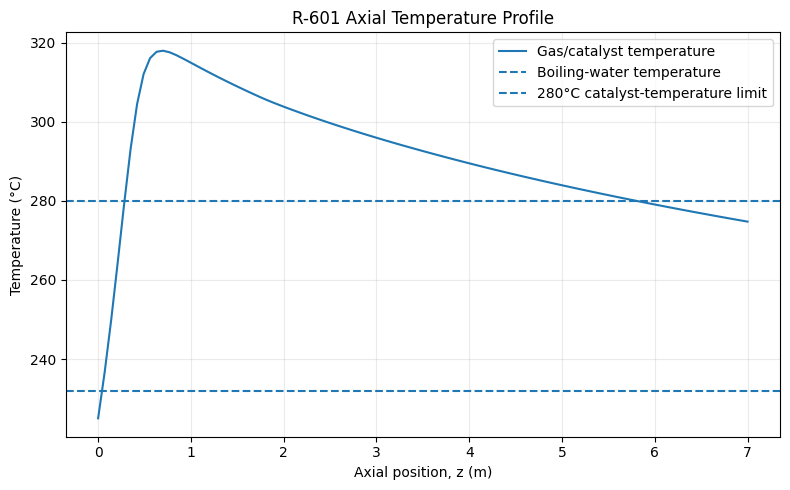

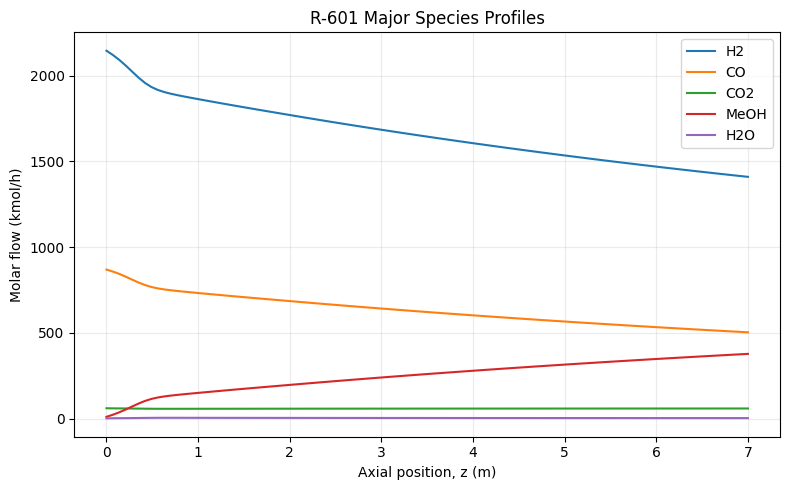

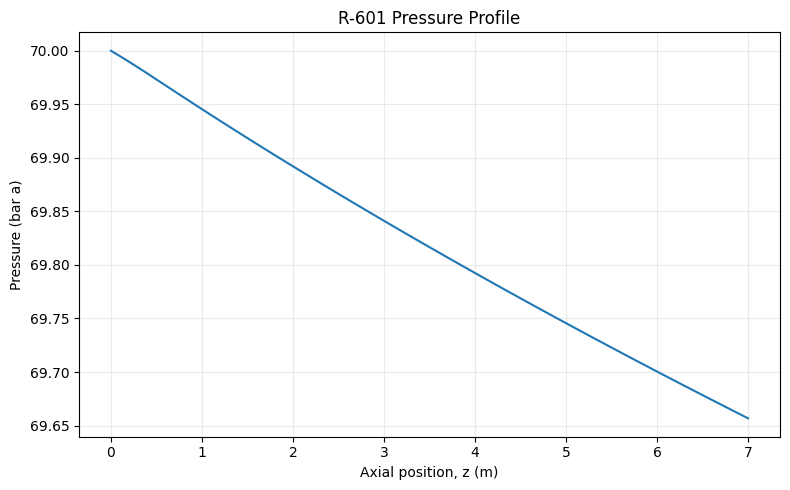

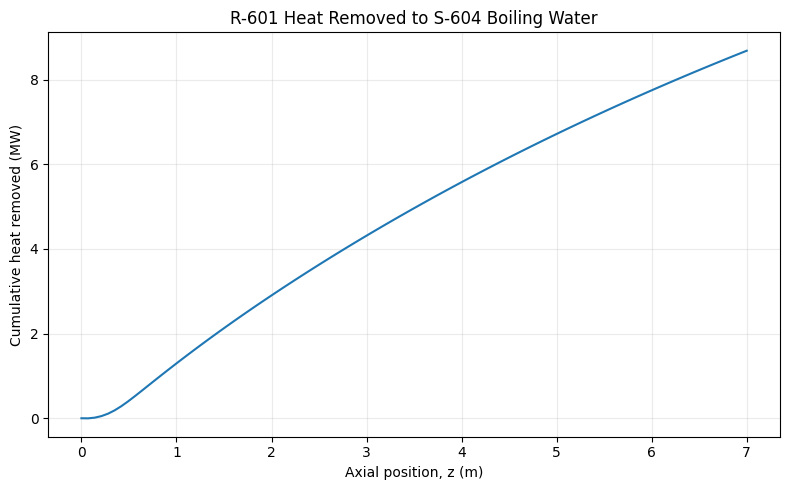

In [80]:
RESULTS_DIR = Path.cwd()/"R601_Chapter2_Final_Results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Temperature
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(profile["z_m"],profile["T_C"],label="Gas/catalyst temperature")
ax.axhline(T_COOL_C,linestyle="--",label="Boiling-water temperature")
ax.axhline(
    CATALYST_TEMPERATURE_LIMIT_C,
    linestyle="--",
    label=f"{CATALYST_TEMPERATURE_LIMIT_C:.0f}°C catalyst-temperature limit",
)
ax.set_xlabel("Axial position, z (m)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("R-601 Axial Temperature Profile")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR/"01_temperature.png",dpi=180)
plt.show()

# 2. Major species
fig, ax = plt.subplots(figsize=(8,5))
for s in ["H2","CO","CO2","MeOH","H2O"]:
    ax.plot(profile["z_m"],profile[f"F_{s}_kmol_h"],label=s)
ax.set_xlabel("Axial position, z (m)")
ax.set_ylabel("Molar flow (kmol/h)")
ax.set_title("R-601 Major Species Profiles")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR/"02_species.png",dpi=180)
plt.show()

# 3. Pressure
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(profile["z_m"],profile["P_bar"])
ax.set_xlabel("Axial position, z (m)")
ax.set_ylabel("Pressure (bar a)")
ax.set_title("R-601 Pressure Profile")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RESULTS_DIR/"03_pressure.png",dpi=180)
plt.show()

# 4. Heat removal
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(profile["z_m"],profile["Q_removed_MW"])
ax.set_xlabel("Axial position, z (m)")
ax.set_ylabel("Cumulative heat removed (MW)")
ax.set_title("R-601 Heat Removed to S-604 Boiling Water")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RESULTS_DIR/"04_heat_removed.png",dpi=180)
plt.show()

## 2.24 Model output tables and profiles

Stores the Chapter 2 reactor profiles, validation tables and associated-equipment results.


In [81]:
profile.to_csv(RESULTS_DIR/"R601_profile.csv",index=False)
pellet_node_table.to_csv(RESULTS_DIR/"pellet_nodes.csv",index=False)
external_film_check.to_csv(RESULTS_DIR/"external_mass_transfer_check.csv",index=False)
summary.to_csv(RESULTS_DIR/"summary.csv",index=False)
element_balance.to_csv(RESULTS_DIR/"element_balance.csv",index=False)
h603_verification.to_csv(RESULTS_DIR/"H603_detailed_design_verification.csv",index=False)
h604_verification.to_csv(RESULTS_DIR/"H604_design_verification.csv",index=False)
s604_summary.to_csv(RESULTS_DIR/"S604_hydraulic_and_drum_verification.csv",index=False)
k602_summary.to_csv(RESULTS_DIR/"K602_recycle_compressor.csv",index=False)

print("Saved results to:", RESULTS_DIR.resolve())

recycle_history.to_csv(RESULTS_DIR/"recycle_history.csv",index=False)
recycle_stream_table.to_csv(RESULTS_DIR/"recycle_streams.csv",index=False)
product_table.to_csv(RESULTS_DIR/"product_boundary.csv",index=False)
DIFFUSION_SENSITIVITY.to_csv(RESULTS_DIR/"internal_diffusion_sensitivity.csv",index=False)
RADIAL_VALIDATION.to_csv(RESULTS_DIR/"radial_hotspot_validation.csv",index=False)
FINAL_CHECK_TABLE.to_csv(RESULTS_DIR/"final_checks.csv",index=False)


Saved results to: C:\Users\leric\Downloads\R601_Chapter2_Final_Results


## 2.25 Design variables for sensitivity analysis

Defines the reactor and operating variables used in the Chapter 3 sensitivity and optimisation calculations. The Chapter 3 ranges retain the Chapter 2 base case for comparison while extending toward lower-temperature operation required by the 280 °C catalyst-temperature limit.


In [82]:
CHAPTER3_VARIABLES = pd.DataFrame({
    "Variable": [
        "R-601 inlet pressure",
        "Tube number",
        "Bed length",
        "R-601 inlet temperature",
        "S-604 pressure",
        "Purge fraction",
        "Tube ID",
    ],
    "Base value": [
        DESIGN["P_in_bar"],
        DESIGN["n_tubes"],
        DESIGN["bed_length_m"],
        DESIGN["T_in_C"],
        DESIGN["steam_drum_pressure_bar_abs"],
        PURGE_FRACTION,
        1000.0*DESIGN["tube_id_m"],
    ],
    "Chapter 3 range": [
        "35-60 bar(a)",
        "1200-2800",
        "5-10 m",
        "190-225 °C",
        "16-30 bar(a)",
        "0.01-0.15",
        "35-50 mm",
    ],
    "Comment": [
        "Conversion and compression versus catalyst temperature",
        "Capacity, flow area and heat-transfer area",
        "Catalyst inventory, residence time and pressure drop",
        "Kinetics and hotspot control",
        "Boiling-water temperature and cooling driving force",
        "Reactant recovery, recycle loading and inert control",
        "Hydraulics and radial heat-transfer trade-off",
    ],
})
display(CHAPTER3_VARIABLES)


,Variable,Base value,Chapter 3 range,Comment
0,R-601 inlet pressure,70.00,35-60 bar(a),Conversion and compression versus catalyst tem...
1,Tube number,1620.00,1200-2800,"Capacity, flow area and heat-transfer area"
2,Bed length,7.00,5-10 m,"Catalyst inventory, residence time and pressur..."
3,R-601 inlet temperature,225.00,190-225 °C,Kinetics and hotspot control
4,S-604 pressure,29.00,16-30 bar(a),Boiling-water temperature and cooling driving ...
5,Purge fraction,0.15,0.01-0.15,"Reactant recovery, recycle loading and inert c..."
6,Tube ID,40.00,35-50 mm,Hydraulics and radial heat-transfer trade-off


## 2.26 Detailed-model scope

The reactor model combines MegaMax catalyst loading, calculated heat transfer, internal pellet diffusion, Ergun hydraulics, S-605 separation/recycle convergence, K-602 recycle compression and the H-603/H-604/S-604 calculations into one consistent design basis.


## 2.27 Aspen implementation validation

Checks the Python reactor implementation against the Task 1 Aspen reactor basis using the same inlet state, geometry, catalyst holdup, heat-transfer coefficient and intrinsic kinetics. The primary outlet composition, methanol production, temperature, hotspot and pressure are compared on a common basis.


In [83]:
ASPEN_VALIDATION_TOLERANCE_PERCENT = 1.0

ASPEN_R601_INLET_KMOL_H = {
    "H2": 2018.19643795731,
    "CO": 804.480345592503,
    "CO2": 61.0099058743523,
    "H2O": 1.61344304486572,
    "MeOH": 10.7984451635575,
    "CH4": 177.506657421455,
    "N2": 30.7984710167818,
}

ASPEN_VALIDATION_BASIS = {
    "T_in_C": 225.0,
    "P_in_bar": 70.0,
    "P_out_bar": 67.0,
    "U_W_m2K": 118.44,
    "coolant_T_C": 231.20,
    "n_tubes": 1620,
    "tube_id_m": 0.040,
    "bed_length_m": 7.0,
    "bed_voidage": 0.285,
    "particle_density_kg_m3": 1190.0,
}

ASPEN_R601_OUTLET_KMOL_H = {
    "H2": 1259.72752293876,
    "CO": 427.113099399064,
    "CO2": 59.7650983308124,
    "H2O": 2.85825058841014,
    "MeOH": 389.410498900676,
    "CH4": 177.506657421455,
    "N2": 30.7984710167816,
}

ASPEN_R601_OUTLET_T_C = 266.986619625743
ASPEN_R601_HOTSPOT_C = 317.8
ASPEN_R601_HEAT_REMOVED_MW = 9.422
ASPEN_FINAL_MEOH_KG_H = 11999.28125800765
ASPEN_R601_MEOH_KG_H = 12477.553511455284
ASPEN_R601_TO_FINAL_RECOVERY = (ASPEN_FINAL_MEOH_KG_H / ASPEN_R601_MEOH_KG_H)

def run_aspen_validation_case():
    basis = ASPEN_VALIDATION_BASIS
    F_in = np.array([ASPEN_R601_INLET_KMOL_H[s] for s in SPECIES])/3.6

    bed_volume = (basis["n_tubes"] * np.pi*basis["tube_id_m"]**2/4.0 * basis["bed_length_m"])
    catalyst_mass = (bed_volume * (1.0-basis["bed_voidage"]) * basis["particle_density_kg_m3"])
    dW_dz = catalyst_mass/basis["bed_length_m"]
    wall_perimeter = (basis["n_tubes"] * np.pi*basis["tube_id_m"])

    y0 = np.concatenate([ F_in, [basis["T_in_C"]+273.15, basis["P_in_bar"]*1.0e5, 0.0, 0.0] ])

    def validation_rhs(z, state):
        F = np.maximum(state[:len(SPECIES)],1.0e-20)
        T_K = state[len(SPECIES)]
        P_Pa = state[len(SPECIES)+1]

        props = gas_properties(T_K,P_Pa,F)
        p_bar = props["y"]*(P_Pa/1.0e5)
        rM,rR = vbf_rates_from_partial_pressures(p_bar,T_K)

        dF_dz = dW_dz*(NU_MEOH*rM + NU_RWGS*rR)

        qM,qR = reaction_heat_release_J_mol(T_K)
        q_generated = dW_dz*(rM*qM + rR*qR)
        q_removed = (basis["U_W_m2K"] * wall_perimeter * (T_K-(basis["coolant_T_C"]+273.15)))

        cp_flow = float(F @ props["cp_species_J_molK"])
        dT_dz = (q_generated-q_removed)/cp_flow
        dP_dz = ((basis["P_out_bar"]-basis["P_in_bar"]) * 1.0e5/basis["bed_length_m"])

        return np.concatenate([ dF_dz, [dT_dz, dP_dz, q_removed, q_generated] ])

    z_eval = np.linspace(0.0, basis["bed_length_m"], SOLVER["profile_points"])

    sol = solve_ivp(validation_rhs, (0.0, basis["bed_length_m"]), y0, method=SOLVER["method"], t_eval=z_eval, rtol=SOLVER["rtol"], atol=SOLVER["atol"], max_step=SOLVER["max_step_m"])

    if not sol.success:
        raise RuntimeError(sol.message)

    rows = []
    for k,z in enumerate(sol.t):
        row = {
            "z_m": z,
            "T_C": sol.y[len(SPECIES),k]-273.15,
            "P_bar": sol.y[len(SPECIES)+1,k]/1.0e5,
            "Q_removed_MW": sol.y[len(SPECIES)+2,k]/1.0e6,
        }
        for i,s in enumerate(SPECIES):
            row[f"F_{s}_kmol_h"] = sol.y[i,k]*3.6
        rows.append(row)

    profile = pd.DataFrame(rows)
    last = profile.iloc[-1]
    meoh_out_kg_h = (last["F_MeOH_kmol_h"] * MW_G_MOL[IDX["MeOH"]])
    saleable_kg_h = (meoh_out_kg_h*ASPEN_R601_TO_FINAL_RECOVERY)

    return {
        "profile": profile,
        "catalyst_mass_kg": catalyst_mass,
        "saleable_MeOH_kg_h": saleable_kg_h,
        "saleable_MeOH_t_y": saleable_kg_h*8000.0/1000.0,
    }

ASPEN_VALIDATION_RESULT = run_aspen_validation_case()
ASPEN_VALIDATION_PROFILE = ASPEN_VALIDATION_RESULT["profile"]
ASPEN_VALIDATION_LAST = ASPEN_VALIDATION_PROFILE.iloc[-1]

validation_rows = []

for s in SPECIES:
    code_value = ASPEN_VALIDATION_LAST[f"F_{s}_kmol_h"]
    aspen_value = ASPEN_R601_OUTLET_KMOL_H[s]
    validation_rows.append({ "Metric": f"{s} outlet", "Code": code_value, "Aspen": aspen_value, "Unit": "kmol/h", "Absolute difference (%)": abs(100.0*(code_value-aspen_value)/aspen_value), "Primary <=1% check": True, })

extra_metrics = [
    (
        "R-601 outlet temperature",
        ASPEN_VALIDATION_LAST["T_C"],
        ASPEN_R601_OUTLET_T_C,
        "°C", True
    ),
    (
        "R-601 hotspot",
        ASPEN_VALIDATION_PROFILE["T_C"].max(),
        ASPEN_R601_HOTSPOT_C,
        "°C", True
    ),
    (
        "R-601 outlet pressure",
        ASPEN_VALIDATION_LAST["P_bar"],
        ASPEN_VALIDATION_BASIS["P_out_bar"],
        "bar(a)", True
    ),
    (
        "Annual saleable methanol",
        ASPEN_VALIDATION_RESULT["saleable_MeOH_t_y"],
        ASPEN_FINAL_MEOH_KG_H*8000.0/1000.0,
        "t/y", True
    ),
    (
        "R-601 heat removed",
        ASPEN_VALIDATION_LAST["Q_removed_MW"],
        ASPEN_R601_HEAT_REMOVED_MW,
        "MW", False
    ),
]

for metric,code_value,aspen_value,unit,primary in extra_metrics:
    validation_rows.append({ "Metric": metric, "Code": code_value, "Aspen": aspen_value, "Unit": unit, "Absolute difference (%)": abs(100.0*(code_value-aspen_value)/aspen_value), "Primary <=1% check": primary, })

ASPEN_VALIDATION_TABLE = pd.DataFrame(validation_rows)

ASPEN_VALIDATION_MAX_PRIMARY_ERROR_PERCENT = float(ASPEN_VALIDATION_TABLE.loc[ ASPEN_VALIDATION_TABLE["Primary <=1% check"], "Absolute difference (%)" ].max())
ASPEN_VALIDATION_HEAT_DUTY_ERROR_PERCENT = float(ASPEN_VALIDATION_TABLE.loc[ ASPEN_VALIDATION_TABLE["Metric"]=="R-601 heat removed", "Absolute difference (%)" ].iloc[0])
ASPEN_VALIDATION_PRIMARY_PASS = bool(ASPEN_VALIDATION_MAX_PRIMARY_ERROR_PERCENT <= ASPEN_VALIDATION_TOLERANCE_PERCENT)

display(pd.DataFrame({
    "Aspen validation basis": [
        "Validation catalyst inventory",
        "Fixed U",
        "Fixed pressure drop",
        "Coolant temperature",
        "Internal diffusion correction",
    ],
    "Value": [
        ASPEN_VALIDATION_RESULT["catalyst_mass_kg"]/1000.0,
        ASPEN_VALIDATION_BASIS["U_W_m2K"],
        ASPEN_VALIDATION_BASIS["P_in_bar"]
        - ASPEN_VALIDATION_BASIS["P_out_bar"],
        ASPEN_VALIDATION_BASIS["coolant_T_C"],
        "Off: intrinsic VBF, matching Aspen",
    ],
    "Unit": ["t","W/m²/K","bar","°C","-"]
}))
display(ASPEN_VALIDATION_TABLE)

print("Maximum primary Aspen-validation error = " f"{ASPEN_VALIDATION_MAX_PRIMARY_ERROR_PERCENT:.3f}%")
print("Aspen primary validation passes 1% tolerance:", ASPEN_VALIDATION_PRIMARY_PASS)
print("Heat-duty diagnostic difference = " f"{ASPEN_VALIDATION_HEAT_DUTY_ERROR_PERCENT:.3f}%")

if not ASPEN_VALIDATION_PRIMARY_PASS:
    raise RuntimeError("Aspen validation exceeded the 1% primary-output tolerance.")

# Save the supporting validation results after the check has been run.
ASPEN_VALIDATION_PROFILE.to_csv(RESULTS_DIR/"Aspen_validation_profile.csv", index=False)
ASPEN_VALIDATION_TABLE.to_csv(RESULTS_DIR/"Aspen_validation_comparison.csv", index=False)


,Aspen validation basis,Value,Unit
0,Validation catalyst inventory,12.124837,t
1,Fixed U,118.44,W/m²/K
2,Fixed pressure drop,3.0,bar
3,Coolant temperature,231.2,°C
4,Internal diffusion correction,"Off: intrinsic VBF, matching Aspen",-


,Metric,Code,Aspen,Unit,Absolute difference (%),Primary <=1% check
0,H2 outlet,1257.676444,1259.727523,kmol/h,1.628192e-01,True
1,CO outlet,426.074225,427.113099,kmol/h,2.432318e-01,True
2,CO2 outlet,59.773989,59.765098,kmol/h,1.487523e-02,True
3,H2O outlet,2.849360,2.858251,kmol/h,3.110362e-01,True
4,MeOH outlet,390.440483,389.410499,kmol/h,2.644984e-01,True
5,CH4 outlet,177.506657,177.506657,kmol/h,0.000000e+00,True
6,N2 outlet,30.798471,30.798471,kmol/h,6.459800e-13,True
7,R-601 outlet temperature,266.554256,266.986620,°C,1.619419e-01,True
8,R-601 hotspot,317.334322,317.800000,°C,1.465316e-01,True
9,R-601 outlet pressure,67.000000,67.000000,bar(a),2.121023e-14,True


Maximum primary Aspen-validation error = 0.311%
Aspen primary validation passes 1% tolerance: True
Heat-duty diagnostic difference = 1.281%


# Chapter 3 — Sensitivity Analysis and Optimisation

Applies single-variable sensitivity analysis, coupled-variable studies, total annualised cost calculations and simultaneous multivariable optimisation to select the R-601 design from the Chapter 2 model.

## 3.1 Sensitivity-analysis method

Each variable is changed independently while the remaining Chapter 2 basis is fixed. Every case reconverges the synthesis loop and refreshes the reactor heat-transfer and pellet-diffusion calculations. Saleable methanol, maximum reactor temperature and recycle flow are used as the common performance indicators, with variable-specific diagnostics added where required.

## 3.2 Variables, design limits and pressure treatment

The production requirement and the **280 °C maximum catalyst-temperature limit** define the feasible design region. The investigated ranges are shifted toward lower reactor inlet temperature, lower boiling-water pressure and lower synthesis pressure because these variables reduce the catalyst hotspot. Lower purge fractions and increased reactor capacity are retained to recover methanol production at the cooler operating conditions. Off-design reactor pressure is coupled to S-605 through the pressure-dependent separator screening relation anchored to the reference recovery fractions.


In [84]:
# Chapter 3 sensitivity framework
CH3_LIMITS = {
    "minimum_saleable_meoh_t_y": 95000.0,
    "maximum_hotspot_C": CATALYST_TEMPERATURE_LIMIT_C,
    "minimum_H604_hot_end_approach_C": 5.0,
}

CH3_BASE = {
    "T_in_C": float(DESIGN["T_in_C"]),
    "P_in_bar": float(DESIGN["P_in_bar"]),
    "n_tubes": int(DESIGN["n_tubes"]),
    "tube_id_m": float(DESIGN["tube_id_m"]),
    "bed_length_m": float(DESIGN["bed_length_m"]),
    "steam_drum_pressure_bar_abs": float(DESIGN["steam_drum_pressure_bar_abs"]),
    "purge_fraction": float(PURGE_FRACTION),
    "U_W_m2K": float(DESIGN["U_W_m2K"]),
    "reactor_outlet_pressure_bar": float(profile["P_bar"].iloc[-1]),
    "recycle_mol_s": FINAL_SEPARATOR["recycle"].copy(),
    "correction": final_correction,
}

# Screening values cover the ranges used to identify slopes, turning points
# and design-limit crossings.
CH3_SENSITIVITY_PLAN = {
    "pressure": {
        "label": "R-601 inlet pressure",
        "unit": "bar(a)",
        "values": [35.0, 40.0, 45.0, 50.0, 55.0, 60.0],
        "diagnostics": ["single_pass_COx_conversion_pct", "K601_power_MW"],
    },
    "temperature": {
        "label": "R-601 inlet temperature",
        "unit": "°C",
        "values": [190.0, 195.0, 200.0, 205.0, 210.0, 215.0, 220.0, 225.0],
        "diagnostics": ["hotspot_z_m"],
    },
    "steam_pressure": {
        "label": "S-604 steam-drum pressure",
        "unit": "bar(a)",
        "values": [16.0, 18.0, 20.0, 22.0, 25.0, 29.0, 30.0],
        "diagnostics": ["coolant_T_C", "H604_hot_end_approach_C"],
    },
    "purge": {
        "label": "Purge fraction",
        "unit": "fraction",
        "values": [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.10, 0.15],
        "diagnostics": ["purge_reactive_kmol_h"],
    },
    "tube_number": {
        "label": "Number of reactor tubes",
        "unit": "-",
        "values": [1200, 1620, 2000, 2400, 2800],
        "diagnostics": ["deltaP_bar", "catalyst_mass_t"],
    },
    "bed_length": {
        "label": "Catalyst-bed length",
        "unit": "m",
        "values": [5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
        "diagnostics": ["deltaP_bar", "catalyst_mass_t"],
    },
    "tube_id": {
        "label": "Tube internal diameter",
        "unit": "mm",
        "values": [35.0, 40.0, 45.0, 50.0],
        "diagnostics": ["deltaP_bar", "U_mean_W_m2K"],
    },
}

plan_rows = []
for key, item in CH3_SENSITIVITY_PLAN.items():
    plan_rows.append({
        "Sensitivity": key,
        "Variable": item["label"],
        "Values": ", ".join(str(v) for v in item["values"]),
        "Unit": item["unit"],
        "Extra diagnostic(s)": ", ".join(item["diagnostics"]),
    })
CH3_PLAN_TABLE = pd.DataFrame(plan_rows)
display(CH3_PLAN_TABLE)


# Pressure sensitivity needs an off-design S-605 screening correction.
# At 38 °C the Aspen component vapour recoveries are retained exactly at
# 66.35 bar(a). Away from that pressure, only the vapour/liquid recovery odds
# are scaled inversely with absolute pressure. This is deliberately a local
# screening approximation anchored to the reference separator state.
def s605_vapor_recovery_for_pressure(P_sep_bar):
    P = max(float(P_sep_bar), 1.0)
    r_ref = np.clip(S605_VAPOR_RECOVERY, 1.0e-9, 1.0-1.0e-9)
    odds_ref = r_ref/(1.0-r_ref)
    odds = odds_ref*(S605_REFERENCE_P_BAR/P)
    return odds/(1.0+odds)


def separator_boundary_ch3(F_reactor_out_mol_s, purge_fraction, pressure_sensitive=False, P_sep_bar=None):
    F_out = np.asarray(F_reactor_out_mol_s, dtype=float)
    if pressure_sensitive:
        if P_sep_bar is None:
            raise ValueError("P_sep_bar is required for the pressure sensitivity.")
        recovery = s605_vapor_recovery_for_pressure(P_sep_bar)
    else:
        recovery = S605_VAPOR_RECOVERY

    vapor = recovery*F_out
    liquid = F_out-vapor
    purge = float(purge_fraction)*vapor
    recycle = (1.0-float(purge_fraction))*vapor
    closure = np.max(np.abs(F_out-(liquid+purge+recycle))/np.maximum(np.abs(F_out),1.0e-12))
    return {
        "vapor": vapor,
        "liquid": liquid,
        "purge": purge,
        "recycle": recycle,
        "closure": float(closure),
        "vapor_recovery": recovery,
    }


# Simple two-stage polytropic estimate used only as the pressure-sensitivity
# compression diagnostic. The detailed compressor design remains in Task 1.
def estimate_K601_power_MW(P_reactor_bar, eta_p=0.78):
    P1_bar = 29.25
    P2_bar = float(P_reactor_bar) + 0.80
    if P2_bar <= P1_bar:
        return 0.0

    F = np.array([FRESH_FEED_KMOL_H[s] for s in SPECIES], dtype=float)/3.6
    F_total = float(F.sum())
    stage_ratio = (P2_bar/P1_bar)**0.5
    T1_K = 313.15
    power_W = 0.0
    P_stage_in = P1_bar

    for _ in range(2):
        P_stage_out = P_stage_in*stage_ratio
        props = gas_properties(T1_K, 0.5*(P_stage_in+P_stage_out)*1.0e5, F)
        Cp = float(props["cp_molar_J_molK"])
        gamma = Cp/max(Cp-R, 1.0e-12)
        exponent = (gamma-1.0)/(gamma*eta_p)
        T2_K = T1_K*(P_stage_out/P_stage_in)**exponent
        power_W += F_total*Cp*(T2_K-T1_K)
        P_stage_in = P_stage_out

    return power_W/1.0e6

,Sensitivity,Variable,Values,Unit,Extra diagnostic(s)
0,pressure,R-601 inlet pressure,"35.0, 40.0, 45.0, 50.0, 55.0, 60.0",bar(a),"single_pass_COx_conversion_pct, K601_power_MW"
1,temperature,R-601 inlet temperature,"190.0, 195.0, 200.0, 205.0, 210.0, 215.0, 220....",°C,hotspot_z_m
2,steam_pressure,S-604 steam-drum pressure,"16.0, 18.0, 20.0, 22.0, 25.0, 29.0, 30.0",bar(a),"coolant_T_C, H604_hot_end_approach_C"
3,purge,Purge fraction,"0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.15",fraction,purge_reactive_kmol_h
4,tube_number,Number of reactor tubes,"1200, 1620, 2000, 2400, 2800",-,"deltaP_bar, catalyst_mass_t"
5,bed_length,Catalyst-bed length,"5.0, 6.0, 7.0, 8.0, 9.0, 10.0",m,"deltaP_bar, catalyst_mass_t"
6,tube_id,Tube internal diameter,"35.0, 40.0, 45.0, 50.0",mm,"deltaP_bar, U_mean_W_m2K"


## 3.3 Reusable Chapter 3 design-case evaluator

Evaluates a complete trial design by updating the selected variables, converging the synthesis loop, refreshing the reactor transport calculations and returning the required performance, feasibility and equipment results.

In [85]:
# Recycle convergence with U and pellet corrections held fixed during one
# material iteration block. The expensive transport model is refreshed after
# the material loop has converged.
def _converge_ch3_recycle(fresh_F, recycle_guess, correction, U_W_m2K, purge_fraction,
                          pressure_sensitive=False, max_iter=40, tol=1.0e-5):
    recycle = np.asarray(recycle_guess, dtype=float).copy()
    last_profile = None
    last_boundary = None
    comp_err = np.inf
    total_err = np.inf

    for iteration in range(1, max_iter+1):
        mixed = fresh_F + recycle
        _, trial_profile = run_reactor(correction, mixed, U_W_m2K)

        if pressure_sensitive:
            # Keep the base downstream pressure loss from R-601 outlet to S-605.
            P_sep_bar = S605_REFERENCE_P_BAR + (
                float(trial_profile["P_bar"].iloc[-1]) - CH3_BASE["reactor_outlet_pressure_bar"]
            )
        else:
            P_sep_bar = S605_REFERENCE_P_BAR

        boundary = separator_boundary_ch3(
            outlet_vector(trial_profile), purge_fraction,
            pressure_sensitive=pressure_sensitive, P_sep_bar=P_sep_bar,
        )
        recycle_calc = boundary["recycle"]
        comp_err, total_err = recycle_error(recycle_calc, recycle)
        last_profile = trial_profile
        last_boundary = boundary

        if comp_err < tol and total_err < tol:
            recycle = recycle_calc.copy()
            break

        recycle = (1.0-RECYCLE_RELAXATION)*recycle + RECYCLE_RELAXATION*recycle_calc

    return {
        "recycle": recycle,
        "profile": last_profile,
        "boundary": last_boundary,
        "iterations": iteration,
        "component_error": float(comp_err),
        "total_error": float(total_err),
        "converged": bool(comp_err < tol and total_err < tol),
    }


# One self-contained Chapter 3 trial. Only DESIGN/global quantities required by
# the established Chapter 2 functions are changed, and all are restored before
# returning so one sensitivity point cannot contaminate the next one.
def evaluate_ch3_design(T_in_C=None, P_in_bar=None, n_tubes=None, tube_id_m=None,
                        bed_length_m=None, steam_pressure_bar=None, purge_fraction=None,
                        pressure_sensitive_separator=False, recycle_max_iter=40):
    global GEOM, T_COOL_C, T_COOL_K, PURGE_FRACTION, RECYCLE_FRACTION

    saved_design = DESIGN.copy()
    saved_geom = GEOM.copy()
    saved_T_cool_C = T_COOL_C
    saved_T_cool_K = T_COOL_K
    saved_purge = PURGE_FRACTION
    saved_recycle_fraction = RECYCLE_FRACTION

    try:
        if T_in_C is not None:
            DESIGN["T_in_C"] = float(T_in_C)
        if P_in_bar is not None:
            DESIGN["P_in_bar"] = float(P_in_bar)
        if n_tubes is not None:
            DESIGN["n_tubes"] = int(round(n_tubes))
        if tube_id_m is not None:
            DESIGN["tube_id_m"] = float(tube_id_m)
        if bed_length_m is not None:
            DESIGN["bed_length_m"] = float(bed_length_m)
        if steam_pressure_bar is not None:
            DESIGN["steam_drum_pressure_bar_abs"] = float(steam_pressure_bar)

        case_purge = CH3_BASE["purge_fraction"] if purge_fraction is None else float(purge_fraction)
        PURGE_FRACTION = case_purge
        RECYCLE_FRACTION = 1.0-case_purge

        # Refresh geometry and boiling-water boundary for this design point.
        GEOM = reactor_geometry()
        T_COOL_C = water_saturation_temperature_C(DESIGN["steam_drum_pressure_bar_abs"])
        T_COOL_K = T_COOL_C + 273.15

        fresh_F = np.array([FRESH_FEED_KMOL_H[s] for s in SPECIES], dtype=float)/3.6

        # Stage 1: material loop from the converged Chapter 2 physics.
        first = _converge_ch3_recycle(
            fresh_F=fresh_F,
            recycle_guess=CH3_BASE["recycle_mol_s"],
            correction=CH3_BASE["correction"],
            U_W_m2K=CH3_BASE["U_W_m2K"],
            purge_fraction=case_purge,
            pressure_sensitive=pressure_sensitive_separator,
            max_iter=recycle_max_iter,
        )

        mixed_for_physics = fresh_F + first["recycle"]

        # Refresh the expensive reactor physics once on the changed steady-state feed.
        physics = build_reactor_physics(
            mixed_for_physics,
            U_guess=CH3_BASE["U_W_m2K"],
            correction_guess=CH3_BASE["correction"],
        )

        # Stage 2: reconverge recycle with the updated U and pellet correction.
        second = _converge_ch3_recycle(
            fresh_F=fresh_F,
            recycle_guess=first["recycle"],
            correction=physics["correction"],
            U_W_m2K=physics["U_W_m2K"],
            purge_fraction=case_purge,
            pressure_sensitive=pressure_sensitive_separator,
            max_iter=recycle_max_iter,
        )

        final_feed = fresh_F + second["recycle"]
        feed_shift = np.max(
            np.abs(final_feed-mixed_for_physics)/np.maximum(np.abs(mixed_for_physics), 1.0e-9)
        )

        # If the transport refresh materially changed the recycle, refresh once more.
        if feed_shift > 0.01:
            physics = build_reactor_physics(
                final_feed,
                U_guess=physics["U_W_m2K"],
                correction_guess=physics["correction"],
            )
            second = _converge_ch3_recycle(
                fresh_F=fresh_F,
                recycle_guess=second["recycle"],
                correction=physics["correction"],
                U_W_m2K=physics["U_W_m2K"],
                purge_fraction=case_purge,
                pressure_sensitive=pressure_sensitive_separator,
                max_iter=recycle_max_iter,
            )
            final_feed = fresh_F + second["recycle"]

        _, final_profile = run_reactor(physics["correction"], final_feed, physics["U_W_m2K"])

        if pressure_sensitive_separator:
            P_sep_bar = S605_REFERENCE_P_BAR + (
                float(final_profile["P_bar"].iloc[-1]) - CH3_BASE["reactor_outlet_pressure_bar"]
            )
        else:
            P_sep_bar = S605_REFERENCE_P_BAR

        final_boundary = separator_boundary_ch3(
            outlet_vector(final_profile), case_purge,
            pressure_sensitive=pressure_sensitive_separator, P_sep_bar=P_sep_bar,
        )

        liquid_meoh_kmol_h = final_boundary["liquid"][IDX["MeOH"]]*3.6
        liquid_meoh_t_h = liquid_meoh_kmol_h*MW_G_MOL[IDX["MeOH"]]/1000.0
        saleable_meoh_t_y = liquid_meoh_t_h*PURIFICATION_MEOH_RECOVERY*8000.0

        T_values = final_profile["T_C"].to_numpy(dtype=float)
        i_hot = int(np.argmax(T_values))
        Tmax_C = float(T_values[i_hot])
        hotspot_z_m = float(final_profile["z_m"].iloc[i_hot])
        deltaP_bar = float(final_profile["P_bar"].iloc[0]-final_profile["P_bar"].iloc[-1])

        Fin_COx = float(final_profile[["F_CO_kmol_h", "F_CO2_kmol_h"]].iloc[0].sum())
        Fout_COx = float(final_profile[["F_CO_kmol_h", "F_CO2_kmol_h"]].iloc[-1].sum())
        single_pass_COx_conversion_pct = 100.0*(Fin_COx-Fout_COx)/max(Fin_COx, 1.0e-12)

        recycle_kmol_h = float(second["recycle"].sum()*3.6)
        reactor_feed_kmol_h = float(final_feed.sum()*3.6)
        reactor_outlet_kmol_h = float(outlet_vector(final_profile).sum()*3.6)
        reactor_outlet_T_C = float(final_profile["T_C"].iloc[-1])
        reactor_heat_removed_MW = float(final_profile["Q_removed_MW"].iloc[-1])
        inert_mol_pct = 100.0*float(
            final_feed[[IDX["CH4"], IDX["N2"]]].sum()/max(final_feed.sum(), 1.0e-12)
        )
        purge_reactive_kmol_h = float(
            final_boundary["purge"][[IDX["H2"], IDX["CO"], IDX["CO2"]]].sum()*3.6
        )

        k602_case = recycle_compressor_performance(
            final_boundary["recycle"],
            P1_bar=P_sep_bar,
            P2_bar=float(DESIGN["P_in_bar"])+0.45,
            T1_C=S605_REFERENCE_T_C,
            eta_p=K602["polytropic_efficiency"],
        )

        H604_hot_end_approach_C = float(T_COOL_C-DESIGN["T_in_C"])
        H604_screening_pass = bool(
            DESIGN["T_in_C"] <= 210.0
            or H604_hot_end_approach_C >= CH3_LIMITS["minimum_H604_hot_end_approach_C"]
        )
        production_pass = bool(saleable_meoh_t_y >= CH3_LIMITS["minimum_saleable_meoh_t_y"])
        hotspot_pass = bool(Tmax_C <= CH3_LIMITS["maximum_hotspot_C"])
        recycle_pass = bool(second["converged"])
        screening_pass = bool(production_pass and hotspot_pass and H604_screening_pass and recycle_pass)

        return {
            "T_in_C": float(DESIGN["T_in_C"]),
            "P_in_bar": float(DESIGN["P_in_bar"]),
            "n_tubes": int(DESIGN["n_tubes"]),
            "tube_id_mm": 1000.0*float(DESIGN["tube_id_m"]),
            "bed_length_m": float(DESIGN["bed_length_m"]),
            "steam_pressure_bar": float(DESIGN["steam_drum_pressure_bar_abs"]),
            "purge_fraction": float(case_purge),
            "saleable_meoh_t_y": float(saleable_meoh_t_y),
            "Tmax_C": Tmax_C,
            "recycle_kmol_h": recycle_kmol_h,
            "reactor_feed_kmol_h": reactor_feed_kmol_h,
            "reactor_outlet_kmol_h": reactor_outlet_kmol_h,
            "reactor_outlet_T_C": reactor_outlet_T_C,
            "reactor_heat_removed_MW": reactor_heat_removed_MW,
            "inert_mol_pct": float(inert_mol_pct),
            "single_pass_COx_conversion_pct": float(single_pass_COx_conversion_pct),
            "K601_power_MW": float(estimate_K601_power_MW(DESIGN["P_in_bar"])),
            "K602_power_MW": float(k602_case["power_MW"]),
            "K602_discharge_T_C": float(k602_case["T_out_C"]),
            "hotspot_z_m": hotspot_z_m,
            "coolant_T_C": float(T_COOL_C),
            "H604_hot_end_approach_C": H604_hot_end_approach_C,
            "purge_reactive_kmol_h": purge_reactive_kmol_h,
            "deltaP_bar": deltaP_bar,
            "catalyst_mass_t": float(GEOM["catalyst_mass_kg"])/1000.0,
            "U_mean_W_m2K": float(physics["local_U_mean_W_m2K"]),
            "S605_pressure_bar": float(P_sep_bar),
            "production_pass": production_pass,
            "hotspot_pass": hotspot_pass,
            "H604_screening_pass": H604_screening_pass,
            "recycle_converged": recycle_pass,
            "recycle_iterations": int(second["iterations"]),
            "recycle_component_error": float(second["component_error"]),
            "recycle_total_error": float(second["total_error"]),
            "screening_pass": screening_pass,
        }

    except Exception as exc:
        return {
            "error": str(exc),
            "screening_pass": False,
            "recycle_converged": False,
        }

    finally:
        DESIGN.clear()
        DESIGN.update(saved_design)
        GEOM = saved_geom
        T_COOL_C = saved_T_cool_C
        T_COOL_K = saved_T_cool_K
        PURGE_FRACTION = saved_purge
        RECYCLE_FRACTION = saved_recycle_fraction


In [86]:
CH3_COMMON_OUTPUTS = ["saleable_meoh_t_y", "Tmax_C", "recycle_kmol_h"]


def run_ch3_sensitivity(name):
    if name not in CH3_SENSITIVITY_PLAN:
        raise KeyError(f"Unknown sensitivity: {name}")

    plan = CH3_SENSITIVITY_PLAN[name]
    rows = []

    for value in plan["values"]:
        kwargs = {}
        if name == "pressure":
            kwargs = {"P_in_bar": value, "pressure_sensitive_separator": True}
        elif name == "temperature":
            kwargs = {"T_in_C": value}
        elif name == "steam_pressure":
            kwargs = {"steam_pressure_bar": value}
        elif name == "purge":
            kwargs = {"purge_fraction": value, "recycle_max_iter": 150}
        elif name == "tube_number":
            kwargs = {"n_tubes": value}
        elif name == "bed_length":
            kwargs = {"bed_length_m": value}
        elif name == "tube_id":
            kwargs = {"tube_id_m": value/1000.0}

        result = evaluate_ch3_design(**kwargs)
        result["sensitivity"] = name
        result["x_value"] = value
        rows.append(result)

    table = pd.DataFrame(rows)
    if "error" in table.columns and table["error"].notna().any():
        print(table.loc[table["error"].notna(), ["x_value", "error"]])

    show_cols = ["x_value"] + CH3_COMMON_OUTPUTS + plan["diagnostics"] + ["screening_pass"]
    show_cols = [c for c in show_cols if c in table.columns]
    display(table[show_cols])
    plot_ch3_sensitivity(table, name)
    return table


def plot_ch3_sensitivity(table, name):
    plan = CH3_SENSITIVITY_PLAN[name]
    clean = table.dropna(subset=["x_value"])
    if clean.empty:
        return

    # Three common indicators used for every OFAT study.
    common = [
        ("saleable_meoh_t_y", "Saleable methanol (t/y)", CH3_LIMITS["minimum_saleable_meoh_t_y"]),
        ("Tmax_C", "Maximum reactor temperature (°C)", CH3_LIMITS["maximum_hotspot_C"]),
        ("recycle_kmol_h", "Recycle flow (kmol/h)", None),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (col, ylabel, limit) in zip(axes, common):
        if col not in clean.columns:
            continue
        ax.plot(clean["x_value"], clean[col], marker="o")
        if limit is not None:
            ax.axhline(limit, linestyle="--")
        ax.set_xlabel(f"{plan['label']} ({plan['unit']})")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
    fig.suptitle(f"Single-variable sensitivity: {plan['label']}")
    fig.tight_layout()
    plt.show()

    # Only the diagnostic(s) that explain this particular variable.
    diagnostics = [c for c in plan["diagnostics"] if c in clean.columns]
    if diagnostics:
        fig, axes = plt.subplots(1, len(diagnostics), figsize=(5.5*len(diagnostics), 4))
        if len(diagnostics) == 1:
            axes = [axes]
        for ax, col in zip(axes, diagnostics):
            ax.plot(clean["x_value"], clean[col], marker="o")
            ax.set_xlabel(f"{plan['label']} ({plan['unit']})")
            ax.set_ylabel(col.replace("_", " "))
            ax.grid(alpha=0.25)
        fig.suptitle(f"Cause-and-effect diagnostic: {plan['label']}")
        fig.tight_layout()
        plt.show()

### 3.3.1 Base-case reproduction

Confirms that the Chapter 3 evaluator reproduces the Chapter 2 base case before the sensitivity results are interpreted.

In [87]:
# Run once before the individual sensitivities.
CH3_BASE_CHECK = evaluate_ch3_design()

if "error" in CH3_BASE_CHECK:
    print("Chapter 3 base-case evaluator error:", CH3_BASE_CHECK["error"])
else:
    chapter2_recycle_kmol_h = float(FINAL_SEPARATOR["recycle"].sum()*3.6)
    CH3_BASE_COMPARISON = pd.DataFrame({
        "Quantity": ["Saleable methanol", "Maximum reactor temperature", "Recycle flow"],
        "Chapter 2": [SALEABLE_MEOH_T_Y, T_PEAK_C, chapter2_recycle_kmol_h],
        "Chapter 3 evaluator": [
            CH3_BASE_CHECK["saleable_meoh_t_y"],
            CH3_BASE_CHECK["Tmax_C"],
            CH3_BASE_CHECK["recycle_kmol_h"],
        ],
        "Unit": ["t/y", "°C", "kmol/h"],
    })
    CH3_BASE_COMPARISON["Difference %"] = (
        100.0*(CH3_BASE_COMPARISON["Chapter 3 evaluator"]-CH3_BASE_COMPARISON["Chapter 2"])
        / CH3_BASE_COMPARISON["Chapter 2"]
    )
    display(CH3_BASE_COMPARISON)

,Quantity,Chapter 2,Chapter 3 evaluator,Unit,Difference %
0,Saleable methanol,93097.893960,93098.392311,t/y,0.000535
1,Maximum reactor temperature,317.976601,317.981596,°C,0.001571
2,Recycle flow,1858.445837,1858.471502,kmol/h,0.001381


## 3.4 Single-variable sensitivity analysis

Quantifies the individual effect of each design variable using the common performance indicators and the minimum additional diagnostics needed to explain the observed behaviour.

### 3.4.1 R-601 inlet pressure

Evaluates the effect of synthesis pressure on production, hotspot, recycle, single-pass carbon-oxide conversion and fresh-syngas compression power.

,x_value,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,single_pass_COx_conversion_pct,K601_power_MW,screening_pass
0,35.0,72139.807115,286.049355,3259.179184,20.462195,0.274444,False
1,40.0,77120.895602,292.271387,2927.017757,23.722144,0.457470,False
2,45.0,81087.237477,297.713814,2662.288923,26.752235,0.622986,False
3,50.0,84336.474489,302.538709,2445.245235,29.591880,0.774332,False
4,55.0,87054.871866,306.910674,2263.443296,32.268156,0.913949,False
5,60.0,89418.844539,310.892348,2105.405322,34.857860,1.043685,False


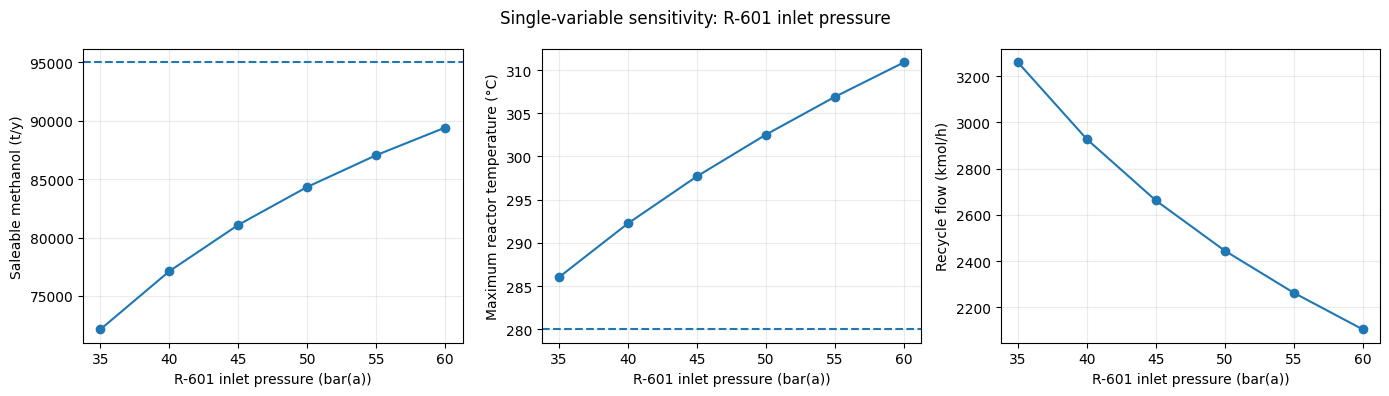

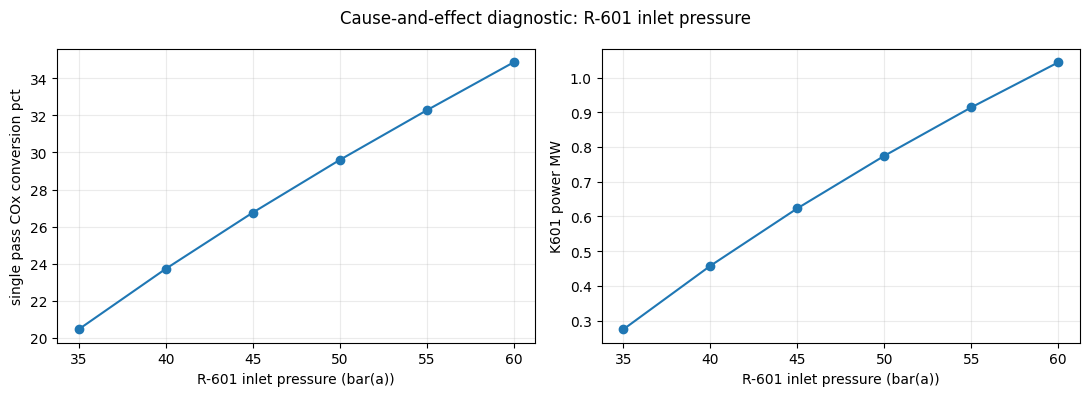

In [88]:
pressure_sensitivity = run_ch3_sensitivity("pressure")

### 3.4.2 R-601 inlet temperature

Evaluates the effect of inlet temperature on production, hotspot, recycle and the axial hotspot position.

,x_value,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,hotspot_z_m,screening_pass
0,190.0,92170.557819,311.590300,1920.119227,1.40,False
1,195.0,92517.092094,311.768996,1897.119471,1.26,False
2,200.0,92762.813493,312.192741,1880.800259,1.19,False
3,205.0,92942.013325,312.929840,1868.906961,1.05,False
4,210.0,93060.119701,313.848128,1861.063467,0.98,False
5,215.0,93082.681274,315.134608,1859.465377,0.84,False
6,220.0,93114.354978,316.508973,1857.374592,0.77,False
7,225.0,93098.392311,317.981596,1858.471502,0.70,False


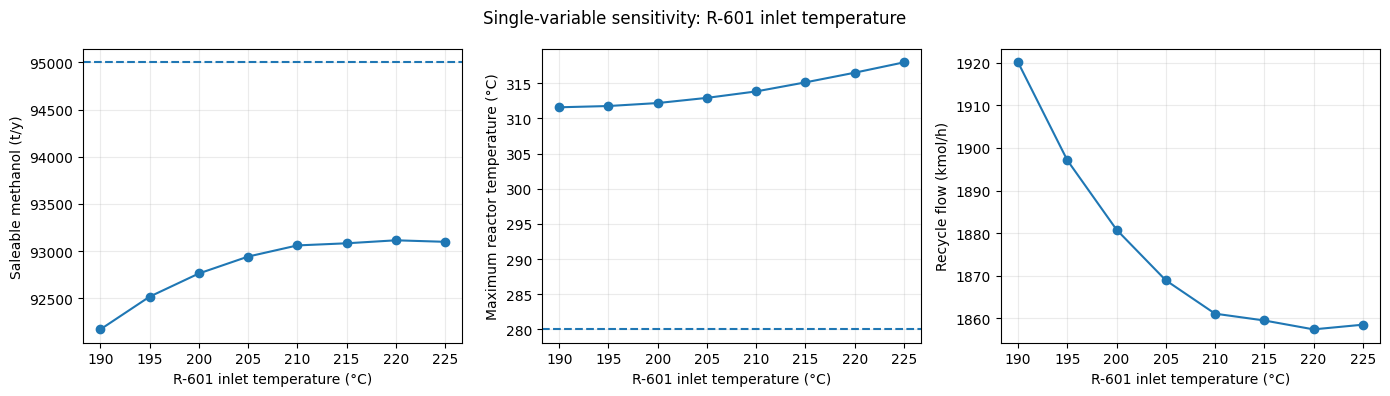

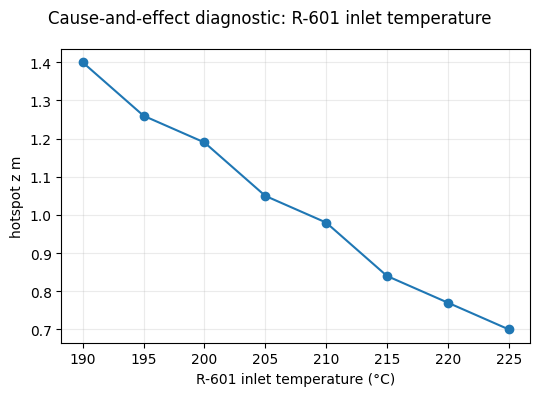

In [89]:
temperature_sensitivity = run_ch3_sensitivity("temperature")

### 3.4.3 S-604 steam-drum pressure

Evaluates the effect of steam-drum pressure on production, hotspot, recycle, coolant saturation temperature and the H-604 hot-end temperature approach.

,x_value,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,coolant_T_C,H604_hot_end_approach_C,screening_pass
0,16.0,101962.890394,312.656894,1269.957620,201.378308,-23.621692,False
1,18.0,100512.374086,313.756473,1366.310572,207.119580,-17.880420,False
2,20.0,99079.276974,314.645438,1461.475971,212.384535,-12.615465,False
3,22.0,97655.209060,315.447787,1556.018578,217.255778,-7.744222,False
4,25.0,95380.476304,316.804174,1707.049691,223.956487,-1.043513,False
5,29.0,93098.392311,317.981596,1858.471502,231.985687,6.985687,False
6,30.0,92471.184699,318.322802,1900.163591,233.858445,8.858445,False


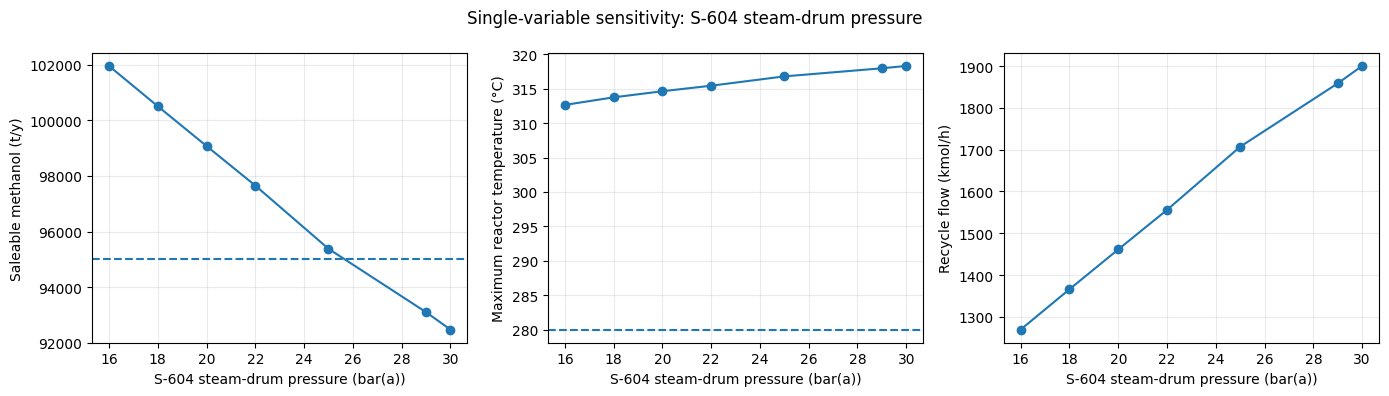

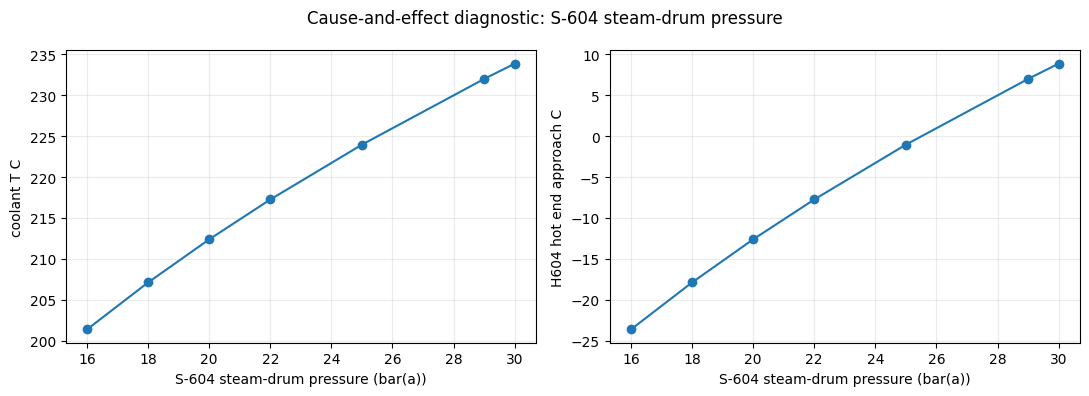

In [91]:
steam_pressure_sensitivity = run_ch3_sensitivity("steam_pressure")

### 3.4.4 Purge fraction

Evaluates the effect of purge fraction on production, hotspot, recycle and reactive-gas loss from the synthesis loop.

,x_value,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,purge_reactive_kmol_h,screening_pass
0,0.010,112393.165092,288.860211,7783.563482,59.273165,False
1,0.020,110556.719507,297.588962,5397.979756,85.476125,False
2,0.030,108761.293990,302.652809,4358.323051,107.753224,False
3,0.040,107065.370178,306.266943,3763.227367,128.387122,False
4,0.050,105459.473539,308.825325,3365.803282,147.799163,False
5,0.075,101803.984695,312.779796,2744.408752,191.711559,False
6,0.100,98578.131808,315.175488,2357.117276,230.189479,False
7,0.150,93098.392311,317.981596,1858.471502,295.071548,False


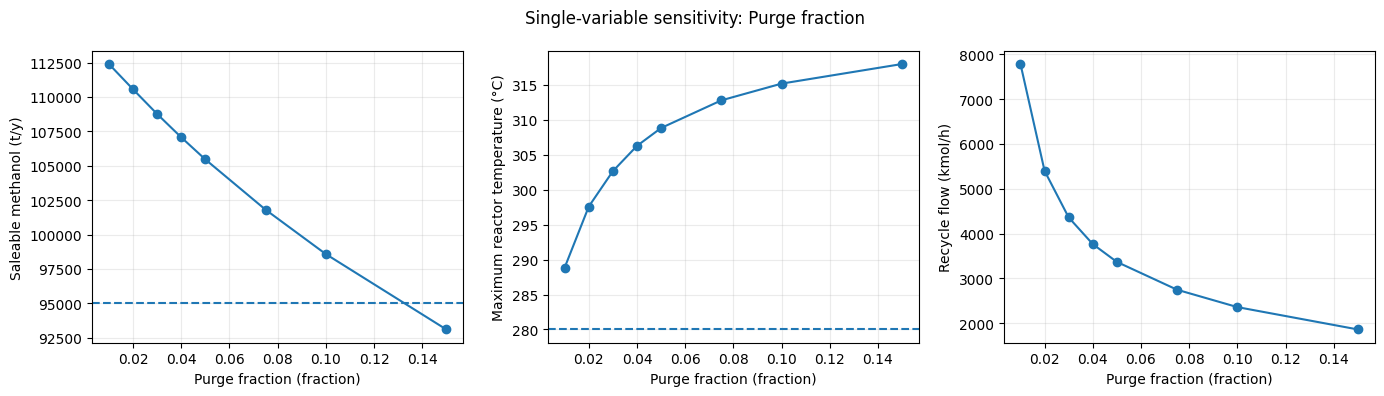

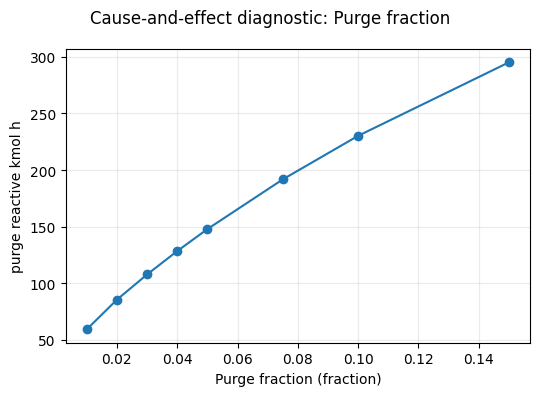

In [92]:
purge_sensitivity = run_ch3_sensitivity("purge")

### 3.4.5 Number of reactor tubes

Evaluates the effect of tube count on production, hotspot, recycle, reactor pressure drop and catalyst inventory.

,x_value,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,deltaP_bar,catalyst_mass_t,screening_pass
0,1200,87165.851581,316.720882,2252.218515,0.801700,12.666902,False
1,1620,93098.392311,317.981596,1858.471502,0.343227,17.100317,False
2,2000,96384.214971,318.463743,1640.372285,0.193900,21.111503,False
3,2400,98699.056313,318.574842,1486.680086,0.120566,25.333803,False
4,2800,100320.448534,318.667877,1379.023840,0.081835,29.556104,False


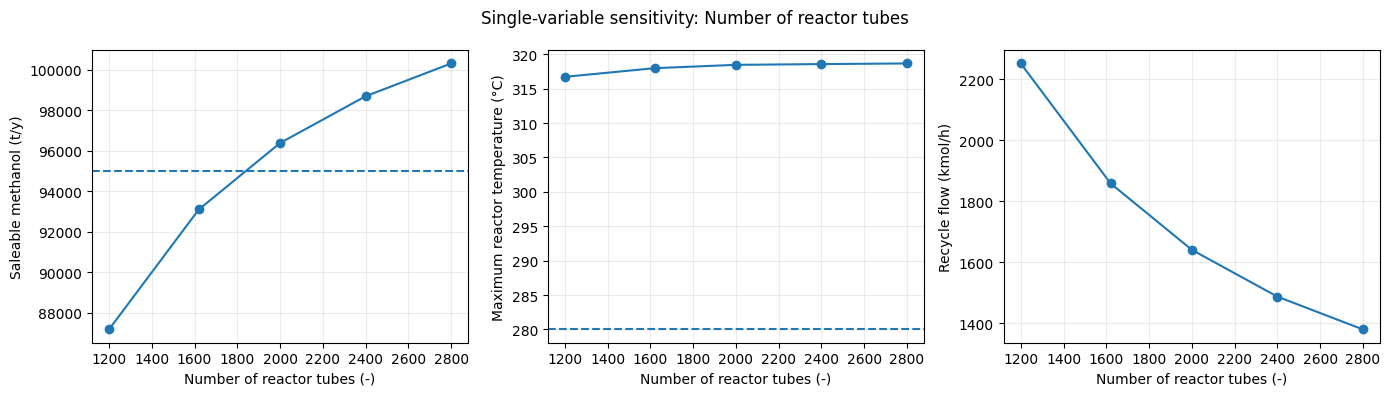

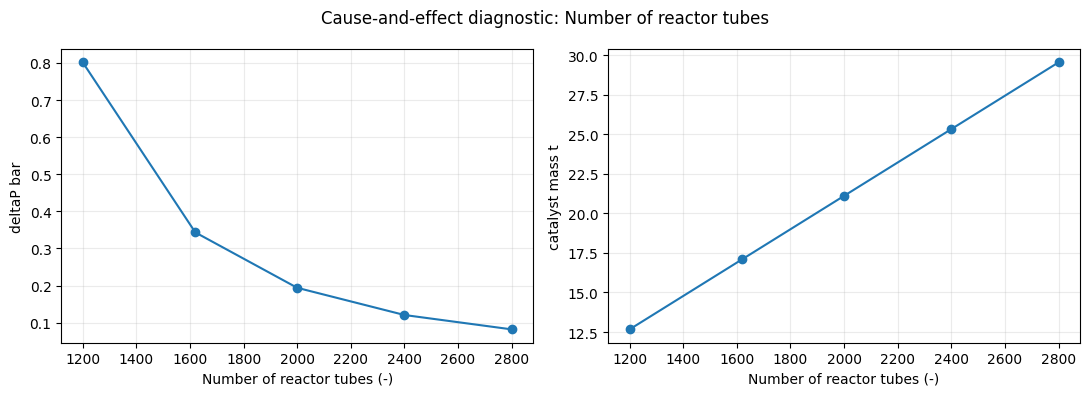

In [93]:
tube_number_sensitivity = run_ch3_sensitivity("tube_number")

### 3.4.6 Catalyst-bed length

Evaluates the effect of bed length on production, hotspot, recycle, reactor pressure drop and catalyst inventory.

,x_value,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,deltaP_bar,catalyst_mass_t,screening_pass
0,5.0,84861.020062,317.226322,2405.223115,0.347275,12.214512,False
1,6.0,89517.829892,317.824682,2096.088802,0.345186,14.657415,False
2,7.0,93098.392311,317.981596,1858.471502,0.343227,17.100317,False
3,8.0,95871.442180,317.923491,1674.427024,0.342768,19.543220,False
4,9.0,98034.878832,317.617892,1530.802960,0.344245,21.986122,False
5,10.0,99736.355009,317.410392,1417.833522,0.347671,24.429024,False


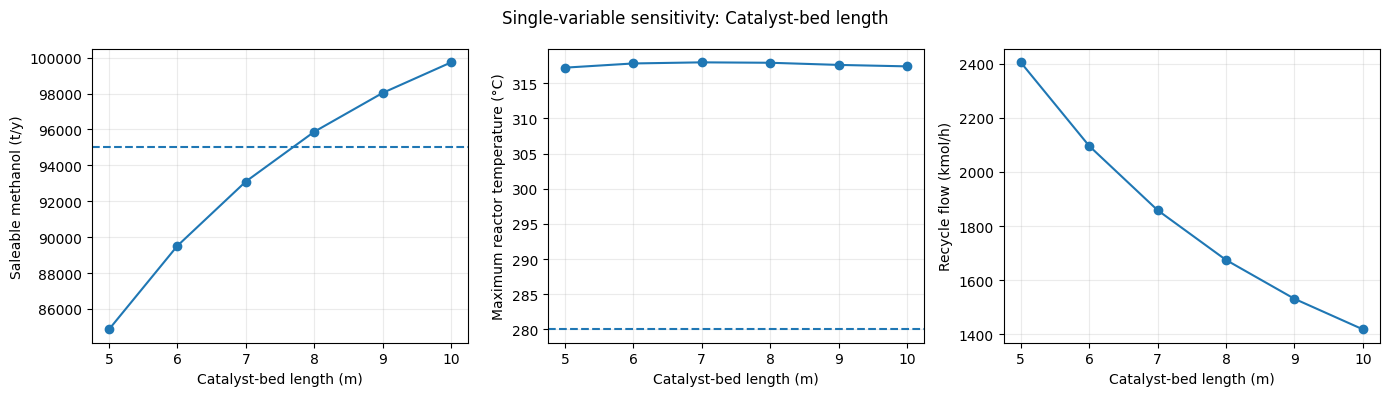

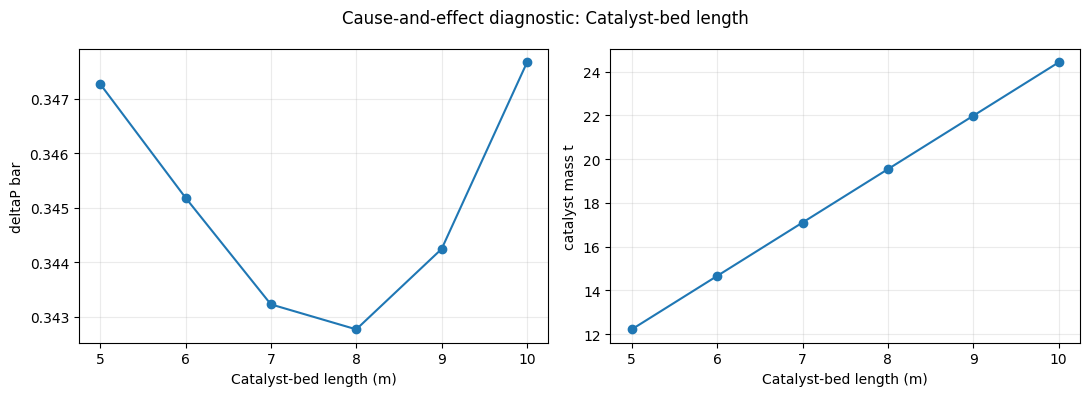

In [94]:
bed_length_sensitivity = run_ch3_sensitivity("bed_length")

### 3.4.7 Tube internal diameter

Evaluates the discrete tube-diameter choices using production, hotspot, recycle, reactor pressure drop and mean calculated heat-transfer coefficient.

,x_value,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,deltaP_bar,U_mean_W_m2K,screening_pass
0,35.0,90940.912728,315.338154,2001.676103,0.639127,110.601392,False
1,40.0,93098.392311,317.981596,1858.471502,0.343227,102.141348,False
2,45.0,94444.761774,319.702117,1769.114972,0.203615,94.060310,False
3,50.0,95301.880430,321.217057,1712.202750,0.130023,86.589603,False


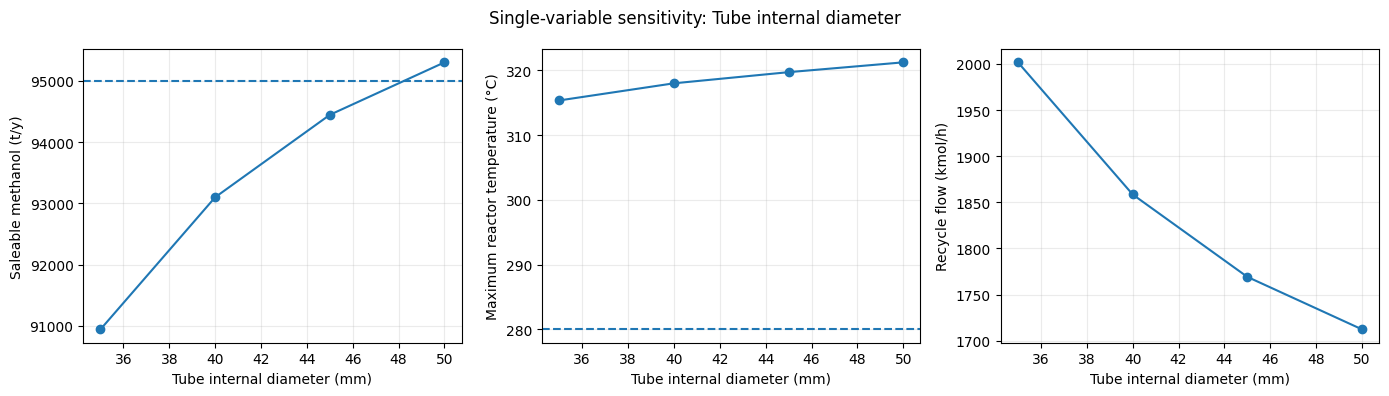

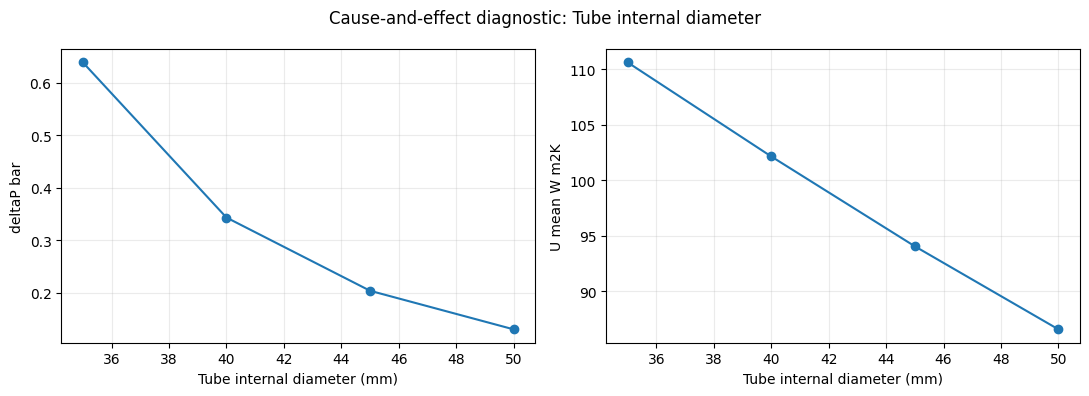

In [95]:
tube_id_sensitivity = run_ch3_sensitivity("tube_id")

## 3.5 Coupled-variable sensitivity analysis

Three coupled studies quantify the strongest interactions identified by the single-variable analysis: inlet temperature with S-604 pressure, reactor pressure with purge fraction, and reactor pressure with catalyst-bed length. The 3D surfaces interpolate only between calculated cases; the plotted markers and result tables contain the detailed-model values used for engineering decisions.

### 3.5.1 R-601 inlet temperature × S-604 pressure

Quantifies the thermal interaction between reaction-zone severity and boiling-water temperature while retaining the H-604 temperature-approach requirement.

In [96]:

# Interaction 1: inlet temperature × S-604 pressure
CH3_TEMPERATURE_VALUES_C = [190.0, 200.0, 210.0, 220.0]
CH3_STEAM_PRESSURE_VALUES_BAR = [16.0, 20.0, 24.0, 28.0]

temp_steam_rows = []
for T_in in CH3_TEMPERATURE_VALUES_C:
    for P_steam in CH3_STEAM_PRESSURE_VALUES_BAR:
        result = evaluate_ch3_design(T_in_C=T_in, steam_pressure_bar=P_steam)
        result["T_in_C"] = T_in
        result["steam_pressure_bar"] = P_steam
        temp_steam_rows.append(result)

temp_steam_interaction = pd.DataFrame(temp_steam_rows)

TEMP_STEAM_COLUMNS = [
    "T_in_C", "steam_pressure_bar", "saleable_meoh_t_y", "Tmax_C",
    "recycle_kmol_h", "H604_hot_end_approach_C",
    "production_pass", "hotspot_pass", "H604_screening_pass", "screening_pass",
]
TEMP_STEAM_COLUMNS = [c for c in TEMP_STEAM_COLUMNS if c in temp_steam_interaction.columns]
display(temp_steam_interaction[TEMP_STEAM_COLUMNS])


,T_in_C,steam_pressure_bar,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,H604_hot_end_approach_C,production_pass,hotspot_pass,H604_screening_pass,screening_pass
0,190.0,16.0,100869.613455,304.417800,1342.579057,11.378308,True,False,True,False
1,190.0,20.0,98146.323767,307.100914,1523.427744,22.384535,True,False,True,False
2,190.0,24.0,95451.625218,309.273176,1702.322388,31.795497,True,False,True,False
3,190.0,28.0,92818.804121,311.135665,1877.092330,40.062555,False,False,True,False
4,200.0,16.0,101664.721888,305.507652,1289.766890,1.378308,True,False,True,False
5,200.0,20.0,98815.886382,307.936492,1478.962611,12.384535,True,False,True,False
6,200.0,24.0,96063.480497,309.947605,1661.703021,21.795497,True,False,True,False
7,200.0,28.0,93410.696985,311.751634,1837.792919,30.062555,False,False,True,False
8,210.0,16.0,101861.925109,307.854546,1276.664110,-8.621692,True,False,True,False
9,210.0,20.0,99103.517357,309.919359,1459.877519,2.384535,True,False,True,False


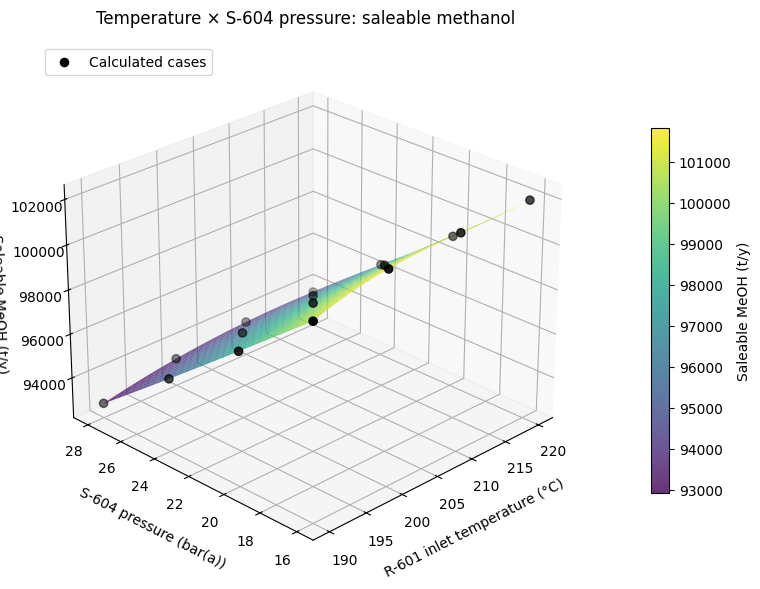

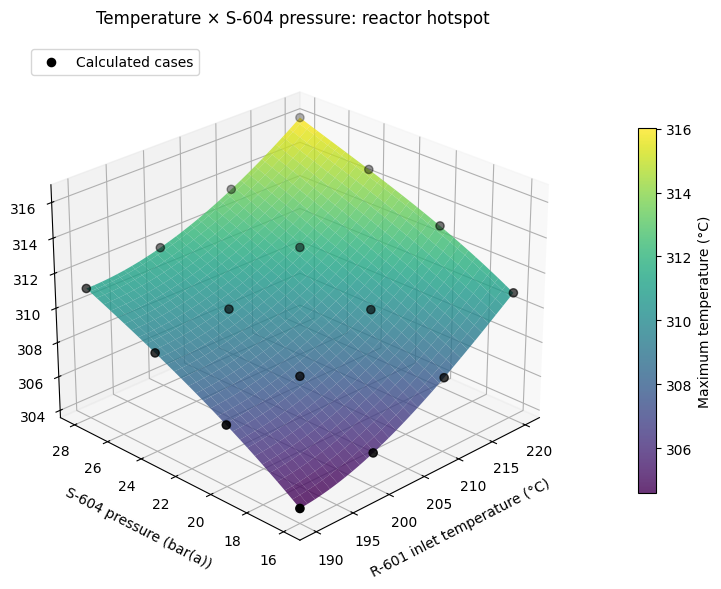

In [97]:
# 3D interaction surfaces
# The smooth surface is only for visual interpretation.
# Black points are the actual detailed-model calculations.
from scipy.interpolate import RectBivariateSpline


def plot_interaction_surface(table, x, y, value, x_label, y_label, z_label, title, y_scale=1.0):
    clean = table.dropna(subset=[x, y, value]).copy()
    clean["_y_plot"] = y_scale * clean[y]

    x_values = np.sort(clean[x].unique())
    y_values = np.sort(clean["_y_plot"].unique())

    # Put the calculated grid into matrix form.
    grid = (
        clean.pivot(index=x, columns="_y_plot", values=value)
        .reindex(index=x_values, columns=y_values)
    )
    if grid.isna().any().any():
        raise ValueError("The interaction surface requires a complete rectangular grid.")

    # Smooth interpolation only between calculated points.
    kx = min(3, len(x_values) - 1)
    ky = min(3, len(y_values) - 1)
    spline = RectBivariateSpline(x_values, y_values, grid.to_numpy(), kx=kx, ky=ky, s=0)

    x_smooth = np.linspace(x_values.min(), x_values.max(), 60)
    y_smooth = np.linspace(y_values.min(), y_values.max(), 60)
    z_smooth = spline(x_smooth, y_smooth)

    # Prevent interpolation overshoot outside the calculated result range.
    z_smooth = np.clip(z_smooth, clean[value].min(), clean[value].max())
    X, Y = np.meshgrid(x_smooth, y_smooth, indexing="ij")

    fig = plt.figure(figsize=(8.0, 6.0))
    ax = fig.add_subplot(111, projection="3d")
    surface = ax.plot_surface(X, Y, z_smooth, cmap="viridis", alpha=0.80, linewidth=0)
    ax.scatter(clean[x], clean["_y_plot"], clean[value], color="black", s=35,
               label="Calculated cases")

    ax.set_xlabel(x_label, labelpad=8)
    ax.set_ylabel(y_label, labelpad=8)
    ax.set_zlabel(z_label, labelpad=8)
    ax.set_title(title, pad=14)
    ax.view_init(elev=26, azim=-135)
    ax.legend(loc="upper left")

    cbar = fig.colorbar(surface, ax=ax, shrink=0.68, pad=0.10)
    cbar.set_label(z_label)
    fig.tight_layout()
    plt.show()


plot_interaction_surface(
    temp_steam_interaction,
    "T_in_C", "steam_pressure_bar", "saleable_meoh_t_y",
    "R-601 inlet temperature (°C)", "S-604 pressure (bar(a))", "Saleable MeOH (t/y)",
    "Temperature × S-604 pressure: saleable methanol",
)

plot_interaction_surface(
    temp_steam_interaction,
    "T_in_C", "steam_pressure_bar", "Tmax_C",
    "R-601 inlet temperature (°C)", "S-604 pressure (bar(a))", "Maximum temperature (°C)",
    "Temperature × S-604 pressure: reactor hotspot",
)


In [98]:

# Automatically show the technically useful region.
# Cases satisfying all Chapter 3 screening requirements.
temp_steam_full_pass = temp_steam_interaction.loc[
    temp_steam_interaction.get("screening_pass", False) == True
].copy()

print("Temperature × S-604 pressure cases meeting all screening requirements:")
if len(temp_steam_full_pass):
    display(temp_steam_full_pass[TEMP_STEAM_COLUMNS].sort_values("Tmax_C"))
else:
    print("None in this small grid.")

# If the 280 °C limit is not reached, retain cases that meet production,
# H-604 feasibility and recycle convergence, then rank them by lowest hotspot.
temp_steam_candidates = temp_steam_interaction.loc[
    (temp_steam_interaction.get("production_pass", False) == True)
    & (temp_steam_interaction.get("H604_screening_pass", False) == True)
    & (temp_steam_interaction.get("recycle_converged", False) == True)
].copy()

print()
print("Best thermally feasible production candidates (lowest hotspot first):")
if len(temp_steam_candidates):
    display(temp_steam_candidates[TEMP_STEAM_COLUMNS].sort_values("Tmax_C").head(8))
else:
    print("No case in this grid simultaneously meets production and H-604 feasibility.")


Temperature × S-604 pressure cases meeting all screening requirements:
None in this small grid.

Best thermally feasible production candidates (lowest hotspot first):


,T_in_C,steam_pressure_bar,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,H604_hot_end_approach_C,production_pass,hotspot_pass,H604_screening_pass,screening_pass
0,190.0,16.0,100869.613455,304.417800,1342.579057,11.378308,True,False,True,False
4,200.0,16.0,101664.721888,305.507652,1289.766890,1.378308,True,False,True,False
1,190.0,20.0,98146.323767,307.100914,1523.427744,22.384535,True,False,True,False
8,210.0,16.0,101861.925109,307.854546,1276.664110,-8.621692,True,False,True,False
5,200.0,20.0,98815.886382,307.936492,1478.962611,12.384535,True,False,True,False
2,190.0,24.0,95451.625218,309.273176,1702.322388,31.795497,True,False,True,False
9,210.0,20.0,99103.517357,309.919359,1459.877519,2.384535,True,False,True,False
6,200.0,24.0,96063.480497,309.947605,1661.703021,21.795497,True,False,True,False


### 3.5.2 R-601 pressure × purge fraction

Quantifies the trade-off between synthesis pressure, reactant recovery, recycle circulation, inert accumulation and methanol production across the low-pressure/low-purge operating region.

In [99]:
# Interaction 2: R-601 pressure × purge fraction
# Grid selected to resolve the lower-pressure, low-purge design region
# while retaining practical runtime for the detailed reactor model.
CH3_REACTOR_PRESSURE_VALUES_BAR = [35.0, 40.0, 45.0, 50.0, 55.0]
CH3_PURGE_VALUES = [0.01, 0.02, 0.03, 0.05, 0.075, 0.10, 0.15]

pressure_purge_rows = []
for P_reactor in CH3_REACTOR_PRESSURE_VALUES_BAR:
    for purge in CH3_PURGE_VALUES:
        result = evaluate_ch3_design(
            P_in_bar=P_reactor,
            purge_fraction=purge,
            pressure_sensitive_separator=True,
            recycle_max_iter=150,
        )
        result["P_in_bar"] = P_reactor
        result["purge_fraction"] = purge
        pressure_purge_rows.append(result)

pressure_purge_interaction = pd.DataFrame(pressure_purge_rows)

# Positive margins mean that the requirement is satisfied.
pressure_purge_interaction["production_margin_t_y"] = (
    pressure_purge_interaction["saleable_meoh_t_y"]
    - CH3_LIMITS["minimum_saleable_meoh_t_y"]
)
pressure_purge_interaction["hotspot_margin_C"] = (
    CH3_LIMITS["maximum_hotspot_C"]
    - pressure_purge_interaction["Tmax_C"]
)

PRESSURE_PURGE_COLUMNS = [
    "P_in_bar", "purge_fraction", "saleable_meoh_t_y", "production_margin_t_y",
    "Tmax_C", "hotspot_margin_C", "recycle_kmol_h", "inert_mol_pct",
    "K601_power_MW", "deltaP_bar", "production_pass", "hotspot_pass",
    "screening_pass",
]
PRESSURE_PURGE_COLUMNS = [
    c for c in PRESSURE_PURGE_COLUMNS if c in pressure_purge_interaction.columns
]
display(pressure_purge_interaction[PRESSURE_PURGE_COLUMNS])


C:\Users\leric\AppData\Local\Temp\ipykernel_42348\2034255160.py:116: RuntimeWarning: invalid value encountered in scalar power
  Z2 = Z1*(1.0 + a*Pr**e/(b*Pr**f + (1.0+c*Pr**d)**(-1)))
C:\Users\leric\AppData\Local\Temp\ipykernel_42348\2034255160.py:116: RuntimeWarning: invalid value encountered in scalar power
  Z2 = Z1*(1.0 + a*Pr**e/(b*Pr**f + (1.0+c*Pr**d)**(-1)))


,P_in_bar,purge_fraction,saleable_meoh_t_y,production_margin_t_y,Tmax_C,hotspot_margin_C,recycle_kmol_h,inert_mol_pct,K601_power_MW,deltaP_bar,production_pass,hotspot_pass,screening_pass
0,35.0,0.010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,35.0,0.020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,35.0,0.030,92763.307390,-2236.692610,275.022924,4.977076,10571.874667,8.424633,0.274444,10.879582,False,True,False
3,35.0,0.050,89048.141439,-5951.858561,279.917058,0.082942,7092.681978,7.234471,0.274444,5.031406,False,True,False
4,35.0,0.075,83687.424007,-11312.575993,282.109793,-2.109793,5399.852626,6.105858,0.274444,3.158071,False,False,False
5,35.0,0.100,79198.519714,-15801.480286,283.757325,-3.757325,4423.037634,5.387540,0.274444,2.295336,False,False,False
6,35.0,0.150,72137.373979,-22862.626021,286.048423,-6.048423,3259.341050,4.522101,0.274444,1.457413,False,False,False
7,40.0,0.010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
8,40.0,0.020,102385.763073,7385.763073,278.488133,1.511867,10289.623299,12.082861,0.457470,8.361576,True,True,False
9,40.0,0.030,99539.870714,4539.870714,282.465683,-2.465683,7977.052651,10.421428,0.457470,5.228173,True,False,False


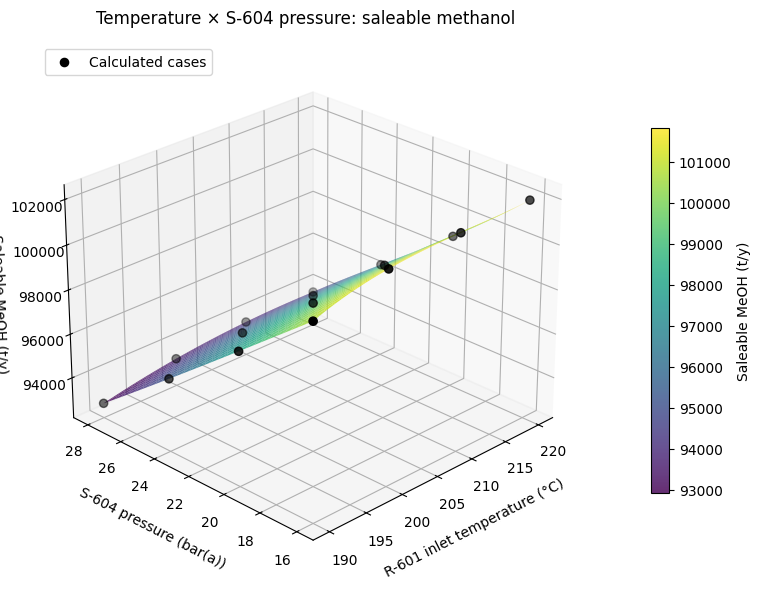

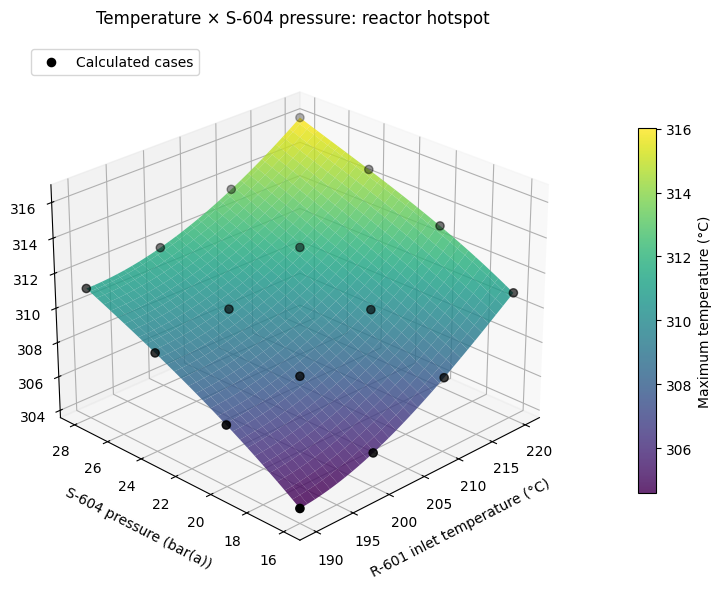

In [100]:
# 3D interaction surfaces
# Black markers are the actual detailed-model calculations.
# A rectangular spline is used when the full grid is available.
# Incomplete grids are plotted using triangulation between valid cases only.

from scipy.interpolate import RectBivariateSpline
import matplotlib.tri as mtri


def plot_interaction_surface(
    table,
    x,
    y,
    value,
    x_label,
    y_label,
    z_label,
    title,
    y_scale=1.0,
):
    # Retain only cases with valid calculated values.
    clean = table.dropna(subset=[x, y, value]).copy()
    clean["_y_plot"] = y_scale * clean[y]

    # Remove accidental duplicate coordinate pairs.
    clean = (
        clean.groupby([x, "_y_plot"], as_index=False)[value]
        .mean()
    )

    if len(clean) < 3:
        raise ValueError(
            f"Not enough valid cases to plot {title}. "
            "At least three calculated cases are required."
        )

    x_values = np.sort(clean[x].unique())
    y_values = np.sort(clean["_y_plot"].unique())

    # Check whether the calculated cases form a complete rectangular grid.
    grid = (
        clean.pivot(index=x, columns="_y_plot", values=value)
        .reindex(index=x_values, columns=y_values)
    )

    complete_grid = not grid.isna().any().any()

    fig = plt.figure(figsize=(8.0, 6.0))
    ax = fig.add_subplot(111, projection="3d")

    if complete_grid and len(x_values) >= 2 and len(y_values) >= 2:
        # Smooth interpolation within a complete calculated grid.
        kx = min(3, len(x_values) - 1)
        ky = min(3, len(y_values) - 1)

        spline = RectBivariateSpline(
            x_values,
            y_values,
            grid.to_numpy(),
            kx=kx,
            ky=ky,
            s=0,
        )

        x_smooth = np.linspace(x_values.min(), x_values.max(), 60)
        y_smooth = np.linspace(y_values.min(), y_values.max(), 60)

        z_smooth = spline(x_smooth, y_smooth)

        # Prevent interpolation overshoot beyond calculated results.
        z_smooth = np.clip(
            z_smooth,
            clean[value].min(),
            clean[value].max(),
        )

        X, Y = np.meshgrid(
            x_smooth,
            y_smooth,
            indexing="ij",
        )

        surface = ax.plot_surface(
            X,
            Y,
            z_smooth,
            cmap="viridis",
            alpha=0.82,
            linewidth=0,
            antialiased=True,
        )

    else:
        # Some detailed cases did not return valid results.
        # Triangulation allows the valid calculated cases to still be shown
        # without inventing replacement values for failed cases.
        triangulation = mtri.Triangulation(
            clean[x].to_numpy(dtype=float),
            clean["_y_plot"].to_numpy(dtype=float),
        )

        surface = ax.plot_trisurf(
            triangulation,
            clean[value].to_numpy(dtype=float),
            cmap="viridis",
            alpha=0.82,
            linewidth=0.20,
            antialiased=True,
        )

    # Show every valid detailed-model calculation.
    ax.scatter(
        clean[x],
        clean["_y_plot"],
        clean[value],
        color="black",
        s=35,
        label="Calculated cases",
    )

    ax.set_xlabel(x_label, labelpad=8)
    ax.set_ylabel(y_label, labelpad=8)
    ax.set_zlabel(z_label, labelpad=8)
    ax.set_title(title, pad=14)

    ax.view_init(elev=26, azim=-135)
    ax.legend(loc="upper left")

    cbar = fig.colorbar(
        surface,
        ax=ax,
        shrink=0.68,
        pad=0.10,
    )
    cbar.set_label(z_label)

    fig.tight_layout()
    plt.show()


# Temperature × S-604 pressure surfaces
plot_interaction_surface(
    temp_steam_interaction,
    "T_in_C",
    "steam_pressure_bar",
    "saleable_meoh_t_y",
    "R-601 inlet temperature (°C)",
    "S-604 pressure (bar(a))",
    "Saleable MeOH (t/y)",
    "Temperature × S-604 pressure: saleable methanol",
)

plot_interaction_surface(
    temp_steam_interaction,
    "T_in_C",
    "steam_pressure_bar",
    "Tmax_C",
    "R-601 inlet temperature (°C)",
    "S-604 pressure (bar(a))",
    "Maximum temperature (°C)",
    "Temperature × S-604 pressure: reactor hotspot",
)

In [101]:
# Automatically identify the useful pressure/purge region.
pressure_purge_full_pass = pressure_purge_interaction.loc[
    pressure_purge_interaction.get("screening_pass", False) == True
].copy()

print("Pressure × purge cases meeting all screening requirements:")
if len(pressure_purge_full_pass):
    display(
        pressure_purge_full_pass[PRESSURE_PURGE_COLUMNS]
        .sort_values(["K601_power_MW", "recycle_kmol_h"])
    )
else:
    print("None in the evaluated grid.")

# Production-feasible converged cases are also retained to show the
# temperature boundary and recycle penalty around the feasible region.
pressure_purge_candidates = pressure_purge_interaction.loc[
    (pressure_purge_interaction.get("production_pass", False) == True)
    & (pressure_purge_interaction.get("recycle_converged", False) == True)
].copy()

print()
print("Production-feasible candidates (lowest hotspot first):")
if len(pressure_purge_candidates):
    display(
        pressure_purge_candidates[PRESSURE_PURGE_COLUMNS]
        .sort_values(["Tmax_C", "recycle_kmol_h"])
        .head(12)
    )
else:
    print("No pressure/purge case in this grid meets the 95 000 t/y production basis.")


Pressure × purge cases meeting all screening requirements:
None in the evaluated grid.

Production-feasible candidates (lowest hotspot first):


,P_in_bar,purge_fraction,saleable_meoh_t_y,production_margin_t_y,Tmax_C,hotspot_margin_C,recycle_kmol_h,inert_mol_pct,K601_power_MW,deltaP_bar,production_pass,hotspot_pass,screening_pass
17,45.0,0.050,97489.271665,2489.271665,290.814933,-10.814933,5185.390923,9.110639,0.622986,2.221002,True,False,False
24,50.0,0.050,99904.075063,4904.075063,295.309813,-15.309813,4637.376872,9.837823,0.774332,1.657900,True,False,False
25,50.0,0.075,95046.735237,46.735237,298.445720,-18.445720,3739.551914,7.907136,0.774332,1.209969,True,False,False
31,55.0,0.050,101759.949440,6759.949440,299.252270,-19.252270,4214.799279,10.477142,0.913949,1.290382,True,False,False
32,55.0,0.075,97240.855026,2240.855026,302.589983,-22.589983,3417.435405,8.381416,0.913949,0.959253,True,False,False


### 3.5.3 R-601 pressure × catalyst-bed length

Quantifies the trade-off between synthesis pressure and reactor capacity by testing whether additional catalyst-bed length can compensate for lower single-pass conversion.

In [102]:
# Interaction 3: R-601 pressure × catalyst-bed length
CH3_PRESSURE_BED_VALUES_BAR = [35.0, 45.0, 55.0]
CH3_BED_LENGTH_VALUES_M = [7.0, 8.5, 10.0]

pressure_bed_rows = []
for P_reactor in CH3_PRESSURE_BED_VALUES_BAR:
    for bed_length in CH3_BED_LENGTH_VALUES_M:
        result = evaluate_ch3_design(
            P_in_bar=P_reactor,
            bed_length_m=bed_length,
            pressure_sensitive_separator=True,
        )
        result["P_in_bar"] = P_reactor
        result["bed_length_m"] = bed_length
        pressure_bed_rows.append(result)

pressure_bed_interaction = pd.DataFrame(pressure_bed_rows)

PRESSURE_BED_COLUMNS = [
    "P_in_bar", "bed_length_m", "saleable_meoh_t_y", "Tmax_C",
    "recycle_kmol_h", "K601_power_MW", "deltaP_bar", "catalyst_mass_t",
    "production_pass", "hotspot_pass", "screening_pass",
]
PRESSURE_BED_COLUMNS = [c for c in PRESSURE_BED_COLUMNS if c in pressure_bed_interaction.columns]
display(pressure_bed_interaction[PRESSURE_BED_COLUMNS])

,P_in_bar,bed_length_m,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,K601_power_MW,deltaP_bar,catalyst_mass_t,production_pass,hotspot_pass,screening_pass
0,35.0,7.0,72139.807115,286.049355,3259.179184,0.274444,1.457303,17.100317,False,False,False
1,35.0,8.5,76992.623260,287.052614,2934.560529,0.274444,1.514174,20.764671,False,False,False
2,35.0,10.0,80717.522311,287.501568,2685.398670,0.274444,1.564713,24.429024,False,False,False
3,45.0,7.0,81087.237477,297.713814,2662.288923,0.622986,0.848639,17.100317,False,False,False
4,45.0,8.5,85746.170790,298.195939,2351.609440,0.622986,0.864043,20.764671,False,False,False
5,45.0,10.0,89214.388676,298.320096,2120.435366,0.622986,0.880560,24.429024,False,False,False
6,55.0,7.0,87054.871866,306.910674,2263.443296,0.913949,0.559116,17.100317,False,False,False
7,55.0,8.5,91422.462939,307.065760,1972.845878,0.913949,0.563175,20.764671,False,False,False
8,55.0,10.0,94571.604065,306.972396,1763.354275,0.913949,0.571015,24.429024,False,False,False


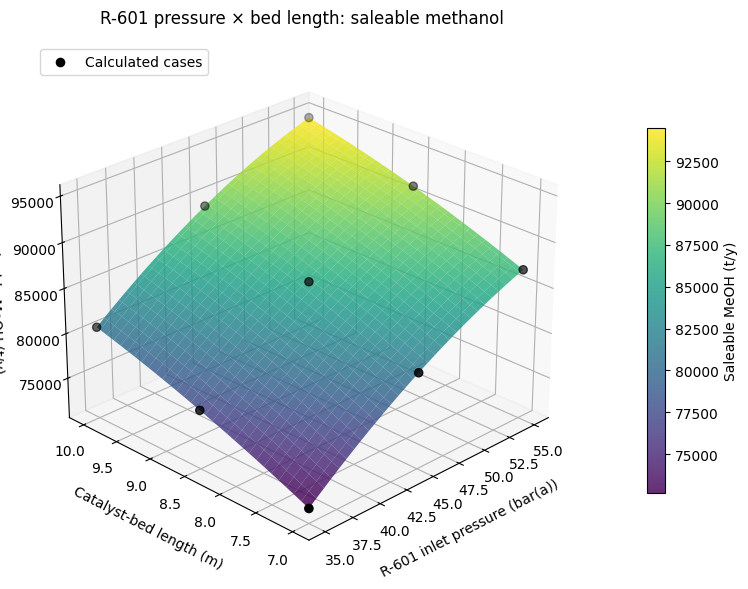

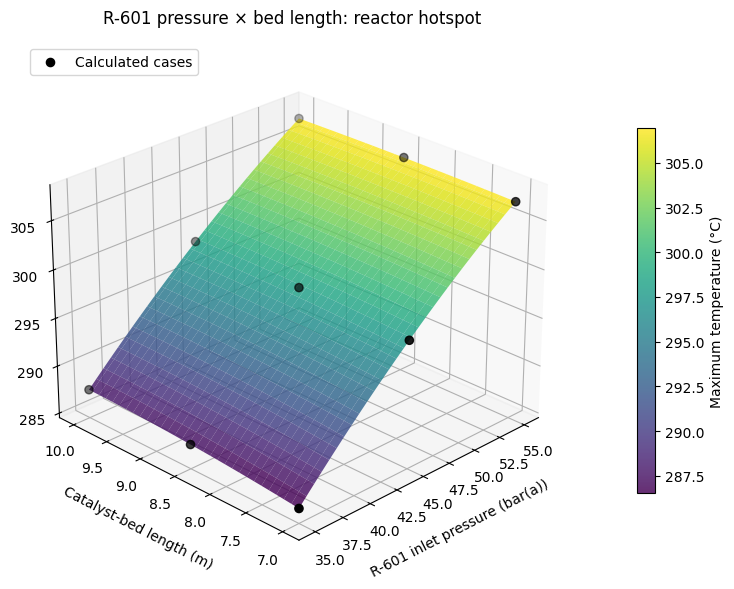

In [103]:
# 3D surfaces for R-601 pressure × catalyst-bed length.
plot_interaction_surface(
    pressure_bed_interaction,
    "P_in_bar", "bed_length_m", "saleable_meoh_t_y",
    "R-601 inlet pressure (bar(a))", "Catalyst-bed length (m)", "Saleable MeOH (t/y)",
    "R-601 pressure × bed length: saleable methanol",
)

plot_interaction_surface(
    pressure_bed_interaction,
    "P_in_bar", "bed_length_m", "Tmax_C",
    "R-601 inlet pressure (bar(a))", "Catalyst-bed length (m)", "Maximum temperature (°C)",
    "R-601 pressure × bed length: reactor hotspot",
)


In [104]:
# Identify whether extra bed length can make a lower-pressure case viable.
pressure_bed_full_pass = pressure_bed_interaction.loc[
    pressure_bed_interaction.get("screening_pass", False) == True
].copy()

print("Pressure × bed-length cases meeting all screening requirements:")
if len(pressure_bed_full_pass):
    display(
        pressure_bed_full_pass[PRESSURE_BED_COLUMNS]
        .sort_values(["P_in_bar", "catalyst_mass_t"])
    )
else:
    print("None in this small grid.")

# Even if the hotspot target is not reached, show the lowest-pressure designs
# that meet production so the reactor-size/compression trade-off is visible.
pressure_bed_candidates = pressure_bed_interaction.loc[
    (pressure_bed_interaction.get("production_pass", False) == True)
    & (pressure_bed_interaction.get("recycle_converged", False) == True)
].copy()

print()
print("Production-feasible pressure/bed-length candidates:")
if len(pressure_bed_candidates):
    display(
        pressure_bed_candidates[PRESSURE_BED_COLUMNS]
        .sort_values(["P_in_bar", "bed_length_m"])
    )
else:
    print("No pressure/bed-length case in this grid meets the 95 000 t/y production basis.")

Pressure × bed-length cases meeting all screening requirements:
None in this small grid.

Production-feasible pressure/bed-length candidates:
No pressure/bed-length case in this grid meets the 95 000 t/y production basis.


## 3.6 Interaction results and design-space definition

The coupled studies define the technically useful design region and show the principal trade-offs carried into the economic analysis: fresh-gas compression, recycle severity, thermal feasibility and reactor/catalyst size.

In [105]:
CH3_VARIABLE_ROLES = pd.DataFrame({
    "Variable": [
        "R-601 inlet pressure",
        "Purge fraction",
        "Catalyst-bed length",
        "R-601 inlet temperature",
        "S-604 pressure",
        "Tube number",
        "Tube ID",
    ],
    "Role in design evaluation": [
        "Economic and process variable",
        "Economic and process variable",
        "Reactor sizing variable",
        "Thermal operating variable",
        "Thermal operating variable",
        "Reactor sizing variable",
        "Discrete geometry variable",
    ],
    "Engineering significance": [
        "Conversion and hotspot behaviour versus upstream fresh-gas compression cost",
        "Reactant recovery versus recycle-compression and inert-circulation penalty",
        "Reactor and catalyst cost versus conversion and recycle severity",
        "Reaction-zone temperature and H-604 thermal approach",
        "Boiling-water temperature, hotspot control and H-604 thermal approach",
        "Catalyst inventory, flow area, heat-transfer area and reactor cost",
        "Hydraulics and heat-transfer trade-off across the discrete tube choices",
    ],
})
display(CH3_VARIABLE_ROLES)


,Variable,Role in design evaluation,Engineering significance
0,R-601 inlet pressure,Economic and process variable,Conversion and hotspot behaviour versus upstre...
1,Purge fraction,Economic and process variable,Reactant recovery versus recycle-compression a...
2,Catalyst-bed length,Reactor sizing variable,Reactor and catalyst cost versus conversion an...
3,R-601 inlet temperature,Thermal operating variable,Reaction-zone temperature and H-604 thermal ap...
4,S-604 pressure,Thermal operating variable,"Boiling-water temperature, hotspot control and..."
5,Tube number,Reactor sizing variable,"Catalyst inventory, flow area, heat-transfer a..."
6,Tube ID,Discrete geometry variable,Hydraulics and heat-transfer trade-off across ...


### 3.6.1 Low-pressure/low-purge convergence check

Re-evaluates representative low-pressure/low-purge cases with an increased recycle-iteration allowance so that only numerically converged designs enter the economic comparison.

In [106]:
# Confirm recycle convergence for representative low-pressure/low-purge cases.
PRESSURE_PURGE_VALIDATION_CASES = [
    (50.0, 0.075),  # near the 95 kt/y production requirement
    (50.0, 0.050),
    (55.0, 0.050),
    (60.0, 0.030),
    (65.0, 0.020),
]

validated_rows = []
for P_reactor, purge in PRESSURE_PURGE_VALIDATION_CASES:
    result = evaluate_ch3_design(
        P_in_bar=P_reactor,
        purge_fraction=purge,
        pressure_sensitive_separator=True,
        recycle_max_iter=120,
    )
    validated_rows.append(result)

pressure_purge_validated = pd.DataFrame(validated_rows)

VALIDATION_COLUMNS = [
    "P_in_bar", "purge_fraction", "saleable_meoh_t_y", "Tmax_C",
    "recycle_kmol_h", "inert_mol_pct", "deltaP_bar",
    "recycle_iterations", "recycle_component_error", "recycle_total_error",
    "production_pass", "hotspot_pass", "recycle_converged",
]
VALIDATION_COLUMNS = [
    c for c in VALIDATION_COLUMNS if c in pressure_purge_validated.columns
]
display(pressure_purge_validated[VALIDATION_COLUMNS])


,P_in_bar,purge_fraction,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,inert_mol_pct,deltaP_bar,recycle_iterations,recycle_component_error,recycle_total_error,production_pass,hotspot_pass,recycle_converged
0,50.0,0.075,95046.878861,298.446020,3739.505874,7.907174,1.209945,63,0.000009,0.000006,True,False,True
1,50.0,0.050,99905.188568,295.313285,4636.956842,9.837693,1.657663,78,0.000010,0.000008,True,False,True
2,55.0,0.050,101761.233352,299.254884,4214.398638,10.476951,1.290194,72,0.000010,0.000008,True,False,True
3,60.0,0.030,107131.461707,297.314257,5007.772587,14.243622,1.495803,120,0.000075,0.000031,True,False,False
4,65.0,0.020,109984.434540,295.490761,5730.497073,17.417613,1.656327,120,0.000334,0.000176,True,False,False


## 3.7 Total annualised cost (TAC) model

Defines the subsystem TAC used to compare feasible R-601 alternatives. The economic boundary includes the equipment and utilities that change with the selected synthesis pressure, recycle rate, thermal conditions and reactor geometry.

### 3.7.1 Economic basis and assumptions

Economic calculations use a June 2026 cost basis with CEPCI = 870.2. Capital is annualised over 20 years at a 5% discount rate. Compressor electricity uses the selected 2026/27 Eskom industrial basis, cooling-water cost uses a recent methanol techno-economic reference, and catalyst replacement uses the selected Cu/ZnO/Al₂O₃ reference price. H-604 uses recovered S-604 steam, so no purchased-steam charge is added to the subsystem TAC.

In [107]:
# TAC economic assumptions
TAC_ECON = {
    "CEPCI_2026": 870.2,
    "CEPCI_2010": 532.9,
    "CEPCI_2012": 584.6,

    "USD_ZAR": 16.6803,
    "EUR_USD": 1.12587,

    "operating_h_y": 8000.0,
    "discount_rate": 0.05,
    "project_life_y": 20,

    "electricity_ZAR_kWh": 2.01,
    "cooling_water_USD_GJ": 0.378,
    "catalyst_EUR_kg": 18.10,
    "catalyst_life_y": 4.0,

    "direct_installation_factor": 3.20,
}

TAC_ECON["electricity_USD_kWh"] = (
    TAC_ECON["electricity_ZAR_kWh"] / TAC_ECON["USD_ZAR"]
)
TAC_ECON["catalyst_USD_kg"] = (
    TAC_ECON["catalyst_EUR_kg"] * TAC_ECON["EUR_USD"]
)


def capital_recovery_factor(rate, life_y):
    rate = float(rate)
    life_y = int(life_y)
    return rate*(1.0+rate)**life_y / ((1.0+rate)**life_y - 1.0)


TAC_ECON["CRF"] = capital_recovery_factor(
    TAC_ECON["discount_rate"], TAC_ECON["project_life_y"]
)

TAC_ECON_TABLE = pd.DataFrame({
    "Assumption": [
        "Cost basis CEPCI",
        "Electricity",
        "Cooling water",
        "Catalyst price",
        "Catalyst replacement interval",
        "Discount rate",
        "Project life",
        "Capital recovery factor",
        "Direct installation factor",
    ],
    "Value": [
        TAC_ECON["CEPCI_2026"],
        TAC_ECON["electricity_USD_kWh"],
        TAC_ECON["cooling_water_USD_GJ"],
        TAC_ECON["catalyst_USD_kg"],
        TAC_ECON["catalyst_life_y"],
        TAC_ECON["discount_rate"],
        TAC_ECON["project_life_y"],
        TAC_ECON["CRF"],
        TAC_ECON["direct_installation_factor"],
    ],
    "Unit": [
        "-", "USD/kWh", "USD/GJ", "USD/kg", "y",
        "fraction", "y", "1/y", "-",
    ],
})
display(TAC_ECON_TABLE)

,Assumption,Value,Unit
0,Cost basis CEPCI,870.200000,-
1,Electricity,0.120501,USD/kWh
2,Cooling water,0.378000,USD/GJ
3,Catalyst price,20.378247,USD/kg
4,Catalyst replacement interval,4.000000,y
5,Discount rate,0.050000,fraction
6,Project life,20.000000,y
7,Capital recovery factor,0.080243,1/y
8,Direct installation factor,3.200000,-


### 3.7.2 Equipment and operating-cost functions

Purchased-equipment costs are calculated for R-601, K-601, K-602, H-602A/B, H-603, H-604, H-605, H-606 and S-604. Heat-exchanger duties are rerated from the established Task 1/Chapter 2 basis using the selected compressor duty or synthesis-loop throughput. H-603 remains an internal heat-recovery exchanger, while cooling-water cost is applied to the compressor coolers and final product-cooling train. Items that remain essentially constant across the optimisation, including H-601, S-601/S-602/S-603, T-601 and S-605, are outside the differential TAC because adding the same cost to every design would not change the optimum.


In [108]:
# Subsystem TAC costing functions

def reactor_size_from_case(case):
    D = float(case.get("tube_id_mm", CH3_BASE["tube_id_m"]*1000.0))/1000.0
    Nt = int(case.get("n_tubes", CH3_BASE["n_tubes"]))
    L = float(case.get("bed_length_m", CH3_BASE["bed_length_m"]))

    area_m2 = Nt*math.pi*D*L
    bed_volume_m3 = Nt*math.pi*D**2*L/4.0
    return area_m2, bed_volume_m3


def reactor_purchased_cost_2026_USD(case):
    area_m2, volume_m3 = reactor_size_from_case(case)

    # Reactor purchased-cost correlation: 2012 EUR, CEPCI = 584.6.
    cost_2012_EUR = 2860.0*area_m2**0.69 + 28940.0*volume_m3
    cost_2026_EUR = cost_2012_EUR*(TAC_ECON["CEPCI_2026"]/TAC_ECON["CEPCI_2012"])
    return cost_2026_EUR*TAC_ECON["EUR_USD"]


def centrifugal_compressor_purchased_cost_2026_USD(power_kW):
    # Towler and Sinnott centrifugal-compressor correlation, January-2010 basis.
    power_kW = max(float(power_kW), 1.0)
    cost_2010_USD = 580000.0 + 20000.0*power_kW**0.60
    return cost_2010_USD*(TAC_ECON["CEPCI_2026"]/TAC_ECON["CEPCI_2010"])


def shell_tube_purchased_cost_2026_USD(area_m2):
    # Towler and Sinnott shell-and-tube correlation, January-2010 basis.
    # The published correlation is used over its stated 10-1000 m² range.
    A = float(np.clip(area_m2, 10.0, 1000.0))
    cost_2010_USD = 28000.0 + 54.0*A**1.20
    return cost_2010_USD*(TAC_ECON["CEPCI_2026"]/TAC_ECON["CEPCI_2010"])


def pressure_vessel_purchased_cost_2026_USD(shell_mass_kg):
    # Towler and Sinnott carbon-steel pressure-vessel correlation, January-2010 basis.
    W = float(np.clip(shell_mass_kg, 160.0, 250000.0))
    cost_2010_USD = 11600.0 + 34.0*W**0.85
    return cost_2010_USD*(TAC_ECON["CEPCI_2026"]/TAC_ECON["CEPCI_2010"])


def annualised_installed_cost_USD_y(purchased_cost_USD):
    return (
        float(purchased_cost_USD)
        * TAC_ECON["direct_installation_factor"]
        * TAC_ECON["CRF"]
    )


def cooling_water_cost_USD_y(duty_MW):
    energy_GJ_y = max(float(duty_MW), 0.0)*TAC_ECON["operating_h_y"]*3.6
    return energy_GJ_y*TAC_ECON["cooling_water_USD_GJ"]


def countercurrent_lmtd(deltaT1_C, deltaT2_C):
    d1 = float(deltaT1_C)
    d2 = float(deltaT2_C)
    if d1 <= 0.0 or d2 <= 0.0:
        return np.nan
    if abs(d1-d2) < 1.0e-12:
        return d1
    return float((d1-d2)/math.log(d1/d2))


# Aspen Task 1 base: K-601A = 656.7 kW and K-601B = 662.6 kW.
# The pressure model is calibrated once to the established 70 bar compressor duty.
K601_ASPEN_BASE_MW = (656.7 + 662.6)/1000.0
K601_MODEL_BASE_MW = estimate_K601_power_MW(CH3_BASE["P_in_bar"])
K601_POWER_FACTOR = K601_ASPEN_BASE_MW / K601_MODEL_BASE_MW


def upstream_K601_cost(case):
    power_MW = float(case["K601_power_MW"]) * K601_POWER_FACTOR
    total_kW = 1000.0*power_MW

    purchased_USD = 2.0*centrifugal_compressor_purchased_cost_2026_USD(total_kW/2.0)
    annualised_capital_USD_y = annualised_installed_cost_USD_y(purchased_USD)
    electricity_USD_y = (
        total_kW
        * TAC_ECON["operating_h_y"]
        * TAC_ECON["electricity_USD_kWh"]
    )

    return {
        "K601_power_MW": power_MW,
        "K601_PEC_USD": purchased_USD,
        "K601_annualised_capital_USD_y": annualised_capital_USD_y,
        "K601_electricity_USD_y": electricity_USD_y,
        "K601_total_annual_cost_USD_y": annualised_capital_USD_y + electricity_USD_y,
    }


# Established PFD-601 heat-exchanger bases.
BASE_LOOP_FEED_KMOL_H = float((
    np.array([FRESH_FEED_KMOL_H[s] for s in SPECIES], dtype=float)/3.6
    + CH3_BASE["recycle_mol_s"]
).sum()*3.6)

HX_BASIS = {
    "H602A_duty_MW": 0.67205,
    "H602B_duty_MW": 0.66547,
    "H603_duty_MW": 4.41630,
    "H603_area_m2": 269.3,
    "H604_duty_MW": 0.42639,
    "H604_U_W_m2K": 956.0,
    "H605_duty_MW": 3.37411,
    "H606_duty_MW": 1.58149,
    "cooling_water_in_C": 25.0,
    "cooling_water_out_C": 35.0,
    "gas_cooler_U_W_m2K": 300.0,
    "condenser_U_W_m2K": 600.0,
    "H603_cold_in_C": 42.86,
    "H603_cold_out_base_C": 210.0,
}

# Base areas for the cooling exchangers are calculated once from their
# established Task 1 duties and temperature programs.
_H602_lmtd = countercurrent_lmtd(95.45-35.0, 40.0-25.0)
HX_BASIS["H602A_area_m2"] = HX_BASIS["H602A_duty_MW"]*1.0e6/(HX_BASIS["gas_cooler_U_W_m2K"]*_H602_lmtd)
HX_BASIS["H602B_area_m2"] = HX_BASIS["H602B_duty_MW"]*1.0e6/(HX_BASIS["gas_cooler_U_W_m2K"]*_H602_lmtd)

_H605_lmtd = countercurrent_lmtd(121.17-35.0, 75.0-25.0)
HX_BASIS["H605_area_m2"] = HX_BASIS["H605_duty_MW"]*1.0e6/(HX_BASIS["gas_cooler_U_W_m2K"]*_H605_lmtd)

_H606_lmtd = countercurrent_lmtd(75.0-35.0, 38.0-25.0)
HX_BASIS["H606_area_m2"] = HX_BASIS["H606_duty_MW"]*1.0e6/(HX_BASIS["condenser_U_W_m2K"]*_H606_lmtd)


def rerate_heat_exchangers(case, K601_power_MW):
    feed_ratio = float(case.get("reactor_feed_kmol_h", BASE_LOOP_FEED_KMOL_H))/BASE_LOOP_FEED_KMOL_H
    feed_ratio = max(feed_ratio, 0.05)

    # K-601 intercooler/aftercooler duties follow the calibrated compression load.
    k601_ratio = max(float(K601_power_MW)/K601_ASPEN_BASE_MW, 0.0)
    H602A_duty = HX_BASIS["H602A_duty_MW"]*k601_ratio
    H602B_duty = HX_BASIS["H602B_duty_MW"]*k601_ratio
    H602A_area = max(10.0, HX_BASIS["H602A_area_m2"]*k601_ratio)
    H602B_area = max(10.0, HX_BASIS["H602B_area_m2"]*k601_ratio)

    # H-603 heats the mixed synthesis gas to the feed/effluent-exchanger target.
    T_in = float(case.get("T_in_C", CH3_BASE["T_in_C"]))
    H603_target_C = min(HX_BASIS["H603_cold_out_base_C"], T_in)
    base_span = HX_BASIS["H603_cold_out_base_C"] - HX_BASIS["H603_cold_in_C"]
    case_span = max(H603_target_C - HX_BASIS["H603_cold_in_C"], 0.0)
    H603_duty = HX_BASIS["H603_duty_MW"]*feed_ratio*case_span/base_span
    H603_area = max(10.0, HX_BASIS["H603_area_m2"]*H603_duty/HX_BASIS["H603_duty_MW"])

    # H-604 supplies only the trim above the H-603 target using recovered S-604 steam.
    trim_span = max(T_in - H603_target_C, 0.0)
    H604_duty = HX_BASIS["H604_duty_MW"]*feed_ratio*trim_span/15.0
    steam_T_C = water_saturation_temperature_C(float(case.get("steam_pressure_bar", CH3_BASE["steam_drum_pressure_bar_abs"])))
    if H604_duty > 1.0e-12:
        dT_cold = steam_T_C - H603_target_C
        dT_hot = steam_T_C - T_in
        H604_lmtd = countercurrent_lmtd(dT_cold, dT_hot)
        if not np.isfinite(H604_lmtd):
            H604_area = np.inf
        else:
            H604_area = max(10.0, 1.10*H604_duty*1.0e6/(HX_BASIS["H604_U_W_m2K"]*H604_lmtd))
    else:
        H604_lmtd = np.nan
        H604_area = 10.0

    # H-605/H-606 are rerated with synthesis-loop throughput. Their Task 1
    # duties already include the post-H-603 sensible cooling and condensation.
    H605_duty = HX_BASIS["H605_duty_MW"]*feed_ratio
    H606_duty = HX_BASIS["H606_duty_MW"]*feed_ratio
    H605_area = max(10.0, HX_BASIS["H605_area_m2"]*feed_ratio)
    H606_area = max(10.0, HX_BASIS["H606_area_m2"]*feed_ratio)

    areas = {
        "H602A": H602A_area,
        "H602B": H602B_area,
        "H603": H603_area,
        "H604": H604_area,
        "H605": H605_area,
        "H606": H606_area,
    }
    duties = {
        "H602A": H602A_duty,
        "H602B": H602B_duty,
        "H603": H603_duty,
        "H604": H604_duty,
        "H605": H605_duty,
        "H606": H606_duty,
    }

    purchased = {
        tag: shell_tube_purchased_cost_2026_USD(area)
        for tag, area in areas.items()
    }

    cooling_duty_MW = H602A_duty + H602B_duty + H605_duty + H606_duty
    cooling_USD_y = cooling_water_cost_USD_y(cooling_duty_MW)

    return {
        "feed_throughput_ratio": feed_ratio,
        "H604_LMTD_C": H604_lmtd,
        "heat_exchanger_areas_m2": areas,
        "heat_exchanger_duties_MW": duties,
        "heat_exchanger_PEC_USD": purchased,
        "heat_exchanger_total_PEC_USD": float(sum(purchased.values())),
        "cooling_duty_MW": cooling_duty_MW,
        "cooling_water_USD_y": cooling_USD_y,
    }


def size_and_cost_S604(case):
    P_abs = float(case.get("steam_pressure_bar", CH3_BASE["steam_drum_pressure_bar_abs"]))
    Q_MW = max(float(case.get("reactor_heat_removed_MW", 8.682)), 0.01)
    st = saturated_steam_properties(P_abs)

    m_steam_kg_s = Q_MW*1000.0/st["hfg_kJ_kg"]
    steam_volume_m3_s = m_steam_kg_s/st["rho_g_kg_m3"]
    gauge_bar = max(P_abs-1.01325, 0.0)
    K = 0.107 if gauge_bar <= 7.0 else float(np.clip(0.107-0.003*((gauge_bar-7.0)/7.0), 0.065, 0.107))
    u_sb = K*math.sqrt((st["rho_f_kg_m3"]-st["rho_g_kg_m3"])/st["rho_g_kg_m3"])
    u_allow = 0.80*u_sb
    vapor_area_m2 = steam_volume_m3_s/max(u_allow, 1.0e-12)
    total_area_m2 = vapor_area_m2/0.50
    diameter_m = math.sqrt(4.0*total_area_m2/math.pi)
    length_m = max(3.0*diameter_m, 1.0)

    # Preliminary carbon-steel shell mass for the economic comparison only.
    P_gauge_Pa = gauge_bar*1.0e5
    allowable_stress_Pa = 120.0e6
    weld_efficiency = 0.85
    corrosion_allowance_m = 0.003
    denom = max(2.0*allowable_stress_Pa*weld_efficiency - 1.2*P_gauge_Pa, 1.0e6)
    wall_m = P_gauge_Pa*diameter_m/denom + corrosion_allowance_m
    steel_density_kg_m3 = 7850.0
    cylindrical_mass_kg = math.pi*diameter_m*length_m*wall_m*steel_density_kg_m3
    shell_and_heads_mass_kg = 1.25*cylindrical_mass_kg

    purchased_USD = pressure_vessel_purchased_cost_2026_USD(shell_and_heads_mass_kg)
    return {
        "S604_diameter_m": diameter_m,
        "S604_tangent_length_m": length_m,
        "S604_wall_screening_mm": 1000.0*wall_m,
        "S604_shell_mass_kg": shell_and_heads_mass_kg,
        "S604_PEC_USD": purchased_USD,
    }


def calculate_subsystem_TAC(case):
    """Return the annualised subsystem TAC for one converged design."""
    if "error" in case:
        return {"TAC_error": case["error"]}

    if case.get("recycle_converged", True) is False:
        return {
            "TAC_error": "Recycle loop not converged",
            "subsystem_TAC_MUSD_y": np.nan,
            "subsystem_TAC_USD_per_t_MeOH": np.nan,
        }

    # R-601 reactor.
    C_R601 = reactor_purchased_cost_2026_USD(case)
    R601_ann = annualised_installed_cost_USD_y(C_R601)

    # Fresh-syngas compression and associated coolers.
    K601 = upstream_K601_cost(case)

    # Recycle compression.
    K602_power_MW = float(case["K602_power_MW"])
    C_K602 = centrifugal_compressor_purchased_cost_2026_USD(1000.0*K602_power_MW)
    K602_ann = annualised_installed_cost_USD_y(C_K602)
    K602_electricity_USD_y = (
        K602_power_MW*1000.0
        * TAC_ECON["operating_h_y"]
        * TAC_ECON["electricity_USD_kWh"]
    )

    # Heat-exchanger capital and cooling-water utility.
    HX = rerate_heat_exchangers(case, K601["K601_power_MW"])
    HX_ann = annualised_installed_cost_USD_y(HX["heat_exchanger_total_PEC_USD"])

    # S-604 steam-drum capital.
    S604 = size_and_cost_S604(case)
    S604_ann = annualised_installed_cost_USD_y(S604["S604_PEC_USD"])

    # Catalyst replacement.
    catalyst_USD_y = (
        float(case["catalyst_mass_t"])*1000.0
        * TAC_ECON["catalyst_USD_kg"]
        / TAC_ECON["catalyst_life_y"]
    )

    compressor_electricity_USD_y = (
        K601["K601_electricity_USD_y"] + K602_electricity_USD_y
    )

    TAC_USD_y = (
        R601_ann
        + S604_ann
        + HX_ann
        + K601["K601_annualised_capital_USD_y"]
        + K602_ann
        + compressor_electricity_USD_y
        + HX["cooling_water_USD_y"]
        + catalyst_USD_y
    )
    meoh_t_y = float(case["saleable_meoh_t_y"])

    result = {
        "R601_PEC_MUSD": C_R601/1.0e6,
        "S604_PEC_MUSD": S604["S604_PEC_USD"]/1.0e6,
        "HX_PEC_MUSD": HX["heat_exchanger_total_PEC_USD"]/1.0e6,
        "K601_PEC_MUSD": K601["K601_PEC_USD"]/1.0e6,
        "K602_PEC_MUSD": C_K602/1.0e6,
        "K601_power_MW": K601["K601_power_MW"],
        "K602_power_MW": K602_power_MW,
        "cooling_duty_MW": HX["cooling_duty_MW"],
        "annualised_R601_MUSD_y": R601_ann/1.0e6,
        "annualised_S604_MUSD_y": S604_ann/1.0e6,
        "annualised_HX_MUSD_y": HX_ann/1.0e6,
        "annualised_K601_MUSD_y": K601["K601_annualised_capital_USD_y"]/1.0e6,
        "annualised_K602_MUSD_y": K602_ann/1.0e6,
        "compressor_electricity_MUSD_y": compressor_electricity_USD_y/1.0e6,
        "cooling_utility_MUSD_y": HX["cooling_water_USD_y"]/1.0e6,
        "catalyst_replacement_MUSD_y": catalyst_USD_y/1.0e6,
        "subsystem_TAC_MUSD_y": TAC_USD_y/1.0e6,
        "subsystem_TAC_USD_per_t_MeOH": TAC_USD_y/max(meoh_t_y, 1.0e-12),
        "H604_area_m2": HX["heat_exchanger_areas_m2"]["H604"],
        "H604_duty_MW": HX["heat_exchanger_duties_MW"]["H604"],
        "H603_area_m2": HX["heat_exchanger_areas_m2"]["H603"],
        "H605_duty_MW": HX["heat_exchanger_duties_MW"]["H605"],
        "H606_duty_MW": HX["heat_exchanger_duties_MW"]["H606"],
        "S604_diameter_m": S604["S604_diameter_m"],
        "S604_tangent_length_m": S604["S604_tangent_length_m"],
    }

    for tag, value in HX["heat_exchanger_areas_m2"].items():
        result[f"{tag}_area_m2"] = value
    for tag, value in HX["heat_exchanger_PEC_USD"].items():
        result[f"{tag}_PEC_MUSD"] = value/1.0e6

    return result


### 3.7.3 Base-case subsystem TAC

Applies the complete subsystem TAC model to the Chapter 2 base case and reports the annualised capital, energy, cooling-water and catalyst contributions.

In [109]:
# Base-case subsystem TAC
if "CH3_BASE_CHECK" not in globals() or "error" in CH3_BASE_CHECK:
    print("Run the Chapter 3 base-case evaluation before the TAC calculation.")
else:
    CH3_BASE_TAC = calculate_subsystem_TAC(CH3_BASE_CHECK)

    base_tac_breakdown = pd.DataFrame({
        "TAC component": [
            "R-601 annualised capital",
            "S-604 annualised capital",
            "Heat-exchanger annualised capital",
            "K-601 annualised capital",
            "K-602 annualised capital",
            "Compressor electricity",
            "Cooling-water utility",
            "Catalyst replacement",
        ],
        "MUSD/y": [
            CH3_BASE_TAC["annualised_R601_MUSD_y"],
            CH3_BASE_TAC["annualised_S604_MUSD_y"],
            CH3_BASE_TAC["annualised_HX_MUSD_y"],
            CH3_BASE_TAC["annualised_K601_MUSD_y"],
            CH3_BASE_TAC["annualised_K602_MUSD_y"],
            CH3_BASE_TAC["compressor_electricity_MUSD_y"],
            CH3_BASE_TAC["cooling_utility_MUSD_y"],
            CH3_BASE_TAC["catalyst_replacement_MUSD_y"],
        ],
    })
    display(base_tac_breakdown)

    print(f"Subsystem TAC = {CH3_BASE_TAC['subsystem_TAC_MUSD_y']:.3f} MUSD/y")
    print(f"TAC intensity = {CH3_BASE_TAC['subsystem_TAC_USD_per_t_MeOH']:.2f} USD/t MeOH")
    print(f"Estimated K-602 power = {CH3_BASE_TAC['K602_power_MW']*1000:.1f} kW")

,TAC component,MUSD/y
0,R-601 annualised capital,0.362102
1,S-604 annualised capital,0.016394
2,Heat-exchanger annualised capital,0.115127
3,K-601 annualised capital,1.310865
4,K-602 annualised capital,0.379091
5,Compressor electricity,1.371857
6,Cooling-water utility,0.068510
7,Catalyst replacement,0.087119


Subsystem TAC = 3.711 MUSD/y
TAC intensity = 39.86 USD/t MeOH
Estimated K-602 power = 103.8 kW


### 3.7.4 Fresh-syngas compression cost

Shows the annualised K-601 capital and electricity penalty associated with the selected synthesis pressure. The associated intercooler and aftercooler costs are included in the full subsystem TAC.

In [110]:
# Show the upstream compression penalty versus selected reactor pressure.
if "pressure_sensitivity" in globals() and len(pressure_sensitivity):
    compression_rows = []
    for _, row in pressure_sensitivity.iterrows():
        case = row.to_dict()
        k601 = upstream_K601_cost(case)
        compression_rows.append({
            "R601_pressure_bar": case["P_in_bar"],
            "K601_power_MW": k601["K601_power_MW"],
            "K601_annualised_capital_MUSD_y": k601["K601_annualised_capital_USD_y"]/1.0e6,
            "K601_electricity_MUSD_y": k601["K601_electricity_USD_y"]/1.0e6,
            "K601_total_annual_cost_MUSD_y": k601["K601_total_annual_cost_USD_y"]/1.0e6,
        })

    K601_PRESSURE_COST = pd.DataFrame(compression_rows)
    display(K601_PRESSURE_COST)
else:
    print("Run the R-601 pressure sensitivity in Section 3.4.1 first.")


,R601_pressure_bar,K601_power_MW,K601_annualised_capital_MUSD_y,K601_electricity_MUSD_y,K601_total_annual_cost_MUSD_y
0,35.0,0.283104,0.813837,0.272916,1.086752
1,40.0,0.471905,0.931313,0.454922,1.386235
2,45.0,0.642645,1.021884,0.619517,1.641400
3,50.0,0.798765,1.096521,0.770019,1.866540
4,55.0,0.942788,1.160328,0.908859,2.069187
5,60.0,1.076618,1.216198,1.037872,2.254070


### 3.7.5 TAC of coupled-sensitivity cases

Applies the same subsystem TAC model to converged interaction cases so that the process trade-offs identified in the coupled-variable study are compared on one economic basis.

In [111]:
def add_subsystem_TAC_columns(df):
    if df is None or len(df) == 0:
        return df

    rows = []
    for _, row in df.iterrows():
        case = row.to_dict()
        tac = calculate_subsystem_TAC(case)
        rows.append({**case, **tac})
    return pd.DataFrame(rows)


TAC_INTERACTION_TABLES = {}
if "pressure_purge_validated" in globals():
    TAC_INTERACTION_TABLES["pressure_purge_validated"] = add_subsystem_TAC_columns(
        pressure_purge_validated
    )
elif "pressure_purge_interaction" in globals():
    TAC_INTERACTION_TABLES["pressure_purge_interaction"] = add_subsystem_TAC_columns(
        pressure_purge_interaction
    )

if "pressure_bed_interaction" in globals():
    TAC_INTERACTION_TABLES["pressure_bed_interaction"] = add_subsystem_TAC_columns(
        pressure_bed_interaction
    )

if not TAC_INTERACTION_TABLES:
    print("Run the relevant coupled-variable study before the TAC comparison.")
else:
    for name, table in TAC_INTERACTION_TABLES.items():
        print()
        print(name)

        technical_mask = (
            (table.get("production_pass", False) == True)
            & (table.get("hotspot_pass", False) == True)
            & (table.get("recycle_converged", False) == True)
        )

        cols = [
            c for c in [
                "P_in_bar", "purge_fraction", "bed_length_m",
                "saleable_meoh_t_y", "Tmax_C", "recycle_kmol_h",
                "inert_mol_pct", "deltaP_bar",
                "K601_power_MW", "K602_power_MW", "catalyst_mass_t",
                "H604_area_m2", "cooling_duty_MW",
                "subsystem_TAC_MUSD_y", "subsystem_TAC_USD_per_t_MeOH",
            ] if c in table.columns
        ]

        technical = (
            table.loc[technical_mask, cols]
            .dropna(subset=["subsystem_TAC_MUSD_y"])
            .sort_values("subsystem_TAC_MUSD_y")
        )

        print("Technically feasible TAC cases:")
        if len(technical):
            display(technical)
        else:
            print("None in this table.")

        production_mask = (
            (table.get("production_pass", False) == True)
            & (table.get("recycle_converged", False) == True)
        )
        production_cases = (
            table.loc[production_mask, cols]
            .dropna(subset=["subsystem_TAC_MUSD_y"])
            .sort_values("subsystem_TAC_MUSD_y")
        )

        if len(production_cases) and not len(technical):
            print("Lowest-TAC converged production cases:")
            display(production_cases.head(8))



pressure_purge_validated
Technically feasible TAC cases:
None in this table.
Lowest-TAC converged production cases:


,P_in_bar,purge_fraction,bed_length_m,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,inert_mol_pct,deltaP_bar,K601_power_MW,K602_power_MW,catalyst_mass_t,H604_area_m2,cooling_duty_MW,subsystem_TAC_MUSD_y,subsystem_TAC_USD_per_t_MeOH
0,50.0,0.075,7.0,95046.878861,298.446020,3739.505874,7.907174,1.209945,0.798765,0.363752,17.100317,58.899712,8.593282,3.445911,36.254858
1,50.0,0.050,7.0,99905.188568,295.313285,4636.956842,9.837693,1.657663,0.798765,0.494948,17.100317,69.109317,9.942461,3.659335,36.628083
2,55.0,0.050,7.0,101761.233352,299.254884,4214.398638,10.476951,1.290194,0.942788,0.376888,17.100317,64.302199,9.453222,3.685409,36.216242



pressure_bed_interaction
Technically feasible TAC cases:
None in this table.


### 3.7.6 TAC objective and model scope

The economic objective balances reactor and steam-drum capital, heat-exchanger capital and cooling utilities, fresh-syngas compression, recycle compression and catalyst replacement. Only converged designs satisfying the defined engineering requirements are eligible for the simultaneous optimisation.

## 3.8 Simultaneous multivariable TAC optimisation

Optimises reactor pressure, purge fraction, inlet temperature, S-604 pressure, bed length, tube count and discrete tube diameter simultaneously. Every candidate is evaluated with the detailed reactor/recycle model and the complete subsystem TAC before it is returned to the differential-evolution search.

In [112]:
# Simultaneous TAC optimisation setup
from scipy.optimize import differential_evolution

OPT_TUBE_ID_CHOICES_MM = np.array([35.0, 40.0, 45.0, 50.0])

OPT_BOUNDS = [
    (35.0, 60.0),    # R-601 inlet pressure, bar(a)
    (0.01, 0.15),    # purge fraction
    (190.0, 225.0),  # R-601 inlet temperature, °C
    (16.0, 30.0),    # S-604 pressure, bar(a)
    (5.0, 10.0),     # catalyst-bed length, m
    (1200, 2800),    # number of tubes (integer)
    (0, len(OPT_TUBE_ID_CHOICES_MM)-1),  # tube-ID choice index (integer)
]

OPT_VARIABLES = pd.DataFrame({
    "Variable": [
        "R-601 pressure", "Purge fraction", "R-601 inlet temperature",
        "S-604 pressure", "Bed length", "Number of tubes", "Tube ID"
    ],
    "Lower": [35.0, 0.01, 190.0, 16.0, 5.0, 1200, 35.0],
    "Upper": [60.0, 0.15, 225.0, 30.0, 10.0, 2800, 50.0],
    "Unit": ["bar(a)", "fraction", "°C", "bar(a)", "m", "-", "mm"],
})
display(OPT_VARIABLES)

# Differential-evolution settings for the detailed design search.
OPT_MAXITER = 5
OPT_POPSIZE = 4
OPT_SEED = 421

# Initial design supplied to the search; tube-ID index 0 is 35 mm.
OPT_X0 = np.array([40.0, 0.030, 195.0, 20.0, 8.0, 2200.0, 0.0])

# Tube number and tube-ID choice are discrete variables.
OPT_INTEGRAL = [False, False, False, False, False, True, True]

approx_evaluations = OPT_POPSIZE*len(OPT_BOUNDS)*(OPT_MAXITER + 1)
print(f"Approximate global-search evaluations: {approx_evaluations}")
print("Each optimisation evaluation solves the detailed reactor/recycle model and subsystem TAC.")


,Variable,Lower,Upper,Unit
0,R-601 pressure,35.00,60.00,bar(a)
1,Purge fraction,0.01,0.15,fraction
2,R-601 inlet temperature,190.00,225.00,°C
3,S-604 pressure,16.00,30.00,bar(a)
4,Bed length,5.00,10.00,m
5,Number of tubes,1200.00,2800.00,-
6,Tube ID,35.00,50.00,mm


Approximate global-search evaluations: 168
Each optimisation evaluation solves the detailed reactor/recycle model and subsystem TAC.


### 3.8.1 Objective function

Minimises subsystem TAC while enforcing the production, hotspot, H-604 thermal-feasibility and recycle-convergence requirements through the defined constraint penalties.

In [113]:
# Detailed design evaluation and TAC objective
OPT_CACHE = {}
OPT_HISTORY = []


def decode_optimisation_vector(x):
    """Convert the optimiser vector into physical design variables."""
    tube_index = int(np.clip(round(float(x[6])), 0, len(OPT_TUBE_ID_CHOICES_MM)-1))
    return {
        "P_in_bar": float(x[0]),
        "purge_fraction": float(x[1]),
        "T_in_C": float(x[2]),
        "steam_pressure_bar": float(x[3]),
        "bed_length_m": float(x[4]),
        "n_tubes": int(round(float(x[5]))),
        "tube_id_m": float(OPT_TUBE_ID_CHOICES_MM[tube_index])/1000.0,
        "tube_id_choice_index": tube_index,
    }


def evaluate_optimisation_vector(x):
    """Run one complete simultaneous design and attach its subsystem TAC."""
    design = decode_optimisation_vector(x)

    key = (
        round(design["P_in_bar"], 5),
        round(design["purge_fraction"], 6),
        round(design["T_in_C"], 5),
        round(design["steam_pressure_bar"], 5),
        round(design["bed_length_m"], 5),
        design["n_tubes"],
        design["tube_id_choice_index"],
    )
    if key in OPT_CACHE:
        return OPT_CACHE[key]

    result = evaluate_ch3_design(
        P_in_bar=design["P_in_bar"],
        purge_fraction=design["purge_fraction"],
        T_in_C=design["T_in_C"],
        steam_pressure_bar=design["steam_pressure_bar"],
        bed_length_m=design["bed_length_m"],
        n_tubes=design["n_tubes"],
        tube_id_m=design["tube_id_m"],
        pressure_sensitive_separator=True,
        recycle_max_iter=150,
    )

    row = {**design, **result}
    if "error" not in result and result.get("recycle_converged", False):
        row.update(calculate_subsystem_TAC(row))
    else:
        row["subsystem_TAC_MUSD_y"] = np.nan
        row["subsystem_TAC_USD_per_t_MeOH"] = np.nan

    OPT_CACHE[key] = row
    OPT_HISTORY.append(row.copy())
    return row


def simultaneous_TAC_objective(x):
    """Subsystem TAC objective in MUSD/y with engineering-constraint penalties."""
    row = evaluate_optimisation_vector(x)

    if "error" in row or not row.get("recycle_converged", False):
        return 1.0e6

    tac = float(row.get("subsystem_TAC_MUSD_y", np.nan))
    if not np.isfinite(tac):
        return 1.0e6

    penalty = 0.0

    production_shortfall = max(
        CH3_LIMITS["minimum_saleable_meoh_t_y"] - float(row["saleable_meoh_t_y"]),
        0.0,
    )
    penalty += 5.0*(production_shortfall/1000.0)

    hotspot_excess = max(float(row["Tmax_C"]) - CH3_LIMITS["maximum_hotspot_C"], 0.0)
    penalty += 5.0*hotspot_excess

    if not row.get("H604_screening_pass", False):
        approach_shortfall = max(
            CH3_LIMITS["minimum_H604_hot_end_approach_C"]
            - float(row["H604_hot_end_approach_C"]),
            0.0,
        )
        penalty += 20.0 + 5.0*approach_shortfall

    return tac + penalty

### 3.8.2 Differential-evolution search

Searches the complete multivariable design space using simultaneous candidate designs. Discrete tube count and tube diameter are retained directly in the search, while the remaining operating and geometry variables are continuous within their defined bounds.

In [114]:
# Run the simultaneous TAC optimisation
OPT_RESULT = differential_evolution(
    simultaneous_TAC_objective,
    bounds=OPT_BOUNDS,
    strategy="best1bin",
    maxiter=OPT_MAXITER,
    popsize=OPT_POPSIZE,
    tol=0.02,
    mutation=(0.5, 1.0),
    recombination=0.7,
    seed=OPT_SEED,
    x0=OPT_X0,
    integrality=OPT_INTEGRAL,
    polish=False,
    workers=1,
    updating="immediate",
    disp=True,
)

OPT_BEST = evaluate_optimisation_vector(OPT_RESULT.x)
OPT_HISTORY_DF = pd.DataFrame(OPT_HISTORY)

print()
print("Differential-evolution message:", OPT_RESULT.message)
print("Detailed design evaluations stored:", len(OPT_HISTORY_DF))

OPT_SHOW_COLUMNS = [
    "P_in_bar", "purge_fraction", "T_in_C", "steam_pressure_bar",
    "bed_length_m", "n_tubes", "tube_id_mm",
    "saleable_meoh_t_y", "Tmax_C", "recycle_kmol_h", "inert_mol_pct",
    "deltaP_bar", "H604_hot_end_approach_C", "K601_power_MW",
    "K602_power_MW", "H604_area_m2", "cooling_duty_MW",
    "catalyst_mass_t", "subsystem_TAC_MUSD_y",
    "subsystem_TAC_USD_per_t_MeOH", "recycle_converged",
]
OPT_SHOW_COLUMNS = [c for c in OPT_SHOW_COLUMNS if c in OPT_HISTORY_DF.columns]

if len(OPT_HISTORY_DF):
    feasible_mask = (
        (OPT_HISTORY_DF.get("recycle_converged", False) == True)
        & (OPT_HISTORY_DF.get("saleable_meoh_t_y", 0.0) >= CH3_LIMITS["minimum_saleable_meoh_t_y"])
        & (OPT_HISTORY_DF.get("Tmax_C", np.inf) <= CH3_LIMITS["maximum_hotspot_C"])
        & (OPT_HISTORY_DF.get("H604_screening_pass", False) == True)
    )
    OPT_FEASIBLE = (
        OPT_HISTORY_DF.loc[feasible_mask, OPT_SHOW_COLUMNS]
        .dropna(subset=["subsystem_TAC_MUSD_y"])
        .sort_values("subsystem_TAC_MUSD_y")
    )

    print()
    print("Lowest-TAC feasible designs evaluated:")
    if len(OPT_FEASIBLE):
        display(OPT_FEASIBLE.head(10))
    else:
        print("No fully feasible design was identified in the search.")

differential_evolution step 1: f(x)= 2.736980536481091
differential_evolution step 2: f(x)= 2.736980536481091
differential_evolution step 3: f(x)= 2.736980536481091


C:\Users\leric\AppData\Local\Temp\ipykernel_42348\2034255160.py:116: RuntimeWarning: invalid value encountered in scalar power
  Z2 = Z1*(1.0 + a*Pr**e/(b*Pr**f + (1.0+c*Pr**d)**(-1)))


differential_evolution step 4: f(x)= 2.727596427255376


C:\Users\leric\AppData\Local\Temp\ipykernel_42348\2034255160.py:116: RuntimeWarning: invalid value encountered in scalar power
  Z2 = Z1*(1.0 + a*Pr**e/(b*Pr**f + (1.0+c*Pr**d)**(-1)))


differential_evolution step 5: f(x)= 2.727596427255376

Differential-evolution message: Maximum number of iterations has been exceeded.
Detailed design evaluations stored: 168

Lowest-TAC feasible designs evaluated:


,P_in_bar,purge_fraction,T_in_C,steam_pressure_bar,bed_length_m,n_tubes,tube_id_mm,saleable_meoh_t_y,Tmax_C,recycle_kmol_h,...,deltaP_bar,H604_hot_end_approach_C,K601_power_MW,K602_power_MW,H604_area_m2,cooling_duty_MW,catalyst_mass_t,subsystem_TAC_MUSD_y,subsystem_TAC_USD_per_t_MeOH,recycle_converged
123,35.983773,0.105713,198.531872,17.106853,8.955905,1757,40.0,97753.463995,272.041480,2312.553385,...,0.898960,6.088557,0.321885,0.298452,10.0,5.964611,23.728612,2.727596,27.902811,True
55,38.575602,0.144901,197.556094,17.220649,8.901206,2599,35.0,99315.047690,275.663385,1504.666365,...,0.383885,7.388314,0.420140,0.158595,10.0,4.849689,26.709292,2.736981,27.558568,True
109,39.994824,0.144478,196.700821,18.334891,8.989463,1831,40.0,95922.182478,279.764158,1747.182240,...,0.532750,11.330999,0.471720,0.184101,10.0,5.266566,24.820654,2.798722,29.177008,True
23,35.609627,0.131448,194.814963,18.988918,9.714850,2036,45.0,98027.108157,276.581396,1784.709342,...,0.335289,14.961736,0.307237,0.202323,10.0,5.156228,37.749400,2.821975,28.787704,True
111,37.281303,0.118111,194.814963,21.236510,8.974464,2089,40.0,96124.633853,277.707655,2184.993152,...,0.578283,20.623382,0.371757,0.251077,10.0,5.823405,28.270797,2.833710,29.479545,True
126,35.595730,0.126540,192.592195,21.386406,9.177710,2716,40.0,97685.017887,276.582588,1892.584048,...,0.306923,23.206912,0.306690,0.213033,10.0,5.317847,37.588517,2.862340,29.301731,True
108,37.287861,0.093333,203.288096,20.161312,9.628042,2475,35.0,101685.576266,274.391322,2205.531171,...,0.744024,9.502990,0.372005,0.263906,10.0,5.854533,27.511889,2.864576,28.170919,True
79,38.487944,0.111690,195.975788,23.028638,9.315288,2404,35.0,96925.706221,278.127869,2252.391153,...,0.774687,23.652955,0.416904,0.262456,10.0,5.970498,25.854609,2.895897,29.877491,True
112,36.472359,0.066189,194.660554,17.220649,9.255362,2793,35.0,106518.790069,266.294880,2390.965517,...,0.621718,10.283854,0.340830,0.284260,10.0,6.101699,29.844997,2.900944,27.234102,True
163,37.552982,0.064075,195.160238,16.808908,9.315288,2233,35.0,105232.722723,266.708805,2693.504091,...,1.124440,8.603923,0.382023,0.349489,10.0,6.598281,24.015534,2.939639,27.934646,True


### 3.8.3 Optimised design rerun

Recalculates the lowest-TAC feasible design with a larger recycle-iteration allowance and reports the independently converged process and subsystem-cost results.

In [115]:
# Independently rerun the selected design with stricter recycle convergence.
best_design = decode_optimisation_vector(OPT_RESULT.x)

OPT_FINAL_CASE = evaluate_ch3_design(
    P_in_bar=best_design["P_in_bar"],
    purge_fraction=best_design["purge_fraction"],
    T_in_C=best_design["T_in_C"],
    steam_pressure_bar=best_design["steam_pressure_bar"],
    bed_length_m=best_design["bed_length_m"],
    n_tubes=best_design["n_tubes"],
    tube_id_m=best_design["tube_id_m"],
    pressure_sensitive_separator=True,
    recycle_max_iter=200,
)

if "error" in OPT_FINAL_CASE:
    print("Final design rerun failed:", OPT_FINAL_CASE["error"])
elif not OPT_FINAL_CASE.get("recycle_converged", False):
    print("Final design rerun did not converge.")
else:
    OPT_FINAL_TAC = calculate_subsystem_TAC(OPT_FINAL_CASE)
    OPT_FINAL = {**OPT_FINAL_CASE, **OPT_FINAL_TAC}

    final_cols = [
        "P_in_bar", "purge_fraction", "T_in_C", "steam_pressure_bar",
        "bed_length_m", "n_tubes", "tube_id_mm",
        "saleable_meoh_t_y", "Tmax_C", "hotspot_z_m",
        "recycle_kmol_h", "inert_mol_pct", "deltaP_bar",
        "H604_hot_end_approach_C", "H604_area_m2",
        "K601_power_MW", "K602_power_MW", "cooling_duty_MW",
        "catalyst_mass_t", "subsystem_TAC_MUSD_y",
        "subsystem_TAC_USD_per_t_MeOH",
        "production_pass", "hotspot_pass", "H604_screening_pass",
        "recycle_converged",
    ]
    final_cols = [c for c in final_cols if c in OPT_FINAL]
    display(pd.DataFrame([{c: OPT_FINAL[c] for c in final_cols}]))

    FINAL_OPTIMUM_IS_FEASIBLE = bool(
        OPT_FINAL.get("production_pass", False)
        and OPT_FINAL.get("hotspot_pass", False)
        and OPT_FINAL.get("H604_screening_pass", False)
        and OPT_FINAL.get("recycle_converged", False)
    )
    print("Final design passes all optimisation constraints:", FINAL_OPTIMUM_IS_FEASIBLE)

,P_in_bar,purge_fraction,T_in_C,steam_pressure_bar,bed_length_m,n_tubes,tube_id_mm,saleable_meoh_t_y,Tmax_C,hotspot_z_m,...,K601_power_MW,K602_power_MW,cooling_duty_MW,catalyst_mass_t,subsystem_TAC_MUSD_y,subsystem_TAC_USD_per_t_MeOH,production_pass,hotspot_pass,H604_screening_pass,recycle_converged
0,35.983773,0.105713,198.531872,17.106853,8.955905,1757,40.0,97753.463995,272.04148,1.701622,...,0.321885,0.298452,5.964611,23.728612,2.727596,27.902811,True,True,True,True


Final design passes all optimisation constraints: True


### 3.8.4 Optimisation result visualisation

Summarises the economic and technical outcome of the simultaneous optimisation. The TAC breakdown shows the annualised subsystem-cost contributions for the Chapter 2 base case and selected design. The two optimisation maps use only detailed model evaluations and share one TAC scale.

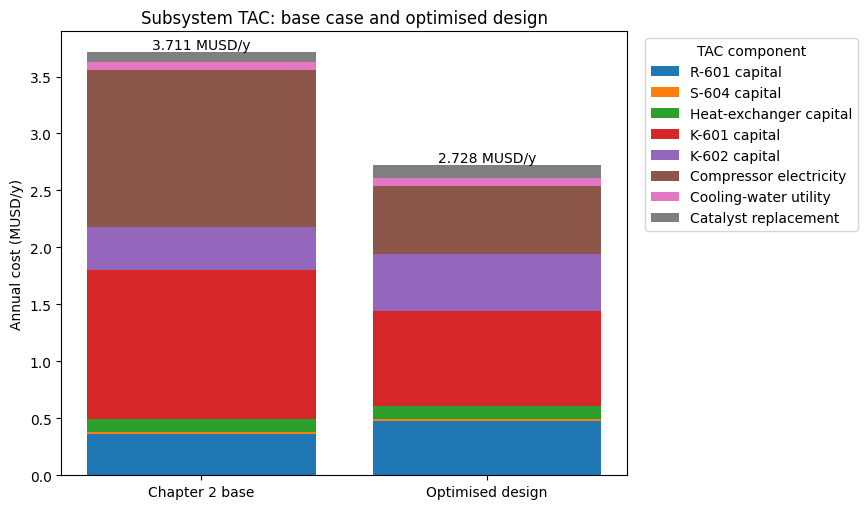

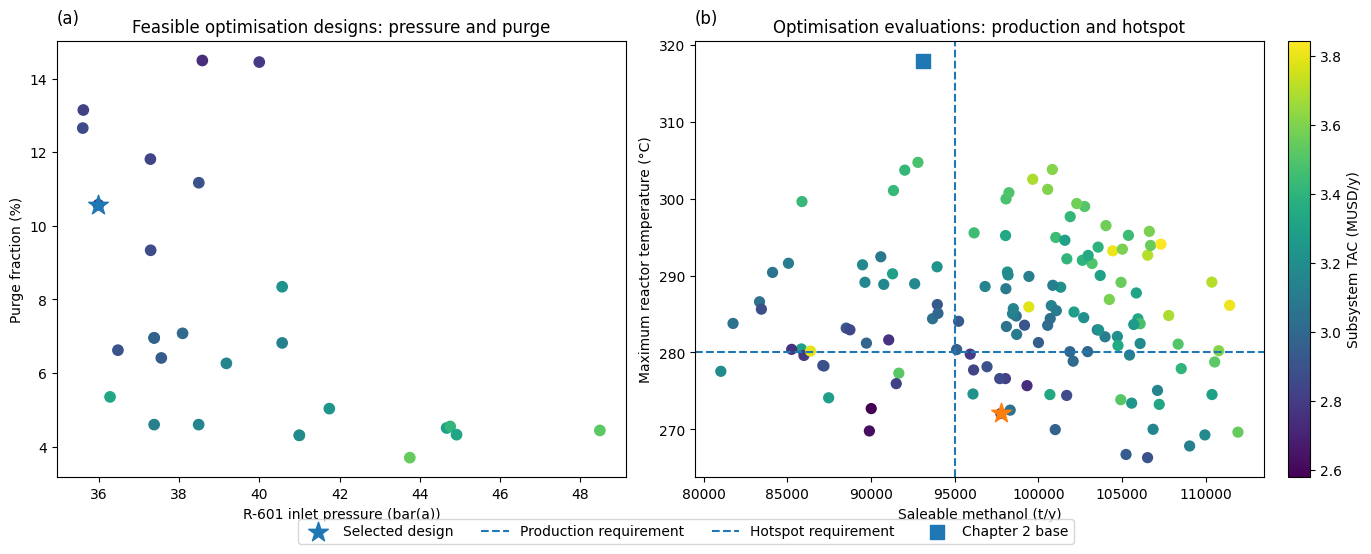

In [116]:
# Optimisation result visualisation
if "OPT_FINAL" not in globals() or "OPT_HISTORY_DF" not in globals():
    raise RuntimeError("Run the simultaneous optimisation and final design rerun first.")
if "CH3_BASE_TAC" not in globals():
    raise RuntimeError("Run the base-case TAC calculation first.")

# 1) Annual subsystem TAC breakdown.
component_keys = [
    ("R-601 capital", "annualised_R601_MUSD_y"),
    ("S-604 capital", "annualised_S604_MUSD_y"),
    ("Heat-exchanger capital", "annualised_HX_MUSD_y"),
    ("K-601 capital", "annualised_K601_MUSD_y"),
    ("K-602 capital", "annualised_K602_MUSD_y"),
    ("Compressor electricity", "compressor_electricity_MUSD_y"),
    ("Cooling-water utility", "cooling_utility_MUSD_y"),
    ("Catalyst replacement", "catalyst_replacement_MUSD_y"),
]

fig, ax = plt.subplots(figsize=(8.8, 5.2))
labels = ["Chapter 2 base", "Optimised design"]
bottom = np.zeros(2)
for component, key in component_keys:
    values = np.array([CH3_BASE_TAC[key], OPT_FINAL[key]], dtype=float)
    ax.bar(labels, values, bottom=bottom, label=component)
    bottom += values

for x_pos, total in enumerate(bottom):
    ax.text(x_pos, total, f"{total:.3f} MUSD/y", ha="center", va="bottom")

ax.set_ylabel("Annual cost (MUSD/y)")
ax.set_title("Subsystem TAC: base case and optimised design")
ax.legend(title="TAC component", bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

# Masks used for the optimisation maps.
history = OPT_HISTORY_DF.copy()
finite_tac = np.isfinite(pd.to_numeric(history.get("subsystem_TAC_MUSD_y"), errors="coerce"))
converged = history.get("recycle_converged", False) == True
h604_ok = history.get("H604_screening_pass", False) == True
production_ok = history.get("saleable_meoh_t_y", 0.0) >= CH3_LIMITS["minimum_saleable_meoh_t_y"]
hotspot_ok = history.get("Tmax_C", np.inf) <= CH3_LIMITS["maximum_hotspot_C"]

feasible = history.loc[finite_tac & converged & h604_ok & production_ok & hotspot_ok].copy()
converged_designs = history.loc[finite_tac & converged & h604_ok].copy()

# 2) Two projections of the actual optimisation evaluations with one TAC scale.
if len(feasible) and len(converged_designs):
    all_tac = pd.concat([
        feasible["subsystem_TAC_MUSD_y"],
        converged_designs["subsystem_TAC_MUSD_y"],
    ])
    norm = plt.Normalize(float(all_tac.min()), float(all_tac.max()))

    fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.2), constrained_layout=True)

    sc0 = axes[0].scatter(
        feasible["P_in_bar"],
        100.0*feasible["purge_fraction"],
        c=feasible["subsystem_TAC_MUSD_y"],
        norm=norm,
        s=55,
    )
    axes[0].scatter(
        OPT_FINAL["P_in_bar"],
        100.0*OPT_FINAL["purge_fraction"],
        marker="*",
        s=220,
        label="Selected design",
        zorder=5,
    )
    axes[0].set_xlabel("R-601 inlet pressure (bar(a))")
    axes[0].set_ylabel("Purge fraction (%)")
    axes[0].set_title("Feasible optimisation designs: pressure and purge")

    sc1 = axes[1].scatter(
        converged_designs["saleable_meoh_t_y"],
        converged_designs["Tmax_C"],
        c=converged_designs["subsystem_TAC_MUSD_y"],
        norm=norm,
        s=50,
    )
    axes[1].axvline(
        CH3_LIMITS["minimum_saleable_meoh_t_y"],
        linestyle="--",
        label="Production requirement",
    )
    axes[1].axhline(
        CH3_LIMITS["maximum_hotspot_C"],
        linestyle="--",
        label="Hotspot requirement",
    )
    axes[1].scatter(
        CH3_BASE_CHECK["saleable_meoh_t_y"],
        CH3_BASE_CHECK["Tmax_C"],
        marker="s",
        s=95,
        label="Chapter 2 base",
        zorder=5,
    )
    axes[1].scatter(
        OPT_FINAL["saleable_meoh_t_y"],
        OPT_FINAL["Tmax_C"],
        marker="*",
        s=220,
        label="Selected design",
        zorder=6,
    )
    axes[1].set_xlabel("Saleable methanol (t/y)")
    axes[1].set_ylabel("Maximum reactor temperature (°C)")
    axes[1].set_title("Optimisation evaluations: production and hotspot")

    axes[0].text(0.0, 1.04, "(a)", transform=axes[0].transAxes, fontsize=plt.rcParams["axes.titlesize"])
    axes[1].text(0.0, 1.04, "(b)", transform=axes[1].transAxes, fontsize=plt.rcParams["axes.titlesize"])

    handles0, labels0 = axes[0].get_legend_handles_labels()
    handles1, labels1 = axes[1].get_legend_handles_labels()
    combined = {}
    for h, lab in list(zip(handles0, labels0)) + list(zip(handles1, labels1)):
        combined.setdefault(lab, h)
    fig.legend(
        combined.values(), combined.keys(),
        loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4,
    )

    cbar = fig.colorbar(sc1, ax=axes, pad=0.02)
    cbar.set_label("Subsystem TAC (MUSD/y)")
    plt.show()
else:
    print("Insufficient converged feasible evaluations are available for the optimisation maps.")

## 3.9 Final design verification

Checks the selected design against the production, hotspot, H-604 and recycle-convergence requirements and confirms that the independently rerun design reproduces the optimisation process and subsystem-TAC results.

In [117]:
# Final design verification
if "OPT_FINAL" not in globals() or "OPT_BEST" not in globals():
    raise RuntimeError("Run Sections 3.8.2 and 3.8.3 before the final verification.")


def _relative_difference_percent(a, b):
    scale = max(abs(float(a)), 1.0e-12)
    return 100.0*abs(float(b) - float(a))/scale


meoh_repeatability_pct = _relative_difference_percent(
    OPT_BEST["saleable_meoh_t_y"], OPT_FINAL["saleable_meoh_t_y"]
)
tac_repeatability_pct = _relative_difference_percent(
    OPT_BEST["subsystem_TAC_MUSD_y"], OPT_FINAL["subsystem_TAC_MUSD_y"]
)
hotspot_repeatability_C = abs(float(OPT_FINAL["Tmax_C"]) - float(OPT_BEST["Tmax_C"]))

verification_rows = [
    {
        "Check": "Recycle convergence",
        "Result": "Converged" if OPT_FINAL.get("recycle_converged", False) else "Not converged",
        "Criterion": "Converged",
        "Pass": bool(OPT_FINAL.get("recycle_converged", False)),
    },
    {
        "Check": "Saleable methanol",
        "Result": f'{OPT_FINAL["saleable_meoh_t_y"]:,.0f} t/y',
        "Criterion": f'>= {CH3_LIMITS["minimum_saleable_meoh_t_y"]:,.0f} t/y',
        "Pass": bool(OPT_FINAL.get("production_pass", False)),
    },
    {
        "Check": "Maximum reactor temperature",
        "Result": f'{OPT_FINAL["Tmax_C"]:.2f} °C',
        "Criterion": f'<= {CH3_LIMITS["maximum_hotspot_C"]:.0f} °C',
        "Pass": bool(OPT_FINAL.get("hotspot_pass", False)),
    },
    {
        "Check": "H-604 thermal feasibility",
        "Result": f'{OPT_FINAL["H604_hot_end_approach_C"]:.2f} °C hot-end approach',
        "Criterion": "Screening requirement satisfied",
        "Pass": bool(OPT_FINAL.get("H604_screening_pass", False)),
    },
    {
        "Check": "Methanol rerun agreement",
        "Result": f"{meoh_repeatability_pct:.3f}% difference",
        "Criterion": "<= 1%",
        "Pass": bool(meoh_repeatability_pct <= 1.0),
    },
    {
        "Check": "Hotspot rerun agreement",
        "Result": f"{hotspot_repeatability_C:.3f} °C difference",
        "Criterion": "<= 1 °C",
        "Pass": bool(hotspot_repeatability_C <= 1.0),
    },
    {
        "Check": "TAC rerun agreement",
        "Result": f"{tac_repeatability_pct:.3f}% difference",
        "Criterion": "<= 1%",
        "Pass": bool(tac_repeatability_pct <= 1.0),
    },
]

FINAL_DESIGN_VERIFICATION = pd.DataFrame(verification_rows)
display(FINAL_DESIGN_VERIFICATION)

FINAL_DESIGN_VERIFIED = bool(FINAL_DESIGN_VERIFICATION["Pass"].all())
print("Final design verification passed:", FINAL_DESIGN_VERIFIED)


,Check,Result,Criterion,Pass
0,Recycle convergence,Converged,Converged,True
1,Saleable methanol,"97,753 t/y",">= 95,000 t/y",True
2,Maximum reactor temperature,272.04 °C,<= 280 °C,True
3,H-604 thermal feasibility,6.09 °C hot-end approach,Screening requirement satisfied,True
4,Methanol rerun agreement,0.000% difference,<= 1%,True
5,Hotspot rerun agreement,0.000 °C difference,<= 1 °C,True
6,TAC rerun agreement,0.000% difference,<= 1%,True


Final design verification passed: True


## 3.10 References and economic basis

- **Chemical Engineering (2026)**, CEPCI database: June 2026 final CEPCI = 870.2.
- **Eskom (2026)**, *Schedule of Standard Prices 2026/27*, large-industrial tariff basis used for compressor electricity.
- **Towler, G. and Sinnott, R.**, *Chemical Engineering Design*. January-2010 purchased-cost correlations are used for centrifugal compressors, shell-and-tube heat exchangers and pressure vessels, with CEPCI = 532.9 for the 2010 basis.
- **Teles, M. P. R. et al. (2024)**, *Energy Conversion and Management*, 300, 117870. Reactor purchased-cost correlation used for R-601, with the original 2012 EUR cost basis escalated to 2026.
- **Almaraz, O., Riley, J. and Palanki, S. (2025)**, *Industrial & Engineering Chemistry Research*, 64, 12074–12086. Cooling-water utility cost = 0.378 USD/GJ.
- **Campos, B. L. O. et al. (2022)**, *Processes*, 10, 1535. Cu/ZnO/Al₂O₃ catalyst cost = EUR 18,100/t.

H-604 uses recovered steam from the R-601/S-604 system in the model, so a separate purchased-steam charge is not added. H-603 is internal heat recovery and therefore has capital cost but no external heating or cooling utility cost.

### 3.10.1 Sensitivity and optimisation research basis

- Roode-Gutzmer, Q. et al. (2019), *Renewable Methanol Synthesis*, **ChemBioEng Reviews**. DOI: 10.1002/cben.201900012.
- Bozzano, G. & Manenti, F. (2016), *Efficient methanol synthesis: Perspectives, technologies and optimization strategies*, **Progress in Energy and Combustion Science**, 56, 71–105. DOI: 10.1016/j.pecs.2016.06.001.
- Dieterich, V. et al. (2020), *Power-to-liquid via synthesis of methanol, DME or Fischer–Tropsch-fuels: a review*, **Energy & Environmental Science**, 13, 3207–3252. DOI: 10.1039/D0EE01187H.
- GhasemiKafrudi, E. et al. (2022), *Optimization of methanol production process from carbon dioxide hydrogenation in order to reduce recycle flow and energy consumption*, **Journal of Cleaner Production**, 376, 134184. DOI: 10.1016/j.jclepro.2022.134184.
- Greeff, I. L. et al. (2002), *Utilisation of reactor heat in methanol synthesis to reduce compressor duty*, **Applied Thermal Engineering**, 22, 1549–1558. DOI: 10.1016/S1359-4311(02)00088-1.
